In [1]:
import boto3
import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

# Scikit-learn: preprocesamiento y selección
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, TimeSeriesSplit,
    RandomizedSearchCV, cross_val_score, cross_validate
)

# Scikit-learn: métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

# Scikit-learn: calibración 
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Permutation importance 
from sklearn.inspection import permutation_importance

# Boosting
import xgboost as xgb
from xgboost import XGBClassifier

# Balanceo de clases
from imblearn.over_sampling import SMOTE, RandomOverSampler

# Interpretabilidad
import shap

# Persistencia
import joblib
from pathlib import Path

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

# Estilo visual
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Imports completos cargados")
print(f"   pandas:       {pd.__version__}")
print(f"   numpy:        {np.__version__}")
print(f"   xgboost:      {xgb.__version__}")
print(f"   shap:         {shap.__version__}")

Imports completos cargados
   pandas:       3.0.3
   numpy:        2.4.5
   xgboost:      3.2.0
   shap:         0.51.0


In [ ]:
import boto3
import pandas as pd
import io

s3 = boto3.client(
    's3',
    aws_access_key_id='',
    aws_secret_access_key='',
    aws_session_token='',
    region_name=''
)

response = s3.list_buckets()
for bucket in response['Buckets']:
    print(bucket['Name'])

aws-glue-assets-590184090170-us-east-1
de-workshop3-cortes
de-workshop3-velasquez
proyect-ny311
taller2-spark-sara-cortes


In [3]:
# Carga de splits temporales y artifacts

BUCKET = 'proyect-ny311'
BASE_PATH_GOLD = 'gold_v2/ny311/'         
ARTIFACTS_KEY  = 'gold_v2/artifacts/inference_artifacts.json'

def leer_parquet_s3(carpeta):
    """Lee todos los parquets de una carpeta en S3 y los concatena."""
    prefix = BASE_PATH_GOLD + carpeta + '/'
    response = s3.list_objects_v2(Bucket=BUCKET, Prefix=prefix)
    
    dfs = []
    for obj in response.get('Contents', []):
        key = obj['Key']
        if key.endswith('.parquet'):
            print(f'  leyendo: {key}')
            file = s3.get_object(Bucket=BUCKET, Key=key)
            dfs.append(pd.read_parquet(io.BytesIO(file['Body'].read())))
    
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# Cargar los tres splits
print("Cargando splits desde gold_v2/...\n")
print("TRAIN:")
df_train = leer_parquet_s3('train')
print("\nVAL:")
df_val   = leer_parquet_s3('val')
print("\nTEST:")
df_test  = leer_parquet_s3('test')

# Cargar los artifacts (mapeos para inferencia)
print("\nCargando artifacts...")
artifacts_response = s3.get_object(Bucket=BUCKET, Key=ARTIFACTS_KEY)
ARTIFACTS = json.loads(artifacts_response['Body'].read().decode('utf-8'))
print(f"   Artifacts cargados ({len(ARTIFACTS)} secciones)")
print(f"   Secciones disponibles: {list(ARTIFACTS.keys())}")

# Verificación inicial
print("\n" + "=" * 60)
print("DIMENSIONES DE LOS SPLITS")
print("=" * 60)
total = len(df_train) + len(df_val) + len(df_test)
for nombre, df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    pct = 100 * len(df) / total
    print(f"  {nombre:6}: {len(df):>10,} filas | {df.shape[1]} columnas | {pct:.1f}%")
print(f"  {'TOTAL':6}: {total:>10,} filas")

print(f"\nDatos cargados correctamente.")
print(f"   • Split: TEMPORAL por percentiles (70/15/15)")
print(f"   • Features: {len(ARTIFACTS['feature_order'])}")

Cargando splits desde gold_v2/...

TRAIN:
  leyendo: gold_v2/ny311/train/part-00000-45dfb159-0a68-4ff1-9d24-40d935bf8a08-c000.snappy.parquet
  leyendo: gold_v2/ny311/train/part-00001-45dfb159-0a68-4ff1-9d24-40d935bf8a08-c000.snappy.parquet
  leyendo: gold_v2/ny311/train/part-00002-45dfb159-0a68-4ff1-9d24-40d935bf8a08-c000.snappy.parquet
  leyendo: gold_v2/ny311/train/part-00003-45dfb159-0a68-4ff1-9d24-40d935bf8a08-c000.snappy.parquet
  leyendo: gold_v2/ny311/train/part-00004-45dfb159-0a68-4ff1-9d24-40d935bf8a08-c000.snappy.parquet
  leyendo: gold_v2/ny311/train/part-00005-45dfb159-0a68-4ff1-9d24-40d935bf8a08-c000.snappy.parquet
  leyendo: gold_v2/ny311/train/part-00006-45dfb159-0a68-4ff1-9d24-40d935bf8a08-c000.snappy.parquet
  leyendo: gold_v2/ny311/train/part-00007-45dfb159-0a68-4ff1-9d24-40d935bf8a08-c000.snappy.parquet
  leyendo: gold_v2/ny311/train/part-00008-45dfb159-0a68-4ff1-9d24-40d935bf8a08-c000.snappy.parquet
  leyendo: gold_v2/ny311/train/part-00009-45dfb159-0a68-4ff1-9d24-4

TASA DE INCUMPLIMIENTO POR SPLIT - LA EVIDENCIA DEL DRIFT

               Split  Cumplen (0)  Incumplen (1) Tasa incumplimiento
Train (más antiguo)        94879          26424              21.78%
   Val (intermedio)        22263           3736              14.37%
Test (más reciente)        22651           3361              12.92%


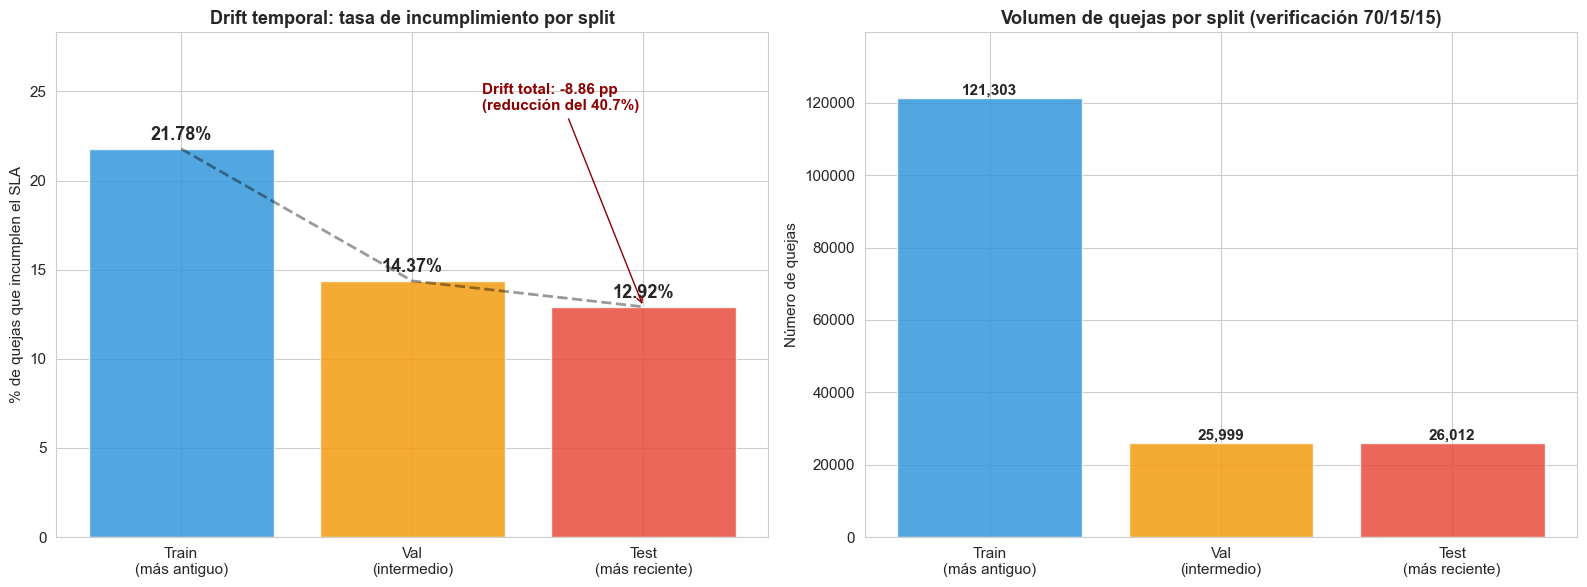


¿EL DRIFT ES UNIFORME ENTRE AGENCIAS O CONCENTRADO EN ALGUNAS?

Drift por agencia (ordenado de mayor caída a mayor aumento):

Agencia  n_train  n_test  tasa_train (%)  tasa_test (%)  drift (pp)
    DHS     1748     528           99.71          51.14      -48.58
    DPR     1795     152           37.27           0.00      -37.27
    DOT     9256    1631           28.52           0.06      -28.46
    DEP     8970    1623           66.04          42.45      -23.59
  DOHMH     1732     141           19.92           0.00      -19.92
    TLC     1050     224           17.33           0.00      -17.33
   DSNY     6328    1195           13.40           2.43      -10.97
    HPD    28659    3696            9.87           0.00       -9.87
   NYPD    55429   15028           19.87          15.78       -4.09
    DOB     5859    1695            3.86           0.00       -3.86
    DCA      409      94            0.24           0.00       -0.24


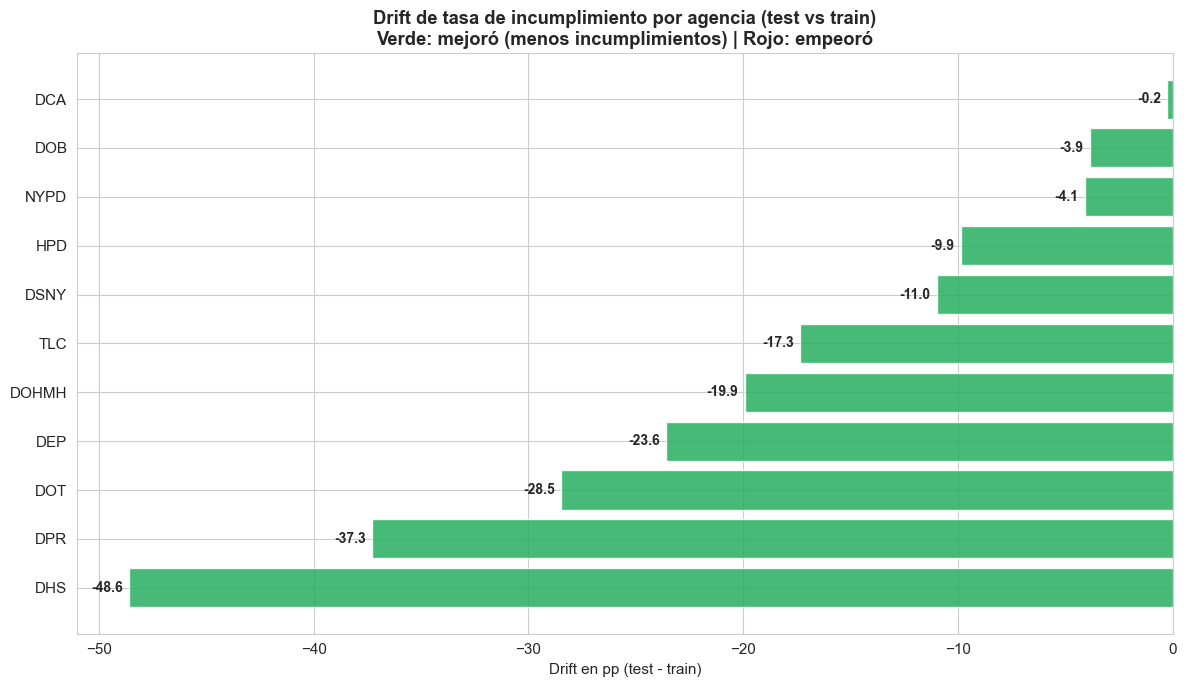


CONCLUSIONES

  • Drift de tasa de incumplimiento: +8.86 pp entre train y test
  • Train (Sep-Oct):  21.78% de incumplimientos
  • Test  (~Dic):     12.92% de incumplimientos
  • Reducción del 40.7% en la prevalencia del evento positivo



In [4]:
# 1. Distribución del target por split 
print("=" * 70)
print("TASA DE INCUMPLIMIENTO POR SPLIT - LA EVIDENCIA DEL DRIFT")
print("=" * 70)

tasas = []
for nombre, df in [("Train (más antiguo)", df_train),
                   ("Val (intermedio)",   df_val),
                   ("Test (más reciente)", df_test)]:
    tasa = df['target'].mean()
    n_pos = (df['target']==1).sum()
    n_neg = (df['target']==0).sum()
    tasas.append({
        'Split': nombre,
        'Cumplen (0)': n_neg,
        'Incumplen (1)': n_pos,
        'Tasa incumplimiento': f"{tasa*100:.2f}%",
        'Tasa numérica': tasa,
    })
df_tasas = pd.DataFrame(tasas)
print("\n", df_tasas.drop(columns=['Tasa numérica']).to_string(index=False))

# 2. Comparación visual del drift
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Tasa de incumplimiento por split
colores = ['#3498db', '#f39c12', '#e74c3c']
splits = ['Train\n(más antiguo)', 'Val\n(intermedio)', 'Test\n(más reciente)']
valores = [d['target'].mean()*100 for d in [df_train, df_val, df_test]]

bars = axes[0].bar(splits, valores, color=colores, alpha=0.85)
for bar, val in zip(bars, valores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                  f'{val:.2f}%', ha='center', fontweight='bold', fontsize=13)

# Línea conectando los puntos para enfatizar la tendencia
axes[0].plot(range(3), valores, 'k--', alpha=0.4, linewidth=2)
axes[0].set_title('Drift temporal: tasa de incumplimiento por split',
                   fontweight='bold', fontsize=13)
axes[0].set_ylabel('% de quejas que incumplen el SLA')
axes[0].set_ylim(0, max(valores) * 1.3)

# Anotación de drift
drift = valores[0] - valores[2]
axes[0].annotate(f'Drift total: -{drift:.2f} pp\n(reducción del {drift/valores[0]*100:.1f}%)',
                  xy=(2, valores[2]), xytext=(1.3, max(valores)*1.1),
                  fontsize=11, color='darkred', fontweight='bold',
                  arrowprops=dict(arrowstyle='->', color='darkred'))

# Gráfico 2: Volumen de quejas por split
volumenes = [len(df) for df in [df_train, df_val, df_test]]
bars2 = axes[1].bar(splits, volumenes, color=colores, alpha=0.85)
for bar, val in zip(bars2, volumenes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                  f'{val:,}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Volumen de quejas por split (verificación 70/15/15)',
                   fontweight='bold')
axes[1].set_ylabel('Número de quejas')
axes[1].set_ylim(0, max(volumenes) * 1.15)

plt.tight_layout()
plt.show()

# 3. Análisis del drift por agencia 
print("\n" + "=" * 70)
print("¿EL DRIFT ES UNIFORME ENTRE AGENCIAS O CONCENTRADO EN ALGUNAS?")
print("=" * 70)

drift_por_agencia = []
for agencia in df_train['Agency'].unique():
    tasa_train = df_train.loc[df_train['Agency']==agencia, 'target'].mean()
    tasa_test  = df_test.loc[df_test['Agency']==agencia, 'target'].mean() if (df_test['Agency']==agencia).sum() > 0 else np.nan
    n_train = (df_train['Agency']==agencia).sum()
    n_test  = (df_test['Agency']==agencia).sum()
    
    if not np.isnan(tasa_test) and n_train >= 100 and n_test >= 50:
        drift_por_agencia.append({
            'Agencia': agencia,
            'n_train': n_train,
            'n_test': n_test,
            'tasa_train (%)': tasa_train * 100,
            'tasa_test (%)': tasa_test * 100,
            'drift (pp)': (tasa_test - tasa_train) * 100,
        })

df_drift = pd.DataFrame(drift_por_agencia).sort_values('drift (pp)')
print("\nDrift por agencia (ordenado de mayor caída a mayor aumento):\n")
print(df_drift.round(2).to_string(index=False))

# Visualizar
fig, ax = plt.subplots(figsize=(12, 7))
colores_drift = ['#e74c3c' if d > 0 else '#27ae60' for d in df_drift['drift (pp)']]
ax.barh(df_drift['Agencia'], df_drift['drift (pp)'], color=colores_drift, alpha=0.85)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Drift en pp (test - train)')
ax.set_title('Drift de tasa de incumplimiento por agencia (test vs train)\n'
              'Verde: mejoró (menos incumplimientos) | Rojo: empeoró',
              fontweight='bold')
for i, (idx, row) in enumerate(df_drift.iterrows()):
    ax.text(row['drift (pp)'] + (0.3 if row['drift (pp)']>0 else -0.3),
             i, f"{row['drift (pp)']:+.1f}",
             va='center', ha='left' if row['drift (pp)']>0 else 'right',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Conclusión y plan de acción
print("\n" + "=" * 70)
print("CONCLUSIONES")
print("=" * 70)

drift_total = (df_train['target'].mean() - df_test['target'].mean()) * 100

print(f"""
  • Drift de tasa de incumplimiento: {drift_total:+.2f} pp entre train y test
  • Train (Sep-Oct):  21.78% de incumplimientos
  • Test  (~Dic):     12.92% de incumplimientos
  • Reducción del {(drift_total/21.78)*100:.1f}% en la prevalencia del evento positivo
""")

In [5]:
print("=" * 70)
print("FILTRADO ANTI-CENSURA POR AGENCIA")
print("=" * 70)

# 1. Reconstruir orden temporal y "fecha relativa" 
# Concatenar en orden temporal: train (más antiguo) → val → test (más reciente)
df_train_idx = df_train.copy()
df_val_idx   = df_val.copy()
df_test_idx  = df_test.copy()

df_train_idx['_split'] = 'train'
df_val_idx['_split']   = 'val'
df_test_idx['_split']  = 'test'

# Concatenar con índice global temporal
df_all = pd.concat([df_train_idx, df_val_idx, df_test_idx], ignore_index=True)
df_all['_indice_temporal'] = range(len(df_all))

# Calculamos el "índice máximo" del dataset (proxy de la fecha de export)
indice_max = df_all['_indice_temporal'].max()
N_TOTAL = len(df_all)
print(f"\nTotal de quejas en el dataset: {N_TOTAL:,}")
print(f"   Índice máximo (proxy de fecha de export): {indice_max:,}")

# 2. Convertir SLA en días a "índice equivalente"

DIAS_DATASET = 120  # aproximadamente 4 meses
quejas_por_dia_promedio = N_TOTAL / DIAS_DATASET
print(f"   Días estimados del dataset: {DIAS_DATASET}")
print(f"   Quejas por día promedio: {quejas_por_dia_promedio:.0f}")

# 3. Definir la ventana de censura por agencia
# Usamos el diccionario business_mapping de los artifacts
business_mapping = ARTIFACTS['business_mapping']

ventanas_censura = {}
for agency, (sla_days, _) in business_mapping.items():
    # Índice "límite": después de este índice, las quejas están potencialmente censuradas
    indices_descartados = int(sla_days * quejas_por_dia_promedio)
    indice_limite = indice_max - indices_descartados
    ventanas_censura[agency] = {
        'sla_days': sla_days,
        'indice_limite': indice_limite,
        'indices_descartados': indices_descartados,
    }

# Mostrar tabla
df_ventanas = pd.DataFrame([
    {'Agencia': a, 'SLA (días)': v['sla_days'],
     'Índices descartados (estimados)': v['indices_descartados'],
     '% del dataset descartado': f"{100*v['indices_descartados']/N_TOTAL:.1f}%"}
    for a, v in ventanas_censura.items()
]).sort_values('SLA (días)', ascending=False)
print(df_ventanas.to_string(index=False))

# 4. Aplicar el filtro
print("\n" + "=" * 70)
print("APLICANDO FILTRO ANTI-CENSURA")
print("=" * 70)

# Para cada agencia con SLA conocido, marcar las quejas censuradas
df_all['_descartar'] = False

for agency, ventana in ventanas_censura.items():
    mask_agencia   = df_all['Agency'] == agency
    mask_censurada = df_all['_indice_temporal'] > ventana['indice_limite']
    mask_total     = mask_agencia & mask_censurada
    df_all.loc[mask_total, '_descartar'] = True

# Quejas con agencia fuera del diccionario: mantenerlas (no podemos saber su SLA)
agencias_en_dataset = set(df_all['Agency'].unique())
agencias_sin_mapping = agencias_en_dataset - set(business_mapping.keys())
if agencias_sin_mapping:
    print(f"\nAgencias sin mapping de SLA (se mantienen sin filtrar): {agencias_sin_mapping}")

# Reportar cuántas se descartan
n_descartadas = df_all['_descartar'].sum()
print(f"\nQuejas descartadas por censura: {n_descartadas:,} ({100*n_descartadas/N_TOTAL:.1f}%)")
print(f"   Quejas conservadas:              {(~df_all['_descartar']).sum():,} ({100*(~df_all['_descartar']).sum()/N_TOTAL:.1f}%)")

# Por split, cuántas se descartan
print("\n   Desglose de descartes por split:")
for split in ['train', 'val', 'test']:
    n_split = (df_all['_split']==split).sum()
    n_desc_split = ((df_all['_split']==split) & df_all['_descartar']).sum()
    print(f"     {split:5}: {n_desc_split:>7,} descartadas de {n_split:>7,} "
          f"({100*n_desc_split/n_split:.1f}%)")

# 5. Reconstruir los splits filtrados 
print("\n" + "=" * 70)
print("RECONSTRUYENDO SPLITS FILTRADOS")
print("=" * 70)

df_all_filtrado = df_all[~df_all['_descartar']].copy()

# Eliminar columnas auxiliares antes de regenerar los splits
cols_aux = ['_split', '_indice_temporal', '_descartar']

df_train_f = df_all_filtrado[df_all_filtrado['_split']=='train'].drop(columns=cols_aux).reset_index(drop=True)
df_val_f   = df_all_filtrado[df_all_filtrado['_split']=='val'].drop(columns=cols_aux).reset_index(drop=True)
df_test_f  = df_all_filtrado[df_all_filtrado['_split']=='test'].drop(columns=cols_aux).reset_index(drop=True)

# REEMPLAZAR los dataframes originales
df_train = df_train_f
df_val   = df_val_f
df_test  = df_test_f

print(f"\nSplits filtrados:")
total = len(df_train) + len(df_val) + len(df_test)
for nombre, df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    pct = 100 * len(df) / total
    print(f"   {nombre:6}: {len(df):>10,} filas ({pct:.1f}%)")
print(f"   TOTAL : {total:>10,} filas")

# 6. Verificar tasas de incumplimiento POST-FILTRO 
print("\n" + "=" * 70)
print("TASAS DE INCUMPLIMIENTO DESPUÉS DEL FILTRO ANTI-CENSURA")
print("=" * 70)

for nombre, df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    tasa = df['target'].mean() * 100
    print(f"   {nombre:6}: {tasa:.2f}% de incumplimiento ({(df['target']==1).sum():,} de {len(df):,})")

# --- 7. Comparar drift por agencia POST-FILTRO ---
print("\n" + "=" * 70)
print("DRIFT POR AGENCIA POST-FILTRO (debe estar mucho mejor)")
print("=" * 70)

drift_post = []
for agency in df_train['Agency'].unique():
    n_tr = (df_train['Agency']==agency).sum()
    n_te = (df_test['Agency']==agency).sum()
    if n_tr >= 100 and n_te >= 50:
        t_tr = df_train.loc[df_train['Agency']==agency, 'target'].mean()
        t_te = df_test.loc[df_test['Agency']==agency, 'target'].mean()
        drift_post.append({
            'Agencia': agency,
            'n_train': n_tr,
            'n_test': n_te,
            'tasa_train (%)': t_tr * 100,
            'tasa_test (%)': t_te * 100,
            'drift (pp)': (t_te - t_tr) * 100,
        })

df_drift_post = pd.DataFrame(drift_post).sort_values('drift (pp)')
print("\n", df_drift_post.round(2).to_string(index=False))

# 8. Diagnóstico final
print("\n" + "=" * 70)
print("DIAGNÓSTICO POST-FILTRO")
print("=" * 70)

agencias_con_cero_test = (df_drift_post['tasa_test (%)'] == 0).sum()
drift_max = df_drift_post['drift (pp)'].abs().max()

print(f"""
   Agencias con tasa_test = 0% (señal de censura residual): {agencias_con_cero_test}
   Drift máximo entre train y test: {drift_max:.2f} pp
""")

FILTRADO ANTI-CENSURA POR AGENCIA

Total de quejas en el dataset: 173,314
   Índice máximo (proxy de fecha de export): 173,313
   Días estimados del dataset: 120
   Quejas por día promedio: 1444
Agencia  SLA (días)  Índices descartados (estimados) % del dataset descartado
    DOB       40.00                            57771                    33.3%
    DOE       36.00                            51994                    30.0%
    DCA       28.00                            40439                    23.3%
    TLC       14.00                            20219                    11.7%
  DOHMH       14.00                            20219                    11.7%
    HPD       12.00                            17331                    10.0%
    DPR        8.00                            11554                     6.7%
    DOT        5.00                             7221                     4.2%
   DSNY        5.00                             7221                     4.2%
  DOITT        3.00      

EDA DEL DESBALANCEO (datos filtrados)


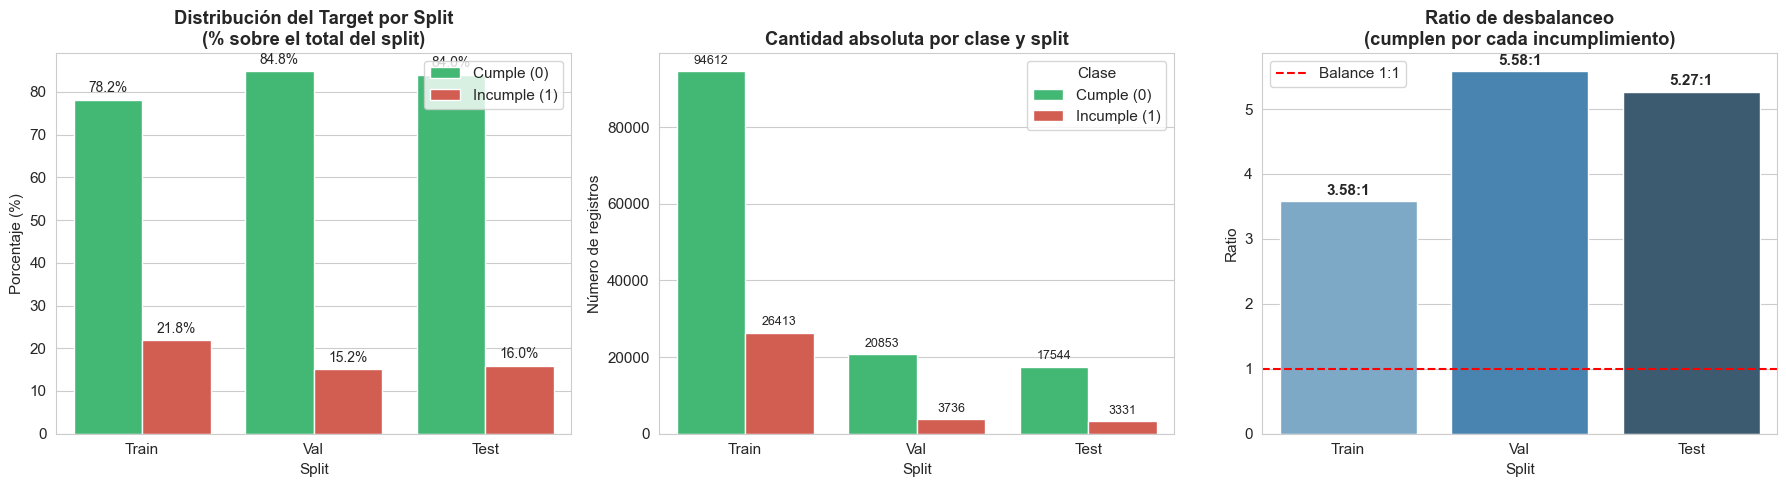


RATIOS DE DESBALANCEO:
   Train: 3.58:1  (~21.8% positivos)
   Test:  5.27:1  (~16.0% positivos)
TOP 10 COMBINACIONES Agency × Borough MÁS RIESGOSAS (Train)

                       tasa_incump     n
Agency Borough                         
DHS    QUEENS              100.00   133
       MANHATTAN            99.92  1188
       BROOKLYN             98.77   325
DEP    MANHATTAN            76.18  2788
       BROOKLYN             68.40  2497
       BRONX                65.52   786
       STATEN ISLAND        55.39   529
       QUEENS               54.20  2369
DPR    BROOKLYN             53.44   509
       BRONX                38.84   121


In [6]:
#  EDA del desbalanceo POST-FILTRO

print("=" * 70)
print("EDA DEL DESBALANCEO (datos filtrados)")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: Distribución del target por split
splits_data = []
for nombre, df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    for clase in [0, 1]:
        splits_data.append({
            'Split': nombre,
            'Clase': 'Cumple (0)' if clase == 0 else 'Incumple (1)',
            'Cantidad': (df['target'] == clase).sum(),
            'Porcentaje': (df['target'] == clase).mean() * 100
        })
df_dist = pd.DataFrame(splits_data)

ax1 = axes[0]
sns.barplot(data=df_dist, x='Split', y='Porcentaje', hue='Clase',
            palette={'Cumple (0)': '#2ecc71', 'Incumple (1)': '#e74c3c'}, ax=ax1)
ax1.set_title('Distribución del Target por Split\n(% sobre el total del split)',
              fontweight='bold')
ax1.set_ylabel('Porcentaje (%)')
ax1.legend(loc='upper right')
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

# Subplot 2: Cantidad absoluta
ax2 = axes[1]
sns.barplot(data=df_dist, x='Split', y='Cantidad', hue='Clase',
            palette={'Cumple (0)': '#2ecc71', 'Incumple (1)': '#e74c3c'}, ax=ax2)
ax2.set_title('Cantidad absoluta por clase y split', fontweight='bold')
ax2.set_ylabel('Número de registros')
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.0f', padding=3, fontsize=9)

# Subplot 3: Ratio de desbalanceo
ax3 = axes[2]
ratios = []
for nombre, df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    n_pos = (df['target'] == 1).sum()
    n_neg = (df['target'] == 0).sum()
    ratios.append({'Split': nombre, 'Ratio': n_neg / n_pos if n_pos > 0 else 0})
df_ratios = pd.DataFrame(ratios)
sns.barplot(data=df_ratios, x='Split', y='Ratio',
            palette='Blues_d', ax=ax3)
ax3.set_title('Ratio de desbalanceo\n(cumplen por cada incumplimiento)', fontweight='bold')
ax3.axhline(y=1, color='red', linestyle='--', label='Balance 1:1')
ax3.legend()
for i, v in enumerate(df_ratios['Ratio']):
    ax3.text(i, v + 0.1, f'{v:.2f}:1', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Diagnóstico
ratio_train = (df_train['target']==0).sum() / (df_train['target']==1).sum()
ratio_test  = (df_test['target']==0).sum() / (df_test['target']==1).sum()

print(f"\nRATIOS DE DESBALANCEO:")
print(f"   Train: {ratio_train:.2f}:1  (~{1/(1+ratio_train)*100:.1f}% positivos)")
print(f"   Test:  {ratio_test:.2f}:1  (~{1/(1+ratio_test)*100:.1f}% positivos)")


# Top 10 combinaciones de riesgo (igual que P1)
print("=" * 70)
print("TOP 10 COMBINACIONES Agency × Borough MÁS RIESGOSAS (Train)")
print("=" * 70)
combo = (df_train.groupby(['Agency', 'Borough'])['target']
                 .agg(['mean', 'count'])
                 .rename(columns={'mean': 'tasa_incump', 'count': 'n'}))
combo = combo[combo['n'] >= 100]
combo['tasa_incump'] = (combo['tasa_incump'] * 100).round(2)
print("\n", combo.sort_values('tasa_incump', ascending=False).head(10).to_string())

In [7]:
# Selección de features

# 1. Recuperar la lista de features desde los artifacts
FEATURES = ARTIFACTS['feature_order']
TARGET = 'target'

print("=" * 70)
print("FEATURES")
print("=" * 70)
print(f"\nTotal de features: {len(FEATURES)}\n")

# Organizar por familia para mostrarlas
familias = {
    'Numéricas base':        ['latitude', 'longitude'],
    'Negocio (SLA/multa)':   ['sla_days', 'penalty_amount_usd'],
    'Temporales':            ['hora_sen', 'hora_cos', 'dia_semana_sen', 'dia_semana_cos',
                              'es_fin_de_semana', 'trimestre', 'quejas_por_dia'],
    'Históricas':            ['std_dias_complaint_type', 'p75_dias_complaint_type',
                              'avg_dias_agency', 'avg_dias_borough', 'avg_dias_zip'],
    'Presión SLA': ['presion_sla', 'presion_sla_p75',
                              'saturacion_zip', 'saturacion_diaria'],
    'Geoespaciales':         ['dist_km_agencia', 'densidad_zip_30d'],
    'Indexed (_idx)':        ['Agency_idx', 'Borough_idx',
                              'Open Data Channel Type_idx',
                              'Location Type_idx', 'turno_idx'],
    'Target Encoded (_te)':  ['Complaint Type_te', 'Incident Zip_te', 'borough_canal_te'],
}

for familia, features_familia in familias.items():
    presentes = [f for f in features_familia if f in FEATURES]
    print(f"  {familia} ({len(presentes)}):")
    for f in presentes:
        print(f"    • {f}")
    print()

# Verificar que todas las features están en los splits
missing = [f for f in FEATURES if f not in df_train.columns]
if missing:
    print(f"Features en artifacts pero NO en los splits: {missing}")
else:
    print("Todas las features están disponibles en los 3 splits.")

# 2. Construir X e y 
print("\n" + "=" * 70)
print("CONSTRUCCIÓN DE X e y")
print("=" * 70)

X_train = df_train[FEATURES].copy()
y_train = df_train[TARGET].copy()

X_val = df_val[FEATURES].copy()
y_val = df_val[TARGET].copy()

X_test = df_test[FEATURES].copy()
y_test = df_test[TARGET].copy()

# Verificaciones
print(f"\nDimensiones:")
print(f"   X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"   X_val:   {X_val.shape}   |  y_val:   {y_val.shape}")
print(f"   X_test:  {X_test.shape}   |  y_test:  {y_test.shape}")

# Nulos
print(f"\nVerificación de nulos en X:")
for nombre, X in [("Train", X_train), ("Val", X_val), ("Test", X_test)]:
    n_nulls = X.isnull().sum().sum()
    cols_nulls = X.isnull().sum()[X.isnull().sum() > 0]
    print(f"   {nombre}: {n_nulls} nulos totales")
    if len(cols_nulls) > 0:
        print(f"     Columnas con nulos: {dict(cols_nulls)}")

print(f"\nX e y listos para modelar.")
print(f"   Features:     {len(FEATURES)}")
print(f"   Total filas:  {len(X_train) + len(X_val) + len(X_test):,}")

FEATURES

Total de features: 30

  Numéricas base (2):
    • latitude
    • longitude

  Negocio (SLA/multa) (2):
    • sla_days
    • penalty_amount_usd

  Temporales (7):
    • hora_sen
    • hora_cos
    • dia_semana_sen
    • dia_semana_cos
    • es_fin_de_semana
    • trimestre
    • quejas_por_dia

  Históricas (5):
    • std_dias_complaint_type
    • p75_dias_complaint_type
    • avg_dias_agency
    • avg_dias_borough
    • avg_dias_zip

  Presión SLA (4):
    • presion_sla
    • presion_sla_p75
    • saturacion_zip
    • saturacion_diaria

  Geoespaciales (2):
    • dist_km_agencia
    • densidad_zip_30d

  Indexed (_idx) (5):
    • Agency_idx
    • Borough_idx
    • Open Data Channel Type_idx
    • Location Type_idx
    • turno_idx

  Target Encoded (_te) (3):
    • Complaint Type_te
    • Incident Zip_te
    • borough_canal_te

Todas las features están disponibles en los 3 splits.

CONSTRUCCIÓN DE X e y

Dimensiones:
   X_train: (121025, 30)  |  y_train: (121025,)
   X_val:  

In [8]:
# Baselines ingenuos y métrica priorizada

print("=" * 70)
print("ENTRENAMIENTO DE BASELINES INGENUOS")
print("=" * 70)

baselines = {
    'Stratified (aleatorio respetando proporciones)':
        DummyClassifier(strategy='stratified', random_state=SEED),
    'Most Frequent (siempre predice CUMPLE)':
        DummyClassifier(strategy='most_frequent'),
    'Constant=1 (siempre predice INCUMPLE)':
        DummyClassifier(strategy='constant', constant=1),
}

def evaluar_modelo(modelo, X, y):
    """Calcula todas las métricas relevantes."""
    y_pred = modelo.predict(X)
    try:
        y_proba = modelo.predict_proba(X)[:, 1]
        roc_auc = roc_auc_score(y, y_proba) if len(np.unique(y_proba)) > 1 else np.nan
        pr_auc  = average_precision_score(y, y_proba) if len(np.unique(y_proba)) > 1 else np.nan
    except Exception:
        roc_auc, pr_auc = np.nan, np.nan
    return {
        'Accuracy':  accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred, zero_division=0),
        'Recall':    recall_score(y, y_pred, zero_division=0),
        'F1':        f1_score(y, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc,
        'PR-AUC':    pr_auc,
    }

# Entrenar y evaluar
resultados_baseline = {}
for nombre, modelo in baselines.items():
    modelo.fit(X_train, y_train)
    metricas = evaluar_modelo(modelo, X_val, y_val)
    resultados_baseline[nombre] = metricas

df_baseline = pd.DataFrame(resultados_baseline).T.round(4)
print("\nMÉTRICAS DE BASELINES EN VALIDACIÓN:\n")
print(df_baseline.to_string())

# Prevalencia
prevalencia_train = y_train.mean()
prevalencia_val   = y_val.mean()
prevalencia_test  = y_test.mean()

print(f"\nPrevalencias por split (recordatorio del drift):")
print(f"   Train: {prevalencia_train:.4f} ({prevalencia_train*100:.2f}%)")
print(f"   Val:   {prevalencia_val:.4f} ({prevalencia_val*100:.2f}%)")
print(f"   Test:  {prevalencia_test:.4f} ({prevalencia_test*100:.2f}%)")

print(f"\nMínimos teóricos a superar (medidos en val):")
print(f"   PR-AUC mínimo (aleatorio):  {prevalencia_val:.4f}")
print(f"   ROC-AUC mínimo (aleatorio): 0.5000")
print(f"   F1 del Constant=1:        {2*prevalencia_val/(1+prevalencia_val):.4f}")

ENTRENAMIENTO DE BASELINES INGENUOS

MÉTRICAS DE BASELINES EN VALIDACIÓN:

                                                Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
Stratified (aleatorio respetando proporciones)    0.6983     0.1579  0.2275  0.1864   0.5051  0.1533
Most Frequent (siempre predice CUMPLE)            0.8481     0.0000  0.0000  0.0000      NaN     NaN
Constant=1 (siempre predice INCUMPLE)             0.1519     0.1519  1.0000  0.2638      NaN     NaN

Prevalencias por split (recordatorio del drift):
   Train: 0.2182 (21.82%)
   Val:   0.1519 (15.19%)
   Test:  0.1596 (15.96%)

Mínimos teóricos a superar (medidos en val):
   PR-AUC mínimo (aleatorio):  0.1519
   ROC-AUC mínimo (aleatorio): 0.5000
   F1 del Constant=1:        0.2638


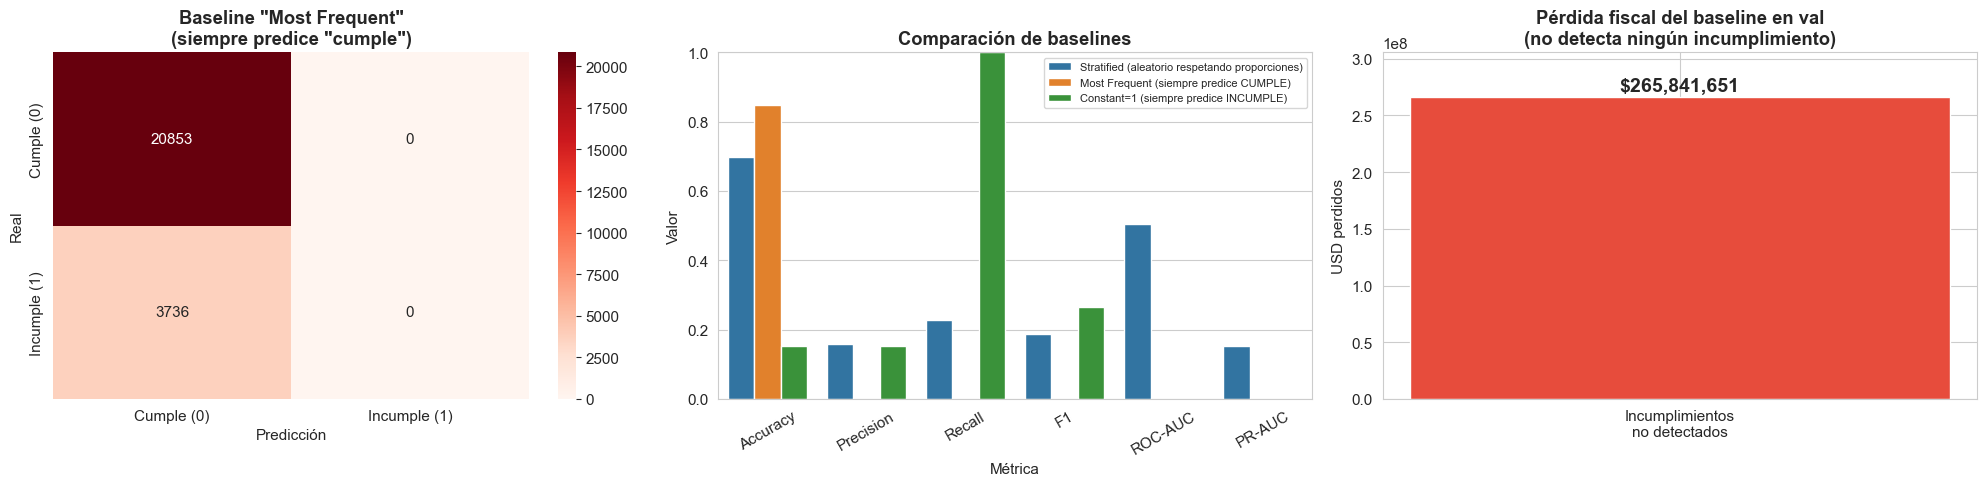


CONCLUSIONES DEL BASELINE

    Baseline "Most Frequent":
     • Accuracy: ~85% (engañosamente alto)
     • Recall:   0%   (no detecta NINGÚN incumplimiento)
     • F1:       0%
     • Pérdida fiscal en val: $265,841,651

    MÍNIMOS TEÓRICOS A SUPERAR:
     1. Recall > 0
     2. PR-AUC notablemente > 0.152
     3. F1 > 0.264 (que es lo que da el constant=1)



In [9]:
# Visualización del baseline

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Matriz de confusión del "Most Frequent"
baseline_mf = DummyClassifier(strategy='most_frequent')
baseline_mf.fit(X_train, y_train)
y_pred_baseline = baseline_mf.predict(X_val)

cm = confusion_matrix(y_val, y_pred_baseline)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Cumple (0)', 'Incumple (1)'],
            yticklabels=['Cumple (0)', 'Incumple (1)'])
axes[0].set_title('Baseline "Most Frequent"\n(siempre predice "cumple")', fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicción')

# Comparación de métricas
df_plot = df_baseline.reset_index().melt(id_vars='index', var_name='Métrica', value_name='Valor')
df_plot.columns = ['Baseline', 'Métrica', 'Valor']
df_plot = df_plot.dropna()
sns.barplot(data=df_plot, x='Métrica', y='Valor', hue='Baseline', ax=axes[1])
axes[1].set_title('Comparación de baselines', fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=8, loc='upper right')

# Pérdida fiscal del baseline
incumple_no_detectados = (y_val == 1).sum()
costo_promedio = df_val.loc[df_val['target']==1, 'penalty_charged'].mean()
costo_total_perdido = incumple_no_detectados * costo_promedio

axes[2].bar(['Incumplimientos\nno detectados'], [costo_total_perdido],
            color='#e74c3c', width=0.5)
axes[2].set_title(f'Pérdida fiscal del baseline en val\n(no detecta ningún incumplimiento)',
                  fontweight='bold')
axes[2].set_ylabel('USD perdidos')
axes[2].text(0, costo_total_perdido * 1.02, f'${costo_total_perdido:,.0f}',
             ha='center', fontweight='bold', fontsize=14)
axes[2].set_ylim(0, costo_total_perdido * 1.15)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("CONCLUSIONES DEL BASELINE")
print("=" * 70)
print(f"""
    Baseline "Most Frequent":
     • Accuracy: ~{(1-prevalencia_val)*100:.0f}% (engañosamente alto)
     • Recall:   0%   (no detecta NINGÚN incumplimiento)
     • F1:       0%
     • Pérdida fiscal en val: ${costo_total_perdido:,.0f}

    MÍNIMOS TEÓRICOS A SUPERAR:
     1. Recall > 0
     2. PR-AUC notablemente > {prevalencia_val:.3f}
     3. F1 > {2*prevalencia_val/(1+prevalencia_val):.3f} (que es lo que da el constant=1)
""")

In [10]:
# Regresión Logística (preparación)

print("=" * 70)
print("PREPARACIÓN PARA REGRESIÓN LOGÍSTICA")
print("=" * 70)

# Columnas categóricas originales (las strings que vienen del Gold)
COLS_CATEGORICAS_OHE = ['Agency', 'Borough', 'Open Data Channel Type', 'Location Type']

# Features numéricas (sin _idx, esas se reemplazan por OHE real)
# turno_idx lo mantenemos como ordinal (es trivalente, casi binario)
FEATURES_NUMERICAS_LR = [f for f in FEATURES if not f.endswith('_idx') or f == 'turno_idx']

print(f"\nCategorías a expandir con OHE:")
for c in COLS_CATEGORICAS_OHE:
    n_cat = df_train[c].nunique()
    print(f"   {c:<30} ({n_cat} categorías únicas)")

# --- Construir X con OHE real ---
def construir_X_logistico(df, cols_numericas, cols_categoricas):
    X_num = df[cols_numericas].copy()
    X_cat = pd.get_dummies(df[cols_categoricas], drop_first=True, dtype=int)
    return pd.concat([X_num, X_cat], axis=1)

X_train_lr = construir_X_logistico(df_train, FEATURES_NUMERICAS_LR, COLS_CATEGORICAS_OHE)
X_val_lr   = construir_X_logistico(df_val,   FEATURES_NUMERICAS_LR, COLS_CATEGORICAS_OHE)
X_test_lr  = construir_X_logistico(df_test,  FEATURES_NUMERICAS_LR, COLS_CATEGORICAS_OHE)

# Alinear columnas (val/test podrían tener categorías nuevas o faltantes)
cols_train_lr = X_train_lr.columns
X_val_lr  = X_val_lr.reindex(columns=cols_train_lr, fill_value=0)
X_test_lr = X_test_lr.reindex(columns=cols_train_lr, fill_value=0)

print(f"\nDimensiones después de OHE:")
print(f"   X_train_lr: {X_train_lr.shape}")
print(f"   X_val_lr:   {X_val_lr.shape}")
print(f"   X_test_lr:  {X_test_lr.shape}")

# --- Escalado ---
scaler_lr = StandardScaler()
X_train_lr_scaled = scaler_lr.fit_transform(X_train_lr)
X_val_lr_scaled   = scaler_lr.transform(X_val_lr)
X_test_lr_scaled  = scaler_lr.transform(X_test_lr)

print(f"\nEscalado aplicado:")
print(f"   Media en train (~0): {X_train_lr_scaled.mean():.4f}")
print(f"   Std en train   (~1): {X_train_lr_scaled.std():.4f}")

PREPARACIÓN PARA REGRESIÓN LOGÍSTICA

Categorías a expandir con OHE:
   Agency                         (13 categorías únicas)
   Borough                        (6 categorías únicas)
   Open Data Channel Type         (4 categorías únicas)
   Location Type                  (80 categorías únicas)

Dimensiones después de OHE:
   X_train_lr: (121025, 125)
   X_val_lr:   (24589, 125)
   X_test_lr:  (20875, 125)

Escalado aplicado:
   Media en train (~0): 0.0000
   Std en train   (~1): 1.0000


In [11]:
# Regresión Logística

resultados_lr = {}

# VARIANTE 1: Sin balanceo 
print("=" * 70)
print("REGRESIÓN LOGÍSTICA SIN BALANCEO")
print("=" * 70)
import time
t0 = time.time()
lr_base = LogisticRegression(max_iter=2000, random_state=SEED, solver='lbfgs', n_jobs=-1)
lr_base.fit(X_train_lr_scaled, y_train)
print(f"  {time.time()-t0:.2f}s")

y_pred = lr_base.predict(X_val_lr_scaled)
y_proba = lr_base.predict_proba(X_val_lr_scaled)[:, 1]
resultados_lr['LR sin balanceo'] = {
    'Accuracy':  accuracy_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred, zero_division=0),
    'Recall':    recall_score(y_val, y_pred, zero_division=0),
    'F1':        f1_score(y_val, y_pred, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_val, y_proba),
    'PR-AUC':    average_precision_score(y_val, y_proba),
}

# VARIANTE 2: Con class_weight='balanced' 
print("\n" + "=" * 70)
print("REGRESIÓN LOGÍSTICA + class_weight='balanced'")
print("=" * 70)
t0 = time.time()
lr_bal = LogisticRegression(max_iter=2000, random_state=SEED, solver='lbfgs',
                            class_weight='balanced', n_jobs=-1)
lr_bal.fit(X_train_lr_scaled, y_train)
print(f"  {time.time()-t0:.2f}s")

y_pred_b = lr_bal.predict(X_val_lr_scaled)
y_proba_b = lr_bal.predict_proba(X_val_lr_scaled)[:, 1]
resultados_lr['LR + class_weight=balanced'] = {
    'Accuracy':  accuracy_score(y_val, y_pred_b),
    'Precision': precision_score(y_val, y_pred_b, zero_division=0),
    'Recall':    recall_score(y_val, y_pred_b, zero_division=0),
    'F1':        f1_score(y_val, y_pred_b, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_val, y_proba_b),
    'PR-AUC':    average_precision_score(y_val, y_proba_b),
}

# --- TABLA COMPARATIVA ---
print("\n" + "=" * 70)
print("RESULTADOS - REGRESIÓN LOGÍSTICA")
print("=" * 70)
df_lr = pd.DataFrame(resultados_lr).T.round(4)
print(df_lr.to_string())

# Comparación con baseline
print(f"\nMejora vs baseline (PR-AUC):")
for nombre, m in resultados_lr.items():
    diff = m['PR-AUC'] - prevalencia_val
    print(f"   {nombre}: PR-AUC = {m['PR-AUC']:.4f} (vs aleatorio {prevalencia_val:.4f}, +{diff:.4f})")

REGRESIÓN LOGÍSTICA SIN BALANCEO
  5.42s

REGRESIÓN LOGÍSTICA + class_weight='balanced'
  4.07s

RESULTADOS - REGRESIÓN LOGÍSTICA
                            Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
LR sin balanceo               0.8584     0.5616  0.3100  0.3994   0.8394  0.4473
LR + class_weight=balanced    0.7499     0.3475  0.7361  0.4721   0.8320  0.4288

Mejora vs baseline (PR-AUC):
   LR sin balanceo: PR-AUC = 0.4473 (vs aleatorio 0.1519, +0.2953)
   LR + class_weight=balanced: PR-AUC = 0.4288 (vs aleatorio 0.1519, +0.2768)


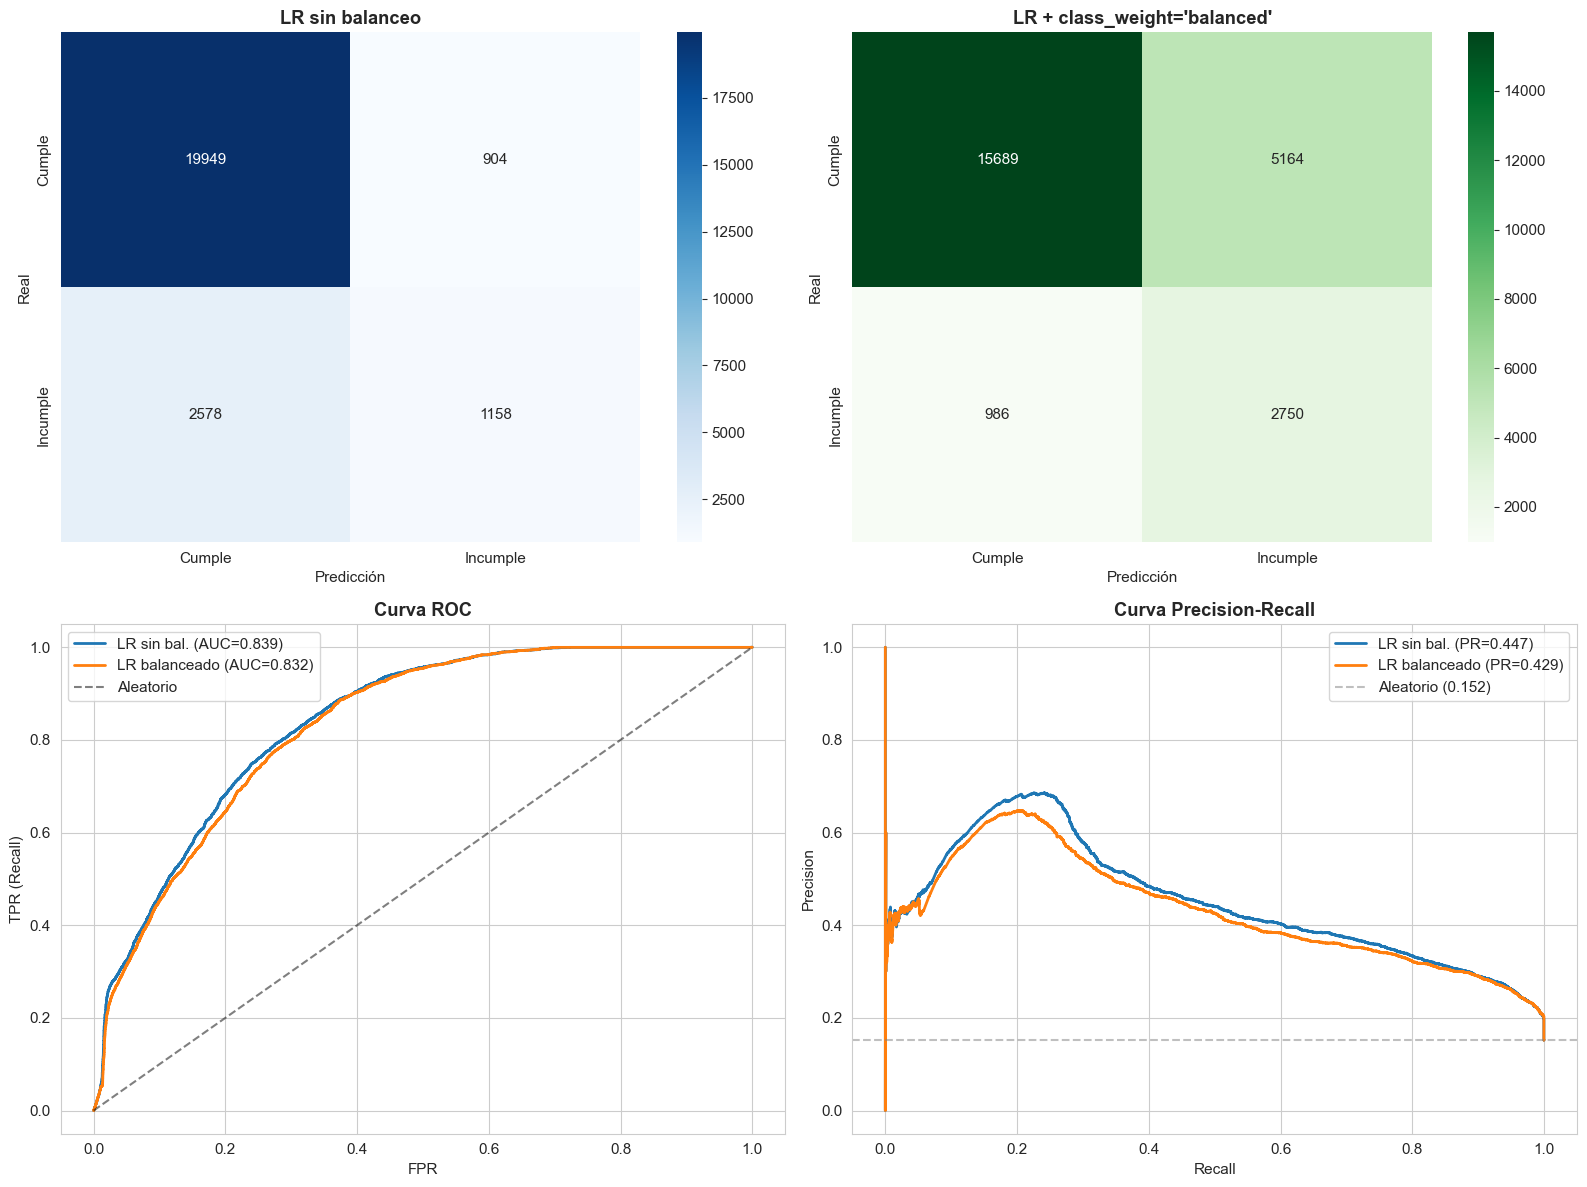


INTERPRETACIÓN

  LR SIN BALANCEO:
   • TP=1,158 | FN=2,578 | FP=904 | TN=19,949
   • Pérdida fiscal (FN × $71,157): $183,442,124

  LR + CLASS_WEIGHT='BALANCED':
   • TP=2,750 | FN=986 | FP=5,164 | TN=15,689
   • Pérdida fiscal (FN × $71,157): $70,160,564



In [12]:
# Visualización de LR

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Matriz de confusión sin balanceo
cm_base = confusion_matrix(y_val, y_pred)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Cumple', 'Incumple'], yticklabels=['Cumple', 'Incumple'])
axes[0, 0].set_title('LR sin balanceo', fontweight='bold')
axes[0, 0].set_ylabel('Real')
axes[0, 0].set_xlabel('Predicción')

# Matriz de confusión con balanceo
cm_bal = confusion_matrix(y_val, y_pred_b)
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1],
            xticklabels=['Cumple', 'Incumple'], yticklabels=['Cumple', 'Incumple'])
axes[0, 1].set_title("LR + class_weight='balanced'", fontweight='bold')
axes[0, 1].set_ylabel('Real')
axes[0, 1].set_xlabel('Predicción')

# Curva ROC
fpr_base, tpr_base, _ = roc_curve(y_val, y_proba)
fpr_bal,  tpr_bal,  _ = roc_curve(y_val, y_proba_b)
axes[1, 0].plot(fpr_base, tpr_base,
                label=f"LR sin bal. (AUC={resultados_lr['LR sin balanceo']['ROC-AUC']:.3f})",
                linewidth=2)
axes[1, 0].plot(fpr_bal, tpr_bal,
                label=f"LR balanceado (AUC={resultados_lr['LR + class_weight=balanced']['ROC-AUC']:.3f})",
                linewidth=2)
axes[1, 0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
axes[1, 0].set_title('Curva ROC', fontweight='bold')
axes[1, 0].set_xlabel('FPR')
axes[1, 0].set_ylabel('TPR (Recall)')
axes[1, 0].legend()

# Curva PR
prec_base, rec_base, _ = precision_recall_curve(y_val, y_proba)
prec_bal,  rec_bal,  _ = precision_recall_curve(y_val, y_proba_b)
axes[1, 1].plot(rec_base, prec_base,
                label=f"LR sin bal. (PR={resultados_lr['LR sin balanceo']['PR-AUC']:.3f})",
                linewidth=2)
axes[1, 1].plot(rec_bal, prec_bal,
                label=f"LR balanceado (PR={resultados_lr['LR + class_weight=balanced']['PR-AUC']:.3f})",
                linewidth=2)
axes[1, 1].axhline(y=prevalencia_val, color='gray', linestyle='--', alpha=0.5,
                   label=f'Aleatorio ({prevalencia_val:.3f})')
axes[1, 1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Análisis fiscal
tn, fp, fn, tp = cm_base.ravel()
tn_b, fp_b, fn_b, tp_b = cm_bal.ravel()
multa_promedio = df_val.loc[df_val['target']==1, 'penalty_charged'].mean()

print("\n" + "=" * 70)
print("INTERPRETACIÓN")
print("=" * 70)
print(f"""
  LR SIN BALANCEO:
   • TP={tp:,} | FN={fn:,} | FP={fp:,} | TN={tn:,}
   • Pérdida fiscal (FN × ${multa_promedio:,.0f}): ${fn * multa_promedio:,.0f}

  LR + CLASS_WEIGHT='BALANCED':
   • TP={tp_b:,} | FN={fn_b:,} | FP={fp_b:,} | TN={tn_b:,}
   • Pérdida fiscal (FN × ${multa_promedio:,.0f}): ${fn_b * multa_promedio:,.0f}
""")

In [13]:
# Random Forest

# RF usa las features directamente (sin OHE, sin escalado)
X_train_rf = X_train.copy()
X_val_rf   = X_val.copy()
X_test_rf  = X_test.copy()

print("=" * 70)
print("PREPARACIÓN PARA RANDOM FOREST")
print("=" * 70)
print(f"\nDimensiones (sin OHE ni escalado):")
print(f"   X_train_rf: {X_train_rf.shape}")
print(f"   X_val_rf:   {X_val_rf.shape}")
print(f"   X_test_rf:  {X_test_rf.shape}")

resultados_rf = {}

# --- VARIANTE 1: RF sin balanceo ---
print("\n" + "=" * 70)
print("RANDOM FOREST SIN BALANCEO")
print("=" * 70)
t0 = time.time()
rf_base = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=20,
    n_jobs=-1, random_state=SEED
)
rf_base.fit(X_train_rf, y_train)
print(f"   {time.time()-t0:.2f}s")

y_pred_rf  = rf_base.predict(X_val_rf)
y_proba_rf = rf_base.predict_proba(X_val_rf)[:, 1]
resultados_rf['RF sin balanceo'] = {
    'Accuracy':  accuracy_score(y_val, y_pred_rf),
    'Precision': precision_score(y_val, y_pred_rf, zero_division=0),
    'Recall':    recall_score(y_val, y_pred_rf, zero_division=0),
    'F1':        f1_score(y_val, y_pred_rf, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_val, y_proba_rf),
    'PR-AUC':    average_precision_score(y_val, y_proba_rf),
}

# --- VARIANTE 2: RF + class_weight ---
print("\n" + "=" * 70)
print("RANDOM FOREST + class_weight='balanced'")
print("=" * 70)
t0 = time.time()
rf_bal = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=20,
    class_weight='balanced', n_jobs=-1, random_state=SEED
)
rf_bal.fit(X_train_rf, y_train)
print(f"  {time.time()-t0:.2f}s")

y_pred_rf_b  = rf_bal.predict(X_val_rf)
y_proba_rf_b = rf_bal.predict_proba(X_val_rf)[:, 1]
resultados_rf['RF + class_weight=balanced'] = {
    'Accuracy':  accuracy_score(y_val, y_pred_rf_b),
    'Precision': precision_score(y_val, y_pred_rf_b, zero_division=0),
    'Recall':    recall_score(y_val, y_pred_rf_b, zero_division=0),
    'F1':        f1_score(y_val, y_pred_rf_b, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_val, y_proba_rf_b),
    'PR-AUC':    average_precision_score(y_val, y_proba_rf_b),
}

# --- TABLA COMPARATIVA ---
print("\n" + "=" * 70)
print("RESULTADOS - RANDOM FOREST")
print("=" * 70)
df_rf = pd.DataFrame(resultados_rf).T.round(4)
print(df_rf.to_string())

print("\n" + "=" * 70)
print("RANDOM FOREST vs REGRESIÓN LOGÍSTICA (en val)")
print("=" * 70)
df_global = pd.concat([
    pd.DataFrame(resultados_lr).T.round(4),
    pd.DataFrame(resultados_rf).T.round(4),
])
print(df_global.to_string())

PREPARACIÓN PARA RANDOM FOREST

Dimensiones (sin OHE ni escalado):
   X_train_rf: (121025, 30)
   X_val_rf:   (24589, 30)
   X_test_rf:  (20875, 30)

RANDOM FOREST SIN BALANCEO
   30.43s

RANDOM FOREST + class_weight='balanced'
  27.19s

RESULTADOS - RANDOM FOREST
                            Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
RF sin balanceo               0.8717     0.6053  0.4478  0.5148   0.8666  0.5625
RF + class_weight=balanced    0.7819     0.3884  0.7572  0.5134   0.8660  0.5647

RANDOM FOREST vs REGRESIÓN LOGÍSTICA (en val)
                            Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
LR sin balanceo               0.8584     0.5616  0.3100  0.3994   0.8394  0.4473
LR + class_weight=balanced    0.7499     0.3475  0.7361  0.4721   0.8320  0.4288
RF sin balanceo               0.8717     0.6053  0.4478  0.5148   0.8666  0.5625
RF + class_weight=balanced    0.7819     0.3884  0.7572  0.5134   0.8660  0.5647


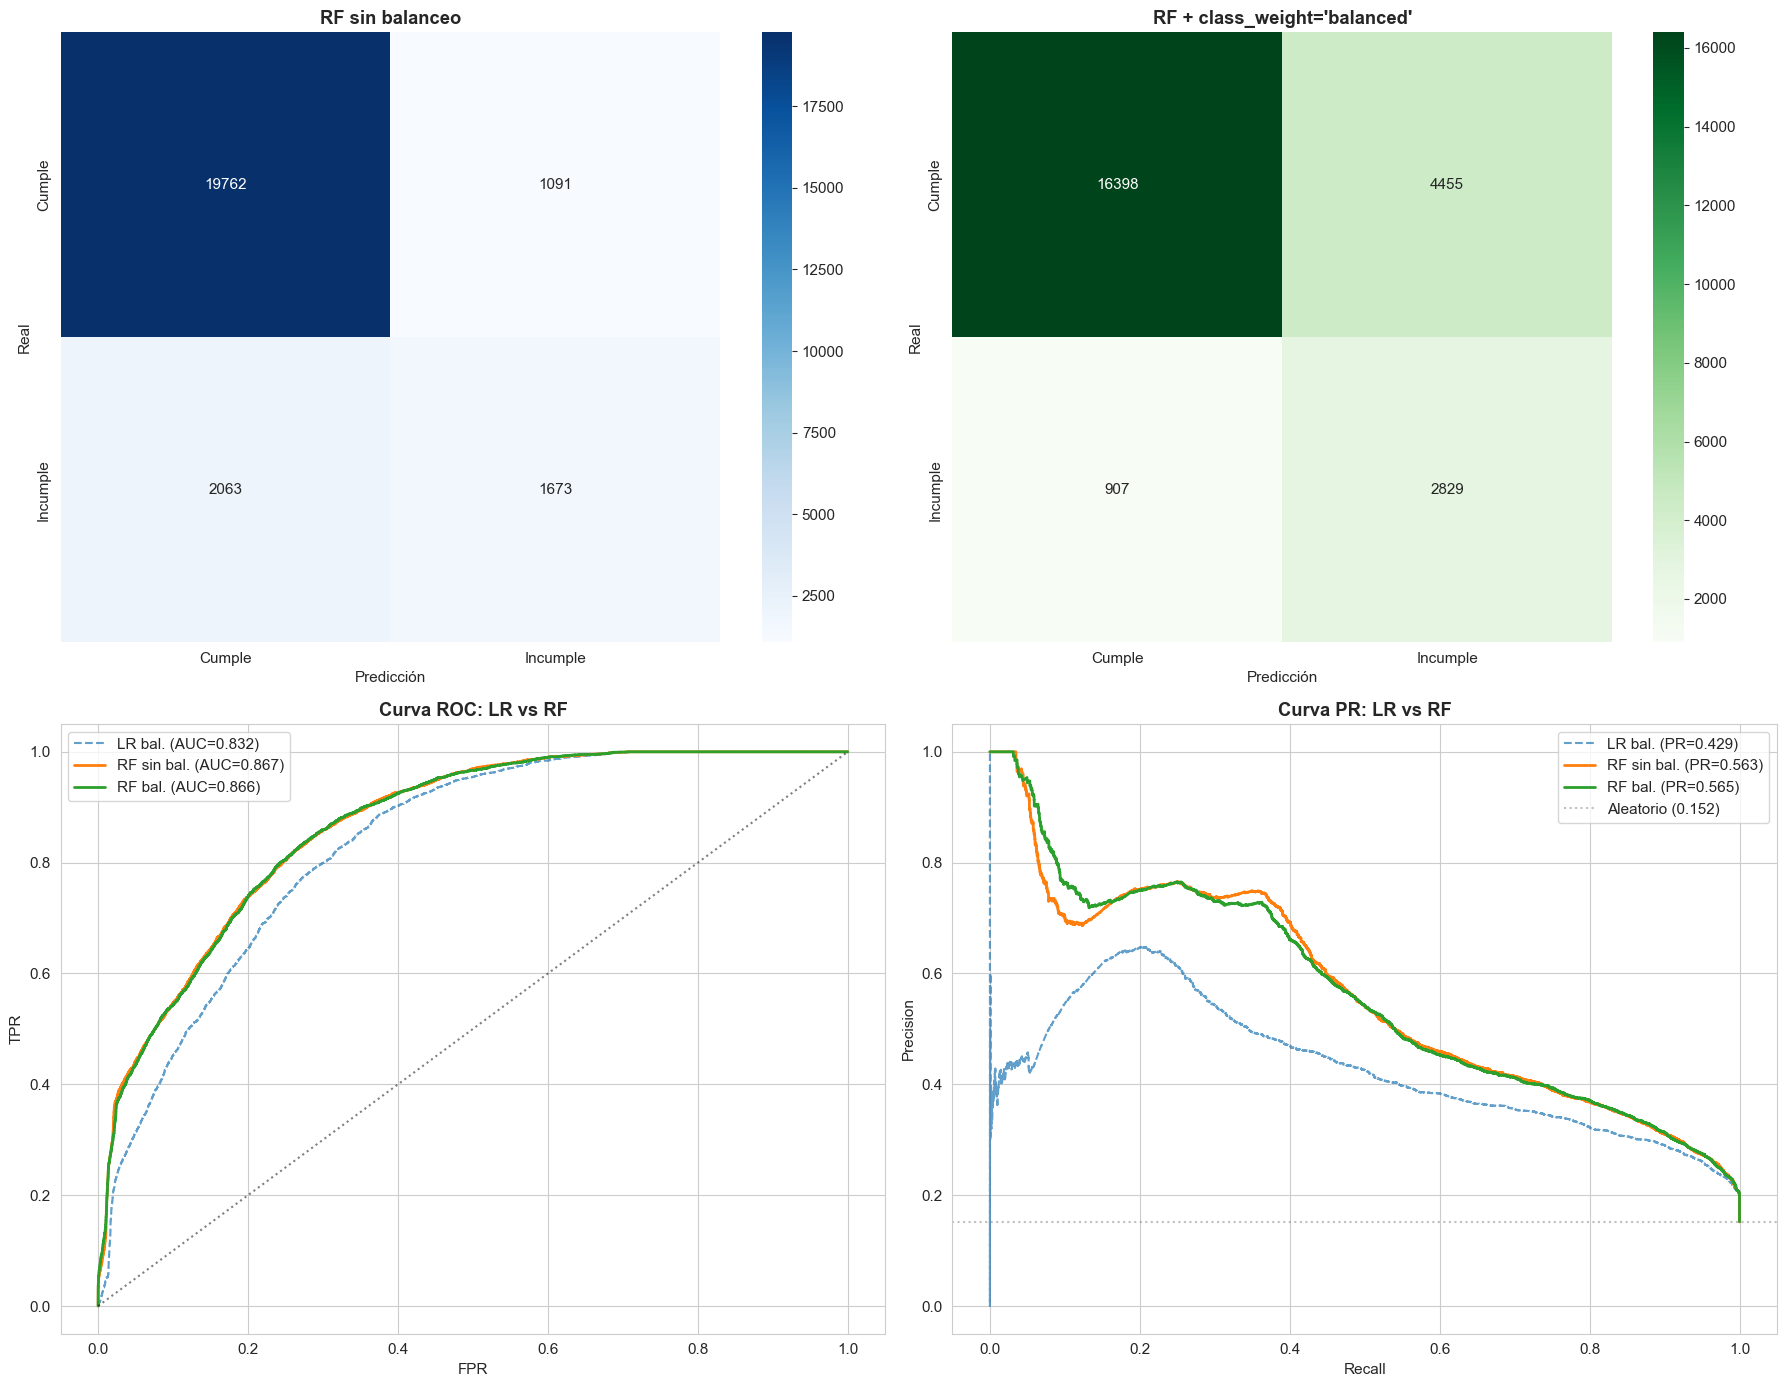


FEATURE IMPORTANCE - Random Forest balanceado (top 20)


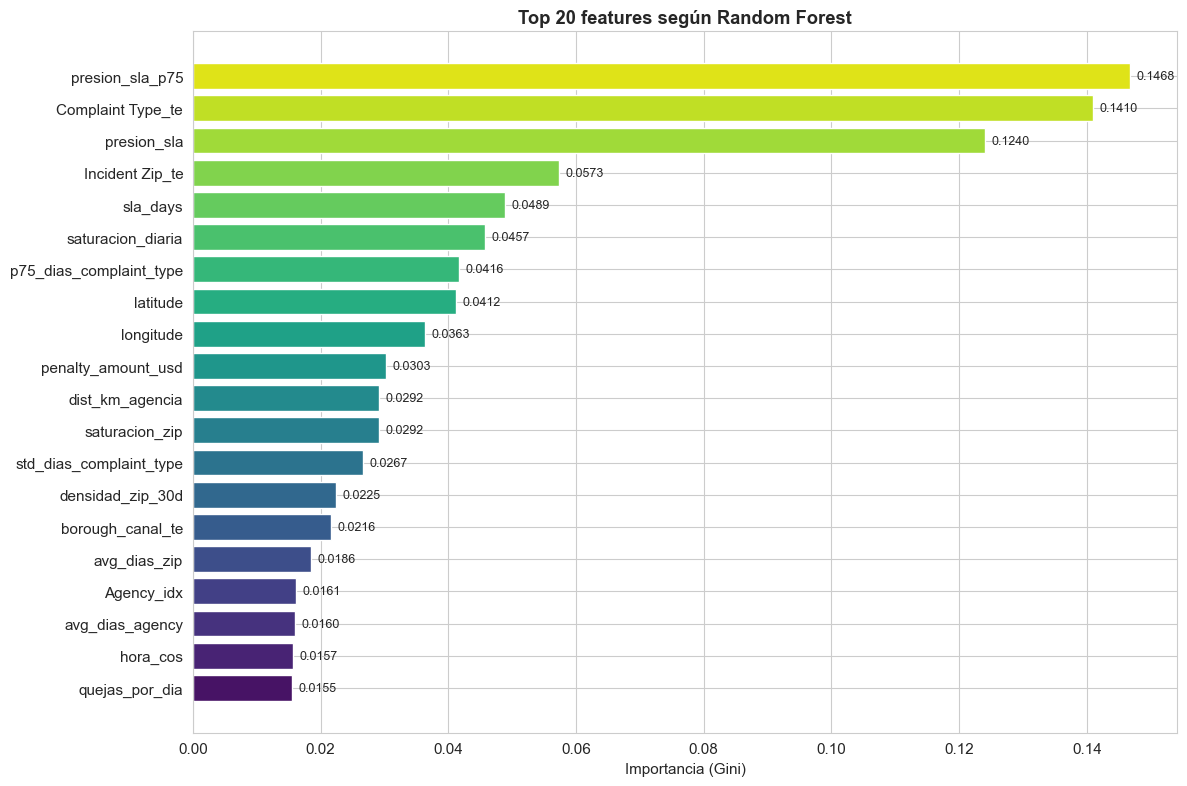


Top 20 features:
                feature  importance
        presion_sla_p75    0.146785
      Complaint Type_te    0.140968
            presion_sla    0.124043
        Incident Zip_te    0.057309
               sla_days    0.048865
      saturacion_diaria    0.045709
p75_dias_complaint_type    0.041644
               latitude    0.041205
              longitude    0.036305
     penalty_amount_usd    0.030268
        dist_km_agencia    0.029196
         saturacion_zip    0.029157
std_dias_complaint_type    0.026697
       densidad_zip_30d    0.022463
       borough_canal_te    0.021606
           avg_dias_zip    0.018554
             Agency_idx    0.016117
        avg_dias_agency    0.016033
               hora_cos    0.015678
         quejas_por_dia    0.015517

ANÁLISIS DE PÉRDIDA FISCAL - RANDOM FOREST

  RF sin balanceo:
    TP=1,673 | FN=2,063 | FP=1,091 | TN=19,762
    Pérdida fiscal: $146,796,393

  RF + class_weight='balanced':
    TP=2,829 | FN=907 | FP=4,455 | TN=16,398
    

In [14]:
# Visualización + Feature Importance de RF

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Matrices de confusión
cm_rf = confusion_matrix(y_val, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Cumple', 'Incumple'], yticklabels=['Cumple', 'Incumple'])
axes[0, 0].set_title('RF sin balanceo', fontweight='bold')
axes[0, 0].set_ylabel('Real'); axes[0, 0].set_xlabel('Predicción')

cm_rf_b = confusion_matrix(y_val, y_pred_rf_b)
sns.heatmap(cm_rf_b, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1],
            xticklabels=['Cumple', 'Incumple'], yticklabels=['Cumple', 'Incumple'])
axes[0, 1].set_title("RF + class_weight='balanced'", fontweight='bold')
axes[0, 1].set_ylabel('Real'); axes[0, 1].set_xlabel('Predicción')

# Curvas ROC y PR comparativas (todos los modelos balanceados)
fpr_rf, tpr_rf, _   = roc_curve(y_val, y_proba_rf)
fpr_rfb, tpr_rfb, _ = roc_curve(y_val, y_proba_rf_b)
prec_rf,  rec_rf,  _ = precision_recall_curve(y_val, y_proba_rf)
prec_rfb, rec_rfb, _ = precision_recall_curve(y_val, y_proba_rf_b)

# Recuperar curvas de LR del paso anterior
fpr_lr, tpr_lr, _ = roc_curve(y_val, lr_bal.predict_proba(X_val_lr_scaled)[:, 1])
prec_lr, rec_lr, _ = precision_recall_curve(y_val, lr_bal.predict_proba(X_val_lr_scaled)[:, 1])

axes[1, 0].plot(fpr_lr, tpr_lr, '--', label=f"LR bal. (AUC={resultados_lr['LR + class_weight=balanced']['ROC-AUC']:.3f})", alpha=0.7)
axes[1, 0].plot(fpr_rf, tpr_rf, '-', label=f"RF sin bal. (AUC={resultados_rf['RF sin balanceo']['ROC-AUC']:.3f})", linewidth=2)
axes[1, 0].plot(fpr_rfb, tpr_rfb, '-', label=f"RF bal. (AUC={resultados_rf['RF + class_weight=balanced']['ROC-AUC']:.3f})", linewidth=2)
axes[1, 0].plot([0, 1], [0, 1], 'k:', alpha=0.5)
axes[1, 0].set_title('Curva ROC: LR vs RF', fontweight='bold')
axes[1, 0].set_xlabel('FPR'); axes[1, 0].set_ylabel('TPR'); axes[1, 0].legend()

axes[1, 1].plot(rec_lr, prec_lr, '--', label=f"LR bal. (PR={resultados_lr['LR + class_weight=balanced']['PR-AUC']:.3f})", alpha=0.7)
axes[1, 1].plot(rec_rf, prec_rf, '-', label=f"RF sin bal. (PR={resultados_rf['RF sin balanceo']['PR-AUC']:.3f})", linewidth=2)
axes[1, 1].plot(rec_rfb, prec_rfb, '-', label=f"RF bal. (PR={resultados_rf['RF + class_weight=balanced']['PR-AUC']:.3f})", linewidth=2)
axes[1, 1].axhline(y=prevalencia_val, color='gray', linestyle=':', alpha=0.5, label=f'Aleatorio ({prevalencia_val:.3f})')
axes[1, 1].set_title('Curva PR: LR vs RF', fontweight='bold')
axes[1, 1].set_xlabel('Recall'); axes[1, 1].set_ylabel('Precision'); axes[1, 1].legend()

plt.tight_layout()
plt.show()

# --- Feature Importance del RF balanceado ---
print("\n" + "=" * 70)
print("FEATURE IMPORTANCE - Random Forest balanceado (top 20)")
print("=" * 70)

feature_importance_rf = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf_bal.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
top20 = feature_importance_rf.head(20)
colors_fi = sns.color_palette("viridis", len(top20))
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color=colors_fi)
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Top 20 features según Random Forest', fontweight='bold')
for i, v in enumerate(top20['importance'][::-1]):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 20 features:")
print(top20.to_string(index=False))

# --- Análisis fiscal ---
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()
tn_rfb, fp_rfb, fn_rfb, tp_rfb = cm_rf_b.ravel()
multa_promedio = df_val.loc[df_val['target']==1, 'penalty_charged'].mean()

print("\n" + "=" * 70)
print("ANÁLISIS DE PÉRDIDA FISCAL - RANDOM FOREST")
print("=" * 70)
print(f"""
  RF sin balanceo:
    TP={tp_rf:,} | FN={fn_rf:,} | FP={fp_rf:,} | TN={tn_rf:,}
    Pérdida fiscal: ${fn_rf * multa_promedio:,.0f}

  RF + class_weight='balanced':
    TP={tp_rfb:,} | FN={fn_rfb:,} | FP={fp_rfb:,} | TN={tn_rfb:,}
    Pérdida fiscal: ${fn_rfb * multa_promedio:,.0f}
""")

In [15]:
# XGBoost

X_train_xgb = X_train.copy()
X_val_xgb   = X_val.copy()
X_test_xgb  = X_test.copy()

print("=" * 70)
print("PREPARACIÓN PARA XGBOOST")
print("=" * 70)
print(f"\nDimensiones: {X_train_xgb.shape}")

# scale_pos_weight = ratio negativo/positivo en train
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight: {scale_pos_weight:.3f}")
print(f"   (Por cada positivo, vale como {scale_pos_weight:.1f} negativos)")

resultados_xgb = {}

# --- VARIANTE 1: XGBoost sin balanceo ---
print("\n" + "=" * 70)
print("XGBOOST SIN BALANCEO")
print("=" * 70)
t0 = time.time()
xgb_base = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, n_jobs=-1,
    eval_metric='aucpr', tree_method='hist'
)
xgb_base.fit(X_train_xgb, y_train)
print(f"   {time.time()-t0:.2f}s")

y_pred_xgb  = xgb_base.predict(X_val_xgb)
y_proba_xgb = xgb_base.predict_proba(X_val_xgb)[:, 1]
resultados_xgb['XGBoost sin balanceo'] = {
    'Accuracy':  accuracy_score(y_val, y_pred_xgb),
    'Precision': precision_score(y_val, y_pred_xgb, zero_division=0),
    'Recall':    recall_score(y_val, y_pred_xgb, zero_division=0),
    'F1':        f1_score(y_val, y_pred_xgb, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_val, y_proba_xgb),
    'PR-AUC':    average_precision_score(y_val, y_proba_xgb),
}

# --- VARIANTE 2: XGBoost + scale_pos_weight ---
print("\n" + "=" * 70)
print("XGBOOST + scale_pos_weight")
print("=" * 70)
t0 = time.time()
xgb_bal = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=SEED, n_jobs=-1,
    eval_metric='aucpr', tree_method='hist'
)
xgb_bal.fit(X_train_xgb, y_train)
print(f"   {time.time()-t0:.2f}s")

y_pred_xgb_b  = xgb_bal.predict(X_val_xgb)
y_proba_xgb_b = xgb_bal.predict_proba(X_val_xgb)[:, 1]
resultados_xgb['XGBoost + scale_pos_weight'] = {
    'Accuracy':  accuracy_score(y_val, y_pred_xgb_b),
    'Precision': precision_score(y_val, y_pred_xgb_b, zero_division=0),
    'Recall':    recall_score(y_val, y_pred_xgb_b, zero_division=0),
    'F1':        f1_score(y_val, y_pred_xgb_b, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_val, y_proba_xgb_b),
    'PR-AUC':    average_precision_score(y_val, y_proba_xgb_b),
}

# --- TABLA COMPARATIVA ---
print("\n" + "=" * 70)
print("RESULTADOS - XGBOOST")
print("=" * 70)
df_xgb = pd.DataFrame(resultados_xgb).T.round(4)
print(df_xgb.to_string())

print("\n" + "=" * 70)
print("COMPARATIVA GLOBAL: LR vs RF vs XGBoost")
print("=" * 70)
df_global = pd.concat([
    pd.DataFrame(resultados_lr).T.round(4),
    pd.DataFrame(resultados_rf).T.round(4),
    pd.DataFrame(resultados_xgb).T.round(4),
])
print(df_global.to_string())

PREPARACIÓN PARA XGBOOST

Dimensiones: (121025, 30)

scale_pos_weight: 3.582
   (Por cada positivo, vale como 3.6 negativos)

XGBOOST SIN BALANCEO
   16.85s

XGBOOST + scale_pos_weight
   15.20s

RESULTADOS - XGBOOST
                            Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
XGBoost sin balanceo          0.8635     0.5560  0.5051  0.5293   0.8673  0.5486
XGBoost + scale_pos_weight    0.7801     0.3862  0.7594  0.5120   0.8676  0.5615

COMPARATIVA GLOBAL: LR vs RF vs XGBoost
                            Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
LR sin balanceo               0.8584     0.5616  0.3100  0.3994   0.8394  0.4473
LR + class_weight=balanced    0.7499     0.3475  0.7361  0.4721   0.8320  0.4288
RF sin balanceo               0.8717     0.6053  0.4478  0.5148   0.8666  0.5625
RF + class_weight=balanced    0.7819     0.3884  0.7572  0.5134   0.8660  0.5647
XGBoost sin balanceo          0.8635     0.5560  0.5051  0.5293   0.8673  0.5486
XGBoost + sca

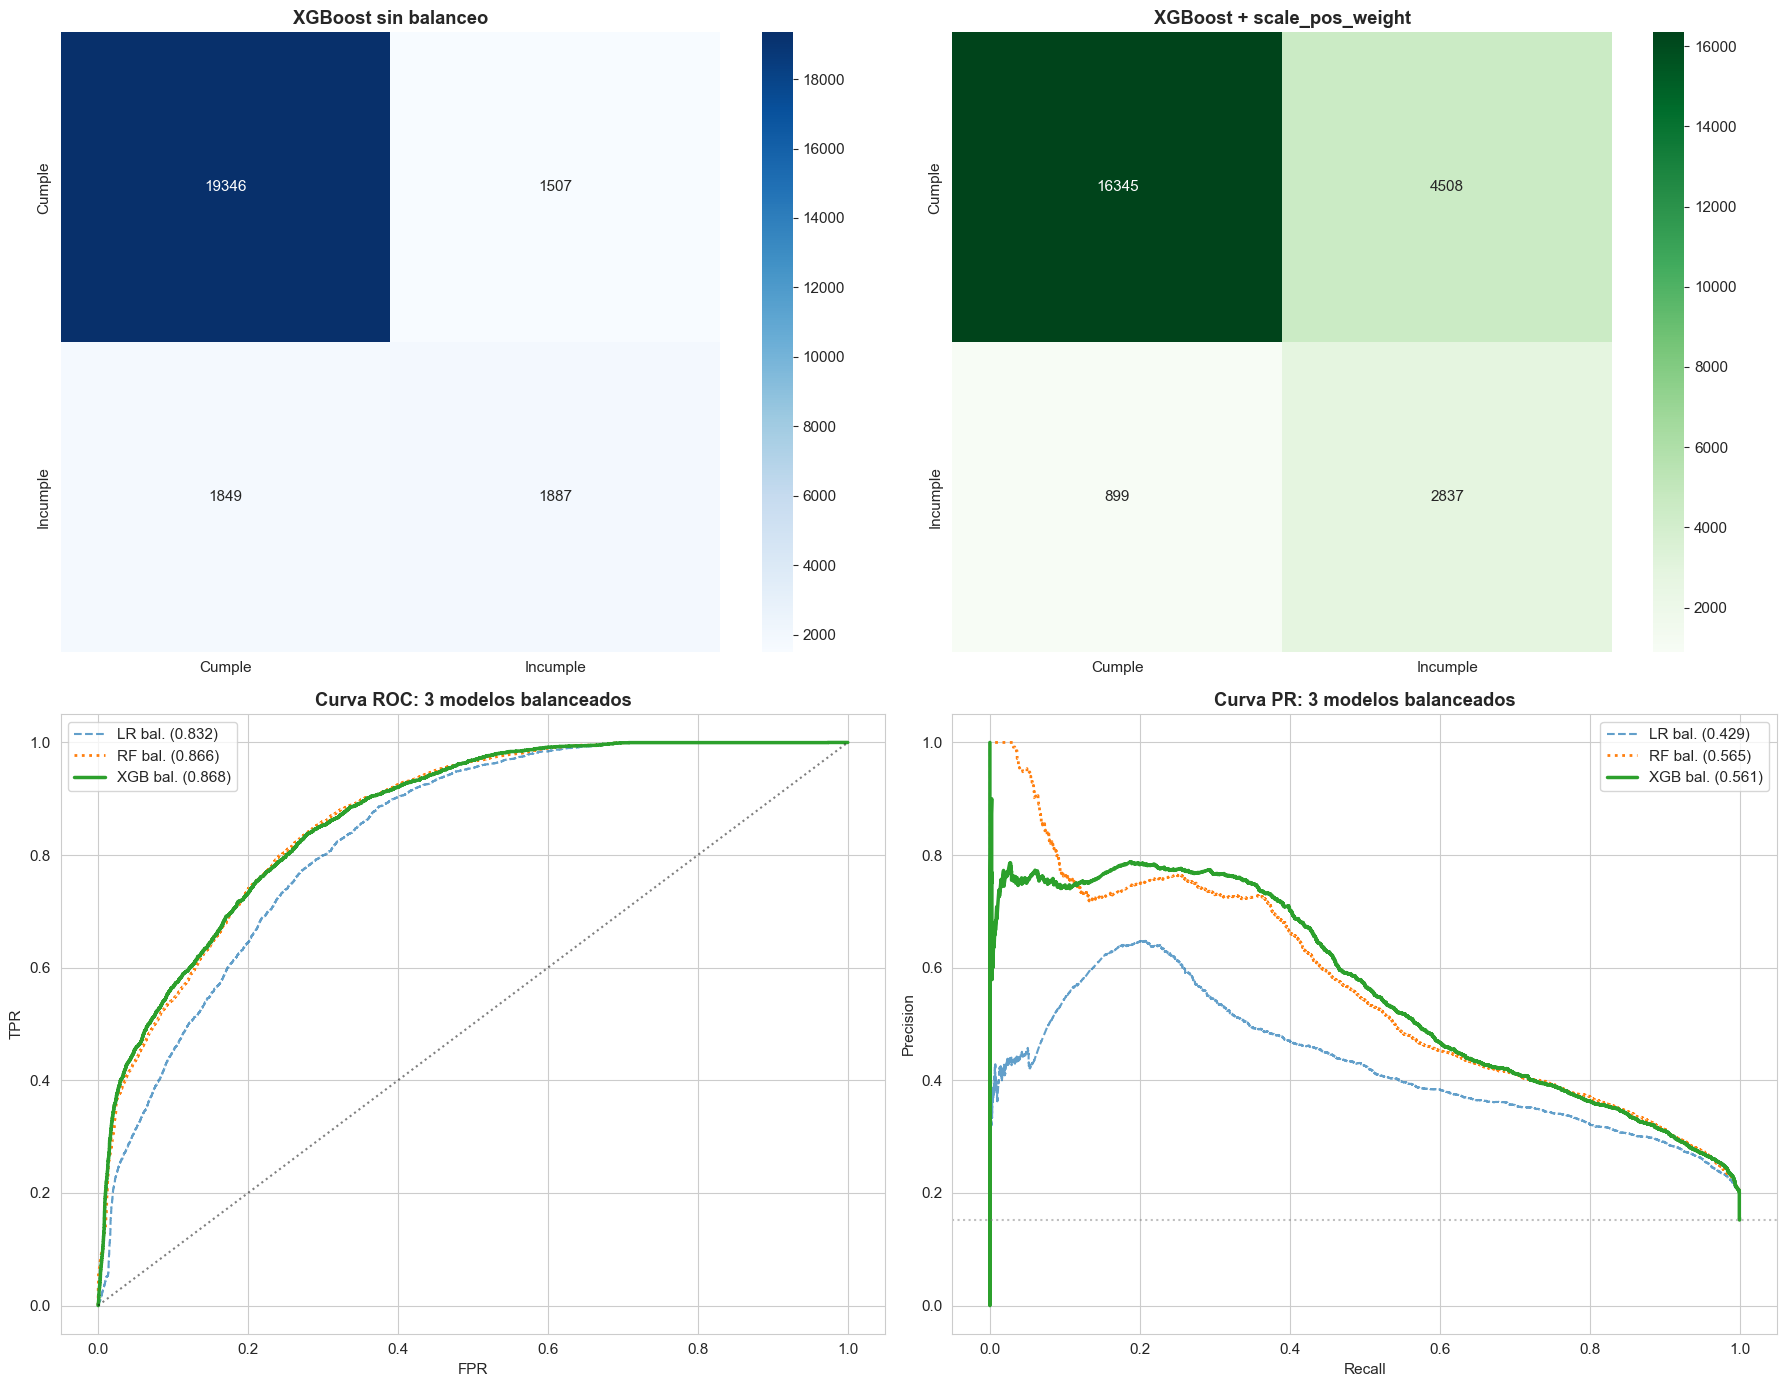


FEATURE IMPORTANCE - XGBoost balanceado (top 20)


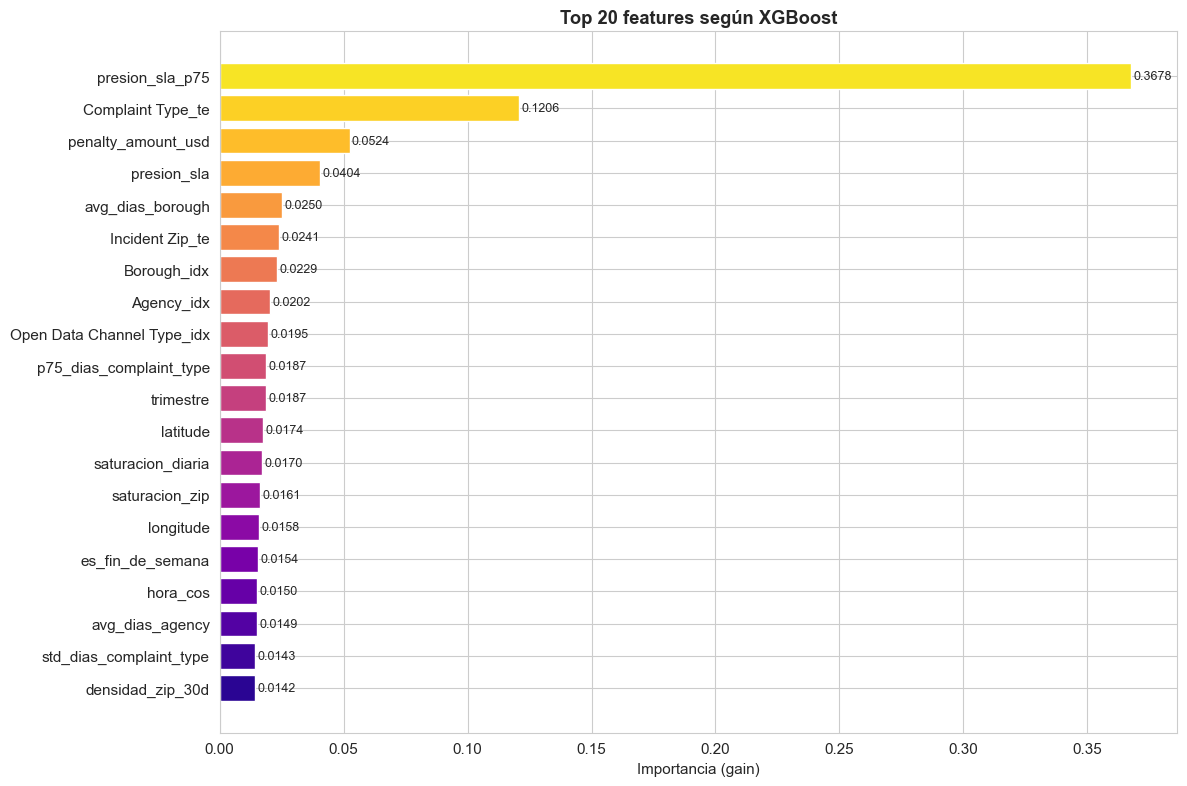


Top 20 (XGBoost):
                   feature  importance
           presion_sla_p75    0.367825
         Complaint Type_te    0.120566
        penalty_amount_usd    0.052368
               presion_sla    0.040407
          avg_dias_borough    0.025025
           Incident Zip_te    0.024103
               Borough_idx    0.022926
                Agency_idx    0.020223
Open Data Channel Type_idx    0.019477
   p75_dias_complaint_type    0.018745
                 trimestre    0.018712
                  latitude    0.017440
         saturacion_diaria    0.017011
            saturacion_zip    0.016105
                 longitude    0.015829
          es_fin_de_semana    0.015420
                  hora_cos    0.014967
           avg_dias_agency    0.014934
   std_dias_complaint_type    0.014348
          densidad_zip_30d    0.014207

ANÁLISIS DE PÉRDIDA FISCAL - XGBoost

  XGBoost sin balanceo:
    TP=1,887 | FN=1,849 | FP=1,507 | TN=19,346
    Pérdida fiscal: $131,568,847

  XGBoost + scale_

In [16]:
# Visualización + Feature Importance XGBoost

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Matrices de confusión
cm_xgb = confusion_matrix(y_val, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Cumple', 'Incumple'], yticklabels=['Cumple', 'Incumple'])
axes[0, 0].set_title('XGBoost sin balanceo', fontweight='bold')

cm_xgb_b = confusion_matrix(y_val, y_pred_xgb_b)
sns.heatmap(cm_xgb_b, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1],
            xticklabels=['Cumple', 'Incumple'], yticklabels=['Cumple', 'Incumple'])
axes[0, 1].set_title("XGBoost + scale_pos_weight", fontweight='bold')

# Curvas comparativas: los 3 modelos balanceados
fpr_xgbb, tpr_xgbb, _ = roc_curve(y_val, y_proba_xgb_b)
prec_xgbb, rec_xgbb, _ = precision_recall_curve(y_val, y_proba_xgb_b)

axes[1, 0].plot(fpr_lr, tpr_lr, '--', label=f"LR bal. ({resultados_lr['LR + class_weight=balanced']['ROC-AUC']:.3f})", alpha=0.7)
axes[1, 0].plot(fpr_rfb, tpr_rfb, ':', label=f"RF bal. ({resultados_rf['RF + class_weight=balanced']['ROC-AUC']:.3f})", linewidth=2)
axes[1, 0].plot(fpr_xgbb, tpr_xgbb, '-', label=f"XGB bal. ({resultados_xgb['XGBoost + scale_pos_weight']['ROC-AUC']:.3f})", linewidth=2.5)
axes[1, 0].plot([0, 1], [0, 1], 'k:', alpha=0.5)
axes[1, 0].set_title('Curva ROC: 3 modelos balanceados', fontweight='bold')
axes[1, 0].set_xlabel('FPR'); axes[1, 0].set_ylabel('TPR'); axes[1, 0].legend()

axes[1, 1].plot(rec_lr, prec_lr, '--', label=f"LR bal. ({resultados_lr['LR + class_weight=balanced']['PR-AUC']:.3f})", alpha=0.7)
axes[1, 1].plot(rec_rfb, prec_rfb, ':', label=f"RF bal. ({resultados_rf['RF + class_weight=balanced']['PR-AUC']:.3f})", linewidth=2)
axes[1, 1].plot(rec_xgbb, prec_xgbb, '-', label=f"XGB bal. ({resultados_xgb['XGBoost + scale_pos_weight']['PR-AUC']:.3f})", linewidth=2.5)
axes[1, 1].axhline(y=prevalencia_val, color='gray', linestyle=':', alpha=0.5)
axes[1, 1].set_title('Curva PR: 3 modelos balanceados', fontweight='bold')
axes[1, 1].set_xlabel('Recall'); axes[1, 1].set_ylabel('Precision'); axes[1, 1].legend()

plt.tight_layout()
plt.show()

# --- Feature Importance ---
print("\n" + "=" * 70)
print("FEATURE IMPORTANCE - XGBoost balanceado (top 20)")
print("=" * 70)

feature_importance_xgb = pd.DataFrame({
    'feature': FEATURES,
    'importance': xgb_bal.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
top20_xgb = feature_importance_xgb.head(20)
colors_fi = sns.color_palette("plasma", len(top20_xgb))
ax.barh(top20_xgb['feature'][::-1], top20_xgb['importance'][::-1], color=colors_fi)
ax.set_xlabel('Importancia (gain)')
ax.set_title('Top 20 features según XGBoost', fontweight='bold')
for i, v in enumerate(top20_xgb['importance'][::-1]):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 20 (XGBoost):")
print(top20_xgb.to_string(index=False))

# --- Análisis fiscal ---
tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()
tn_xgbb, fp_xgbb, fn_xgbb, tp_xgbb = cm_xgb_b.ravel()
multa_promedio = df_val.loc[df_val['target']==1, 'penalty_charged'].mean()

print("\n" + "=" * 70)
print("ANÁLISIS DE PÉRDIDA FISCAL - XGBoost")
print("=" * 70)
print(f"""
  XGBoost sin balanceo:
    TP={tp_xgb:,} | FN={fn_xgb:,} | FP={fp_xgb:,} | TN={tn_xgb:,}
    Pérdida fiscal: ${fn_xgb * multa_promedio:,.0f}

  XGBoost + scale_pos_weight:
    TP={tp_xgbb:,} | FN={fn_xgbb:,} | FP={fp_xgbb:,} | TN={tn_xgbb:,}
    Pérdida fiscal: ${fn_xgbb * multa_promedio:,.0f}
""")

In [17]:
# SMOTE como segunda estrategia de balanceo

print("=" * 70)
print("APLICACIÓN DE SMOTE AL TRAIN")
print("=" * 70)

# SMOTE para árboles (RF y XGBoost) - 30 features
print("\n SMOTE sobre X_train (30 features para árboles)...")
t0 = time.time()
smote_tree = SMOTE(random_state=SEED, k_neighbors=5)
X_train_smote_tree, y_train_smote_tree = smote_tree.fit_resample(X_train, y_train)
print(f"   {time.time()-t0:.2f}s")

# SMOTE para LR (sobre datos escalados con OHE)
print("\nSMOTE sobre X_train_lr_scaled (125 features para LR)...")
t0 = time.time()
smote_lr = SMOTE(random_state=SEED, k_neighbors=5)
X_train_smote_lr, y_train_smote_lr = smote_lr.fit_resample(X_train_lr_scaled, y_train)
print(f"   {time.time()-t0:.2f}s")

# Comparación antes/después
print("\n" + "=" * 70)
print("DISTRIBUCIÓN: ANTES vs DESPUÉS DE SMOTE")
print("=" * 70)
print(f"\n  ANTES (Train original):")
print(f"    Clase 0 (cumple):   {(y_train==0).sum():>8,} ({(y_train==0).mean()*100:.2f}%)")
print(f"    Clase 1 (incumple): {(y_train==1).sum():>8,} ({(y_train==1).mean()*100:.2f}%)")
print(f"    Total:              {len(y_train):>8,}")

print(f"\n  DESPUÉS (Train balanceado):")
print(f"    Clase 0 (cumple):   {(y_train_smote_tree==0).sum():>8,} ({(y_train_smote_tree==0).mean()*100:.2f}%)")
print(f"    Clase 1 (incumple): {(y_train_smote_tree==1).sum():>8,} ({(y_train_smote_tree==1).mean()*100:.2f}%)")
print(f"    Total:              {len(y_train_smote_tree):>8,}")

n_sinteticos = (y_train_smote_tree==1).sum() - (y_train==1).sum()
print(f"\n  Ejemplos sintéticos generados: {n_sinteticos:,}")

APLICACIÓN DE SMOTE AL TRAIN

 SMOTE sobre X_train (30 features para árboles)...
   17.67s

SMOTE sobre X_train_lr_scaled (125 features para LR)...
   17.14s

DISTRIBUCIÓN: ANTES vs DESPUÉS DE SMOTE

  ANTES (Train original):
    Clase 0 (cumple):     94,612 (78.18%)
    Clase 1 (incumple):   26,413 (21.82%)
    Total:               121,025

  DESPUÉS (Train balanceado):
    Clase 0 (cumple):     94,612 (50.00%)
    Clase 1 (incumple):   94,612 (50.00%)
    Total:               189,224

  Ejemplos sintéticos generados: 68,199


In [18]:
# Entrenar 3 modelos con SMOTE


resultados_smote = {}

# --- LR + SMOTE ---
print("=" * 70)
print("REGRESIÓN LOGÍSTICA + SMOTE")
print("=" * 70)
t0 = time.time()
lr_smote = LogisticRegression(max_iter=2000, random_state=SEED, solver='lbfgs', n_jobs=-1)
lr_smote.fit(X_train_smote_lr, y_train_smote_lr)
print(f"   {time.time()-t0:.2f}s")

y_pred = lr_smote.predict(X_val_lr_scaled)
y_proba = lr_smote.predict_proba(X_val_lr_scaled)[:, 1]
resultados_smote['LR + SMOTE'] = {
    'Accuracy':  accuracy_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred, zero_division=0),
    'Recall':    recall_score(y_val, y_pred, zero_division=0),
    'F1':        f1_score(y_val, y_pred, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_val, y_proba),
    'PR-AUC':    average_precision_score(y_val, y_proba),
}

# --- RF + SMOTE ---
print("\n" + "=" * 70)
print("RANDOM FOREST + SMOTE")
print("=" * 70)
t0 = time.time()
rf_smote = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=20,
    n_jobs=-1, random_state=SEED
)
rf_smote.fit(X_train_smote_tree, y_train_smote_tree)
print(f"   {time.time()-t0:.2f}s")

y_pred = rf_smote.predict(X_val)
y_proba = rf_smote.predict_proba(X_val)[:, 1]
resultados_smote['RF + SMOTE'] = {
    'Accuracy':  accuracy_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred, zero_division=0),
    'Recall':    recall_score(y_val, y_pred, zero_division=0),
    'F1':        f1_score(y_val, y_pred, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_val, y_proba),
    'PR-AUC':    average_precision_score(y_val, y_proba),
}

# --- XGBoost + SMOTE ---
print("\n" + "=" * 70)
print("XGBOOST + SMOTE")
print("=" * 70)
t0 = time.time()
xgb_smote = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, n_jobs=-1,
    eval_metric='aucpr', tree_method='hist'
)
xgb_smote.fit(X_train_smote_tree, y_train_smote_tree)
print(f"   {time.time()-t0:.2f}s")

y_pred = xgb_smote.predict(X_val)
y_proba = xgb_smote.predict_proba(X_val)[:, 1]
resultados_smote['XGBoost + SMOTE'] = {
    'Accuracy':  accuracy_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred, zero_division=0),
    'Recall':    recall_score(y_val, y_pred, zero_division=0),
    'F1':        f1_score(y_val, y_pred, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_val, y_proba),
    'PR-AUC':    average_precision_score(y_val, y_proba),
}

# --- TABLA COMPARATIVA ---
print("\n" + "=" * 70)
print("RESULTADOS - 3 MODELOS CON SMOTE")
print("=" * 70)
df_smote = pd.DataFrame(resultados_smote).T.round(4)
print(df_smote.to_string())

REGRESIÓN LOGÍSTICA + SMOTE
   5.61s

RANDOM FOREST + SMOTE
   63.84s

XGBOOST + SMOTE
   27.03s

RESULTADOS - 3 MODELOS CON SMOTE
                 Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
LR + SMOTE         0.7500     0.3504  0.7559  0.4788   0.8347  0.4341
RF + SMOTE         0.8345     0.4649  0.5894  0.5198   0.8641  0.5635
XGBoost + SMOTE    0.8537     0.5178  0.5377  0.5276   0.8622  0.5381


TABLA COMPLETA: 9 MODELOS (3 familias × 3 estrategias)

                         Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
LR (sin balanceo)         0.8584     0.5616  0.3100  0.3994   0.8394  0.4473
LR + class_weight         0.7499     0.3475  0.7361  0.4721   0.8320  0.4288
LR + SMOTE                0.7500     0.3504  0.7559  0.4788   0.8347  0.4341
RF (sin balanceo)         0.8717     0.6053  0.4478  0.5148   0.8666  0.5625
RF + class_weight         0.7819     0.3884  0.7572  0.5134   0.8660  0.5647
RF + SMOTE                0.8345     0.4649  0.5894  0.5198   0.8641  0.5635
XGB (sin balanceo)        0.8635     0.5560  0.5051  0.5293   0.8673  0.5486
XGB + scale_pos_weight    0.7801     0.3862  0.7594  0.5120   0.8676  0.5615
XGB + SMOTE               0.8537     0.5178  0.5377  0.5276   0.8622  0.5381


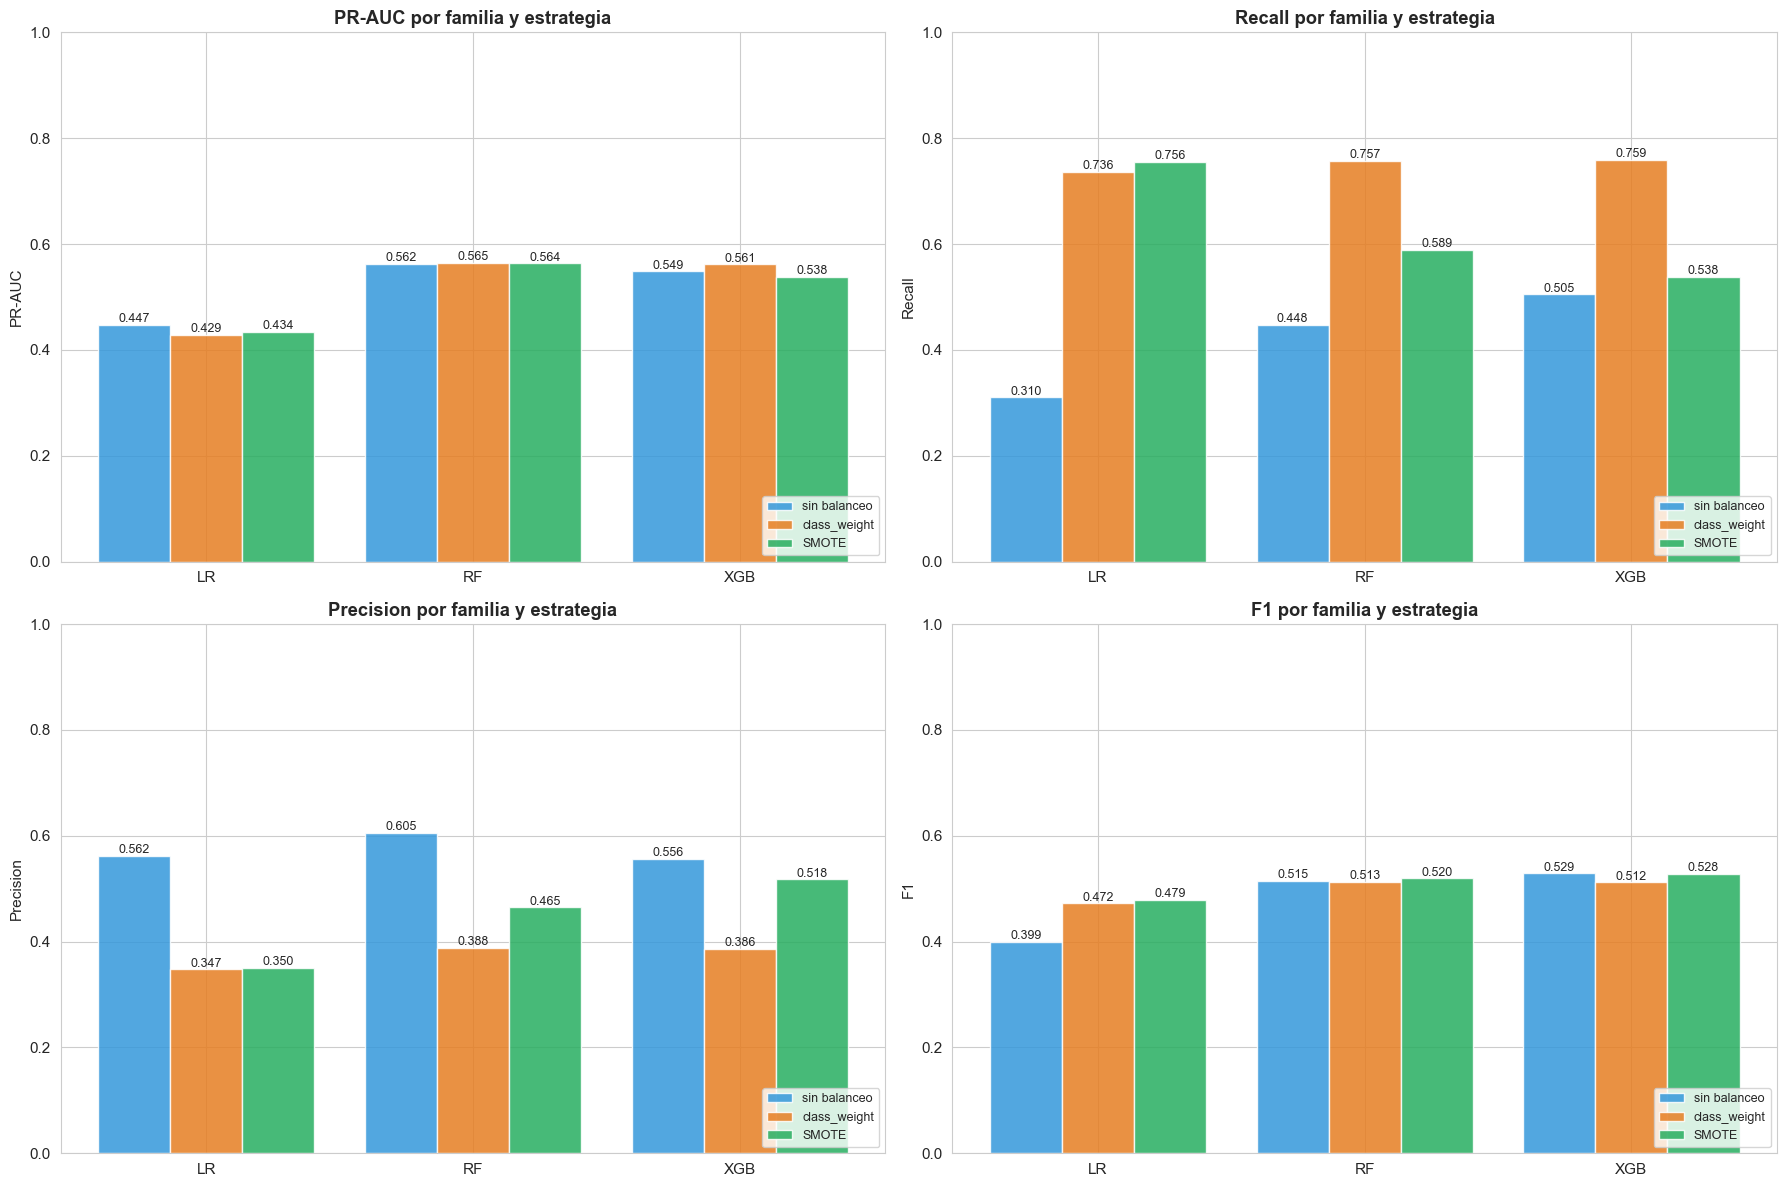


IMPACTO FISCAL - 6 modelos balanceados (val)

  Pérdida máxima: $265,841,651

  Modelo                   |     TP |     FN |     FP |         Pérdida |          Ahorro
  ------------------------------------------------------------------------------------------
  LR + class_weight        |  2,750 |    986 |  5,164 | $   70,160,564 | $  195,681,087
  LR + SMOTE               |  2,824 |    912 |  5,236 | $   64,894,964 | $  200,946,687
  RF + class_weight        |  2,829 |    907 |  4,455 | $   64,539,180 | $  201,302,471
  RF + SMOTE               |  2,202 |  1,534 |  2,535 | $  109,154,468 | $  156,687,183
  XGB + scale_pos_weight   |  2,837 |    899 |  4,508 | $   63,969,926 | $  201,871,725
  XGB + SMOTE              |  2,009 |  1,727 |  1,871 | $  122,887,723 | $  142,953,928

GANADORES POR MÉTRICA
   Mejor PR-AUC: RF + class_weight (0.5647)
   Mejor F1: XGB (sin balanceo) (0.5293)
   Mejor Recall: XGB + scale_pos_weight (0.7594)
   Menor pérdida fiscal: XGB + scale_pos_weight ($63,

In [19]:
# Comparación global de las 9 variantes

print("=" * 90)
print("TABLA COMPLETA: 9 MODELOS (3 familias × 3 estrategias)")
print("=" * 90)

estrategias = {
    'LR (sin balanceo)':         resultados_lr['LR sin balanceo'],
    'LR + class_weight':         resultados_lr['LR + class_weight=balanced'],
    'LR + SMOTE':                resultados_smote['LR + SMOTE'],
    'RF (sin balanceo)':         resultados_rf['RF sin balanceo'],
    'RF + class_weight':         resultados_rf['RF + class_weight=balanced'],
    'RF + SMOTE':                resultados_smote['RF + SMOTE'],
    'XGB (sin balanceo)':        resultados_xgb['XGBoost sin balanceo'],
    'XGB + scale_pos_weight':    resultados_xgb['XGBoost + scale_pos_weight'],
    'XGB + SMOTE':               resultados_smote['XGBoost + SMOTE'],
}

df_estrategias = pd.DataFrame(estrategias).T.round(4)
print("\n", df_estrategias.to_string())

# --- Visualización comparativa ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

metricas_plot = ['PR-AUC', 'Recall', 'Precision', 'F1']
familias = {
    'LR':  ['LR (sin balanceo)', 'LR + class_weight', 'LR + SMOTE'],
    'RF':  ['RF (sin balanceo)', 'RF + class_weight', 'RF + SMOTE'],
    'XGB': ['XGB (sin balanceo)', 'XGB + scale_pos_weight', 'XGB + SMOTE'],
}
colores_estrategia = {'sin balanceo': '#3498db', 'class_weight': '#e67e22', 'SMOTE': '#27ae60'}

for idx_metric, metrica in enumerate(metricas_plot):
    ax = axes[idx_metric // 2, idx_metric % 2]
    x_pos = np.arange(len(familias))
    width = 0.27
    
    for i, (etiqueta, color) in enumerate(colores_estrategia.items()):
        valores = []
        for familia, modelos in familias.items():
            key = modelos[i if etiqueta != 'class_weight' else 1]
            if etiqueta == 'sin balanceo':
                key = modelos[0]
            elif etiqueta == 'class_weight':
                key = modelos[1]
            else:
                key = modelos[2]
            valores.append(df_estrategias.loc[key, metrica])
        
        bars = ax.bar(x_pos + (i-1) * width, valores, width,
                       label=etiqueta, color=color, alpha=0.85)
        for bar, val in zip(bars, valores):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', fontsize=9)
    
    ax.set_xticks(x_pos); ax.set_xticklabels(familias.keys())
    ax.set_title(f'{metrica} por familia y estrategia', fontweight='bold')
    ax.set_ylabel(metrica); ax.legend(loc='lower right', fontsize=9)
    ax.set_ylim(0, max(1.0, df_estrategias[metrica].max() * 1.15))

plt.tight_layout()
plt.show()

# --- Impacto fiscal de los 6 modelos balanceados ---
print("\n" + "=" * 90)
print("IMPACTO FISCAL - 6 modelos balanceados (val)")
print("=" * 90)

multa_promedio = df_val.loc[df_val['target']==1, 'penalty_charged'].mean()
multa_total_val = df_val.loc[df_val['target']==1, 'penalty_charged'].sum()

matrices = {
    'LR + class_weight':       confusion_matrix(y_val, lr_bal.predict(X_val_lr_scaled)),
    'LR + SMOTE':              confusion_matrix(y_val, lr_smote.predict(X_val_lr_scaled)),
    'RF + class_weight':       confusion_matrix(y_val, rf_bal.predict(X_val)),
    'RF + SMOTE':              confusion_matrix(y_val, rf_smote.predict(X_val)),
    'XGB + scale_pos_weight':  confusion_matrix(y_val, xgb_bal.predict(X_val)),
    'XGB + SMOTE':             confusion_matrix(y_val, xgb_smote.predict(X_val)),
}

print(f"\n  Pérdida máxima: ${multa_total_val:,.0f}\n")
print(f"  {'Modelo':<24} | {'TP':>6} | {'FN':>6} | {'FP':>6} | {'Pérdida':>15} | {'Ahorro':>15}")
print("  " + "-" * 90)
for nombre, cm in matrices.items():
    tn, fp, fn, tp = cm.ravel()
    perdida = fn * multa_promedio
    ahorro = multa_total_val - perdida
    print(f"  {nombre:<24} | {tp:>6,} | {fn:>6,} | {fp:>6,} | ${perdida:>13,.0f} | ${ahorro:>13,.0f}")

# --- Ganadores por métrica ---
print("\n" + "=" * 90)
print("GANADORES POR MÉTRICA")
print("=" * 90)

for m in ['PR-AUC', 'F1', 'Recall']:
    ganador = df_estrategias[m].idxmax()
    valor = df_estrategias.loc[ganador, m]
    print(f"   Mejor {m}: {ganador} ({valor:.4f})")

# Menor pérdida fiscal
perdidas = {nombre: cm.ravel()[2] * multa_promedio for nombre, cm in matrices.items()}
menor_p = min(perdidas, key=perdidas.get)
print(f"   Menor pérdida fiscal: {menor_p} (${perdidas[menor_p]:,.0f})")

ANÁLISIS DE CORRELACIÓN ENTRE FEATURES


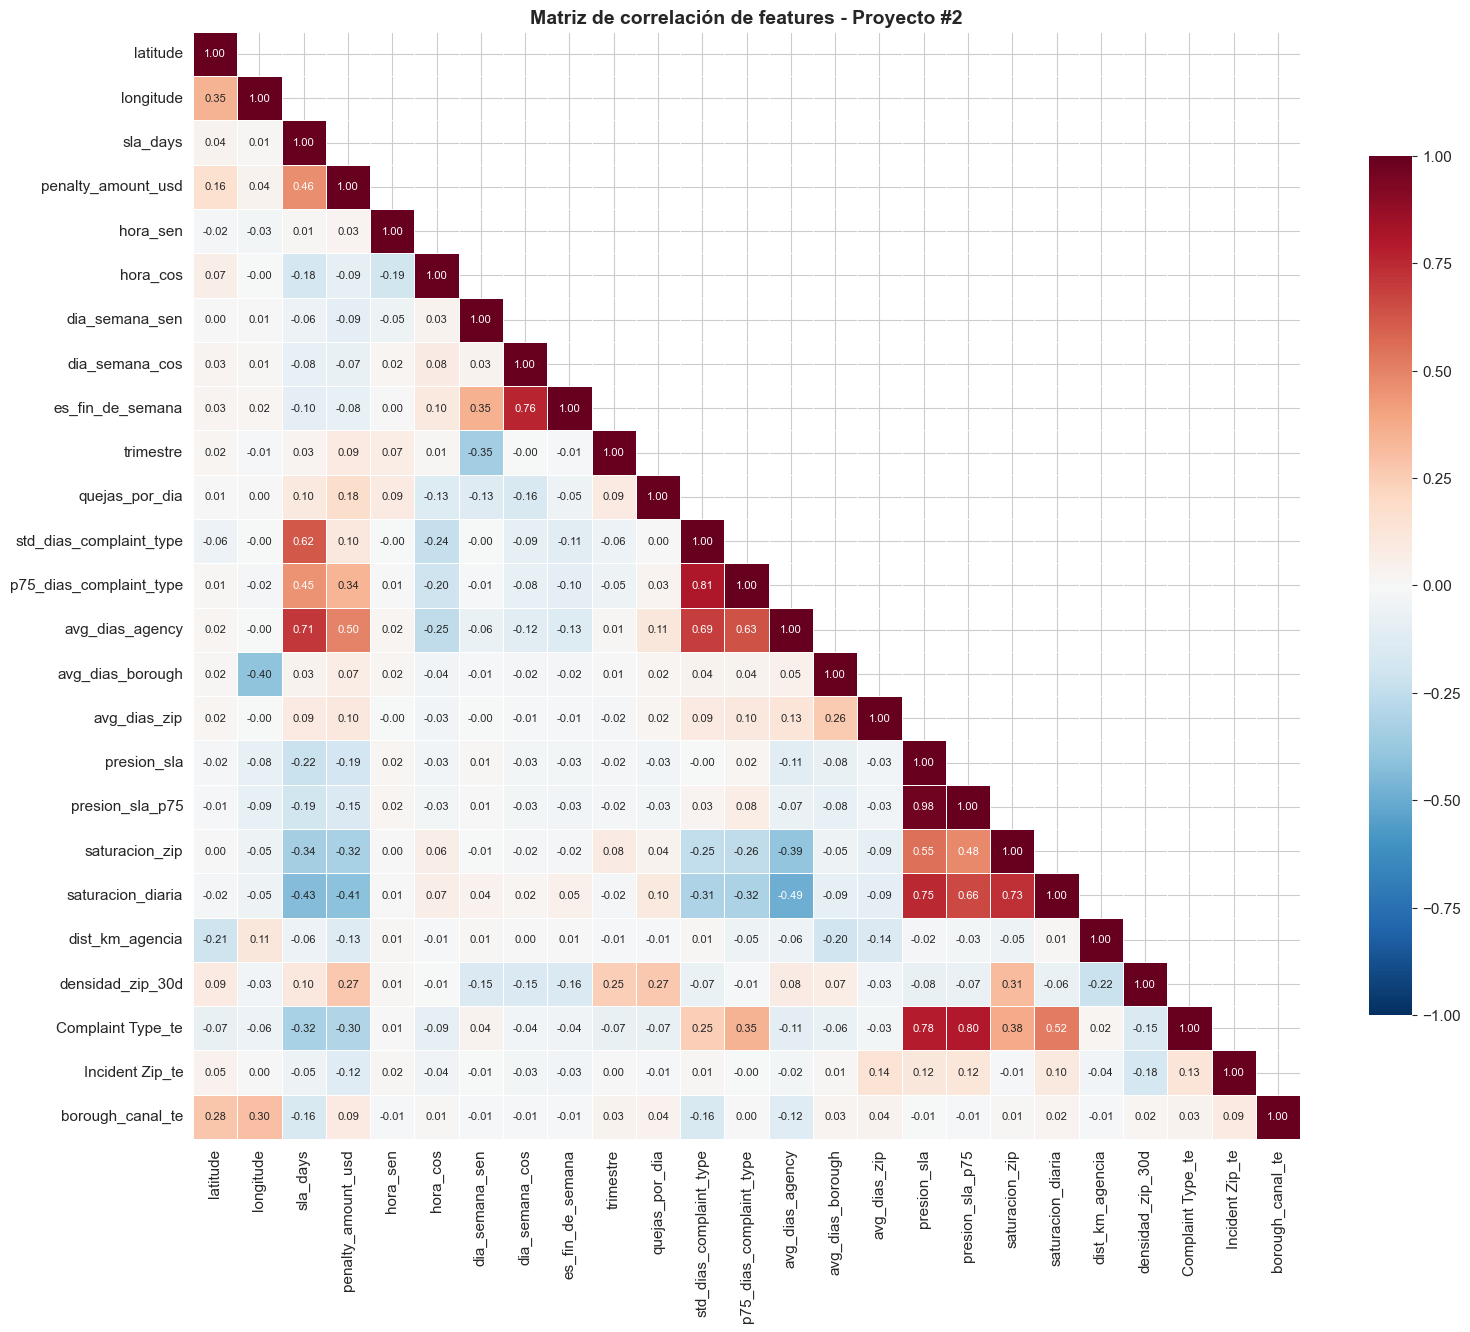


PARES DE FEATURES CON ALTA CORRELACIÓN (|r| > 0.7)

Se detectaron 8 pares con |r| > 0.7:

              Feature 1               Feature 2  Correlación
            presion_sla         presion_sla_p75        0.976
std_dias_complaint_type p75_dias_complaint_type        0.808
        presion_sla_p75       Complaint Type_te        0.802
            presion_sla       Complaint Type_te        0.784
         dia_semana_cos        es_fin_de_semana        0.759
            presion_sla       saturacion_diaria        0.753
         saturacion_zip       saturacion_diaria        0.732
               sla_days         avg_dias_agency        0.709

CORRELACIONES DE LAS 4 FEATURES NUEVAS

  presion_sla:
     vs presion_sla_p75                     → r = +0.976
      vs Complaint Type_te                   → r = +0.784
      vs saturacion_diaria                   → r = +0.753

  presion_sla_p75:
     vs presion_sla                         → r = +0.976
      vs Complaint Type_te                   → r = +0.

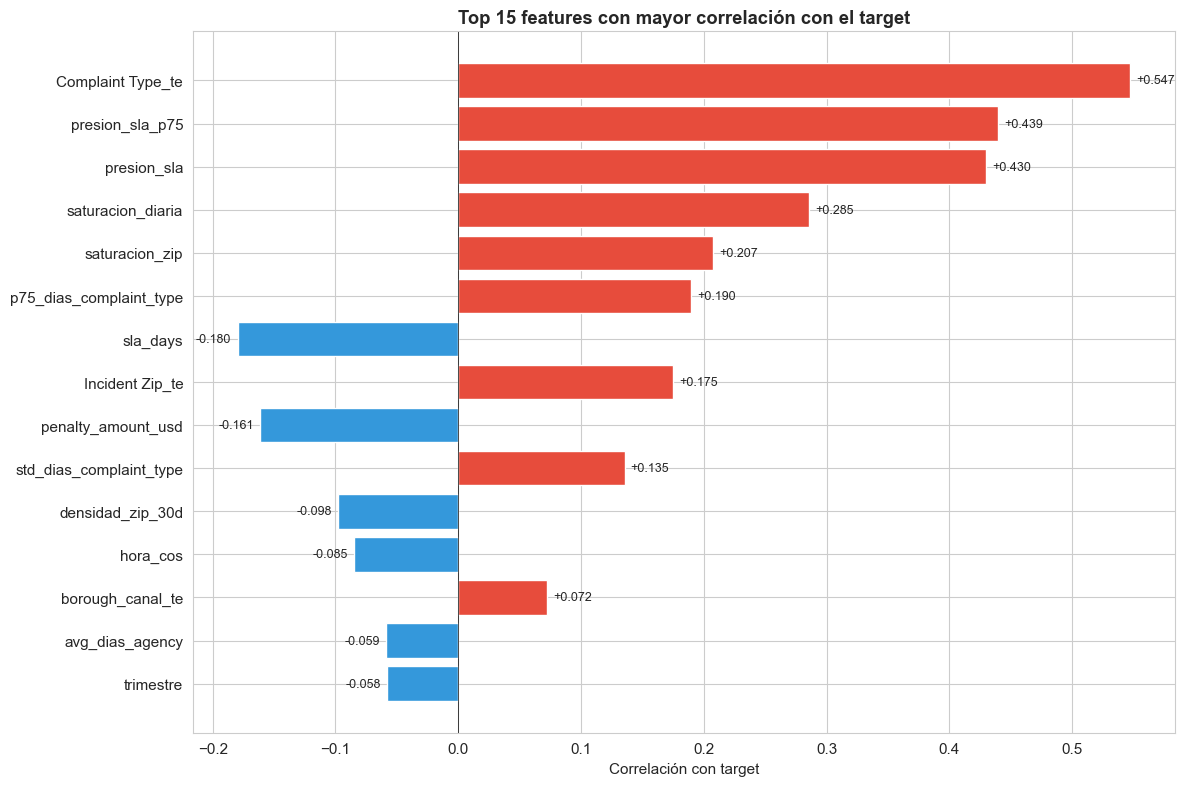


Posición de las features NUEVAS en el ranking de correlación con target:

   presion_sla               → r = +0.4295 (rank #3)
   presion_sla_p75           → r = +0.4395 (rank #2)
   saturacion_zip            → r = +0.2074 (rank #5)
   saturacion_diaria         → r = +0.2853 (rank #4)


In [20]:
# Análisis de correlación

print("=" * 70)
print("ANÁLISIS DE CORRELACIÓN ENTRE FEATURES")
print("=" * 70)

# Calcular matriz de correlación sobre features numéricas
# Excluimos _idx por no ser ordinales reales
features_correlacion = [f for f in FEATURES if not f.endswith('_idx')]
corr_matrix = X_train[features_correlacion].corr()

# Visualización
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7},
            annot_kws={'fontsize': 8}, ax=ax)
ax.set_title('Matriz de correlación de features - Proyecto #2',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Detectar pares con alta correlación
print("\n" + "=" * 70)
print("PARES DE FEATURES CON ALTA CORRELACIÓN (|r| > 0.7)")
print("=" * 70)

pares_correlados = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            pares_correlados.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlación': round(r, 3),
            })

if pares_correlados:
    df_pares = pd.DataFrame(pares_correlados).sort_values('Correlación', key=abs, ascending=False)
    print(f"\nSe detectaron {len(pares_correlados)} pares con |r| > 0.7:\n")
    print(df_pares.to_string(index=False))
else:
    print("\n  No hay correlaciones extremas. Features razonablemente independientes.")

# --- Foco en las features nuevas ---
print("\n" + "=" * 70)
print("CORRELACIONES DE LAS 4 FEATURES NUEVAS")
print("=" * 70)

features_nuevas = ['presion_sla', 'presion_sla_p75', 'saturacion_zip', 'saturacion_diaria']

for f_nueva in features_nuevas:
    correlaciones = corr_matrix[f_nueva].drop(f_nueva).sort_values(key=abs, ascending=False)
    top3 = correlaciones.head(3)
    print(f"\n  {f_nueva}:")
    for f, r in top3.items():
        flag = " " if abs(r) > 0.9 else "  "
        print(f"    {flag}vs {f:<35} → r = {r:+.3f}")

# --- Correlación con el target ---
print("\n" + "=" * 70)
print("CORRELACIÓN DE CADA FEATURE CON EL TARGET")
print("=" * 70)

corr_target = X_train[features_correlacion].apply(lambda x: x.corr(y_train)).sort_values(key=abs, ascending=False)

# Top 15
top15 = corr_target.head(15)
print(f"\nTop 15 features más correlacionadas con target (incumplimiento):\n")
print(top15.to_frame('Correlación').round(4).to_string())

# Visualizar
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in top15.values]
ax.barh(range(len(top15)), top15.values, color=colors)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index)
ax.invert_yaxis()
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Correlación con target')
ax.set_title('Top 15 features con mayor correlación con el target',
             fontweight='bold')
for i, v in enumerate(top15.values):
    ax.text(v + 0.005 if v > 0 else v - 0.005, i, f'{v:+.3f}',
            va='center', ha='left' if v > 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

# Resaltar las nuevas features
print("\nPosición de las features NUEVAS en el ranking de correlación con target:\n")
for f_nueva in features_nuevas:
    if f_nueva in corr_target.index:
        rank = (corr_target.abs() >= abs(corr_target[f_nueva])).sum()
        print(f"   {f_nueva:<25} → r = {corr_target[f_nueva]:+.4f} (rank #{rank})")

In [21]:
# Eliminación de features redundantes


print("=" * 70)
print("ELIMINACIÓN DE FEATURES REDUNDANTES")
print("=" * 70)

features_a_eliminar = ['presion_sla', 'dia_semana_cos']

print(f"\nFeatures a eliminar ({len(features_a_eliminar)}):")
for f in features_a_eliminar:
    print(f"   {f}")
    if f == 'presion_sla':
        print(f"      Razón: r=0.976 con presion_sla_p75; XGBoost prefiere p75 (37% vs 4%)")
    elif f == 'dia_semana_cos':
        print(f"      Razón: r=0.759 con es_fin_de_semana, que es más interpretable")

# Lista final de features
FEATURES_V2 = [f for f in FEATURES if f not in features_a_eliminar]

print(f"\nFeatures finales: {len(FEATURES_V2)} (antes: {len(FEATURES)})")

# Actualizar X para todos los splits
X_train_v2 = df_train[FEATURES_V2].copy()
X_val_v2   = df_val[FEATURES_V2].copy()
X_test_v2  = df_test[FEATURES_V2].copy()

# También actualizar X_lr (regresión logística usa OHE)
# Como dia_semana_cos no está en X_lr de forma directa (se mantuvo en numéricas),
# debemos regenerar X_lr eliminando esas features numéricas
FEATURES_NUMERICAS_LR_V2 = [f for f in FEATURES_NUMERICAS_LR if f not in features_a_eliminar]

X_train_lr_v2 = construir_X_logistico(df_train, FEATURES_NUMERICAS_LR_V2, COLS_CATEGORICAS_OHE)
X_val_lr_v2   = construir_X_logistico(df_val,   FEATURES_NUMERICAS_LR_V2, COLS_CATEGORICAS_OHE)
X_test_lr_v2  = construir_X_logistico(df_test,  FEATURES_NUMERICAS_LR_V2, COLS_CATEGORICAS_OHE)

# Reindexar
cols_train_lr_v2 = X_train_lr_v2.columns
X_val_lr_v2  = X_val_lr_v2.reindex(columns=cols_train_lr_v2, fill_value=0)
X_test_lr_v2 = X_test_lr_v2.reindex(columns=cols_train_lr_v2, fill_value=0)

# Re-escalar
scaler_lr_v2 = StandardScaler()
X_train_lr_scaled_v2 = scaler_lr_v2.fit_transform(X_train_lr_v2)
X_val_lr_scaled_v2   = scaler_lr_v2.transform(X_val_lr_v2)
X_test_lr_scaled_v2  = scaler_lr_v2.transform(X_test_lr_v2)

print(f"\nDimensiones:")
print(f"   X_train_v2 (árboles): {X_train_v2.shape}")
print(f"   X_train_lr_v2 (LR):   {X_train_lr_v2.shape}")

ELIMINACIÓN DE FEATURES REDUNDANTES

Features a eliminar (2):
   presion_sla
      Razón: r=0.976 con presion_sla_p75; XGBoost prefiere p75 (37% vs 4%)
   dia_semana_cos
      Razón: r=0.759 con es_fin_de_semana, que es más interpretable

Features finales: 28 (antes: 30)

Dimensiones:
   X_train_v2 (árboles): (121025, 28)
   X_train_lr_v2 (LR):   (121025, 123)


In [22]:
# Validación rápida del podado

print("=" * 70)
print("VALIDACIÓN: 3 finalistas con FEATURES_V2 (28 features)")
print("=" * 70)

resultados_v2 = {}

# 1. RF + class_weight con features podadas
print("\nRF + class_weight con 28 features...")
t0 = time.time()
rf_v2 = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=20,
    class_weight='balanced', n_jobs=-1, random_state=SEED
)
rf_v2.fit(X_train_v2, y_train)
print(f"   {time.time()-t0:.2f}s")
y_pred = rf_v2.predict(X_val_v2)
y_proba = rf_v2.predict_proba(X_val_v2)[:, 1]
resultados_v2['RF + cw (v2)'] = {
    'PR-AUC': average_precision_score(y_val, y_proba),
    'ROC-AUC': roc_auc_score(y_val, y_proba),
    'F1': f1_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred),
}

# 2. XGBoost + scale_pos_weight con features podadas
print("\nXGBoost + scale_pos_weight con 28 features...")
t0 = time.time()
xgb_v2 = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=SEED, n_jobs=-1,
    eval_metric='aucpr', tree_method='hist'
)
xgb_v2.fit(X_train_v2, y_train)
print(f"   {time.time()-t0:.2f}s")
y_pred = xgb_v2.predict(X_val_v2)
y_proba = xgb_v2.predict_proba(X_val_v2)[:, 1]
resultados_v2['XGB + spw (v2)'] = {
    'PR-AUC': average_precision_score(y_val, y_proba),
    'ROC-AUC': roc_auc_score(y_val, y_proba),
    'F1': f1_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred),
}

# 3. XGBoost sin balanceo con features podadas (modelo de control)
print("\nXGBoost sin balanceo con 28 features...")
t0 = time.time()
xgb_nb_v2 = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, n_jobs=-1,
    eval_metric='aucpr', tree_method='hist'
)
xgb_nb_v2.fit(X_train_v2, y_train)
print(f"   {time.time()-t0:.2f}s")
y_pred = xgb_nb_v2.predict(X_val_v2)
y_proba = xgb_nb_v2.predict_proba(X_val_v2)[:, 1]
resultados_v2['XGB sin bal. (v2)'] = {
    'PR-AUC': average_precision_score(y_val, y_proba),
    'ROC-AUC': roc_auc_score(y_val, y_proba),
    'F1': f1_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred),
}

# --- Comparación ANTES vs DESPUÉS del podado ---
print("\n" + "=" * 70)
print("COMPARACIÓN: 30 features (original) vs 28 features (podadas)")
print("=" * 70)

df_comparacion = pd.DataFrame({
    'RF + cw (30 feat)':    {k: resultados_rf['RF + class_weight=balanced'][k]
                              for k in ['PR-AUC','ROC-AUC','F1','Recall','Precision']},
    'RF + cw (28 feat)':    resultados_v2['RF + cw (v2)'],
    'XGB + spw (30 feat)':  {k: resultados_xgb['XGBoost + scale_pos_weight'][k]
                              for k in ['PR-AUC','ROC-AUC','F1','Recall','Precision']},
    'XGB + spw (28 feat)':  resultados_v2['XGB + spw (v2)'],
    'XGB sin bal. (30 feat)': {k: resultados_xgb['XGBoost sin balanceo'][k]
                                for k in ['PR-AUC','ROC-AUC','F1','Recall','Precision']},
    'XGB sin bal. (28 feat)': resultados_v2['XGB sin bal. (v2)'],
}).T.round(4)
print("\n", df_comparacion.to_string())

# Diagnóstico
print("\n" + "=" * 70)
print("DIAGNÓSTICO")
print("=" * 70)

for base_key, v2_key in [
    ('RF + cw (30 feat)', 'RF + cw (28 feat)'),
    ('XGB + spw (30 feat)', 'XGB + spw (28 feat)'),
    ('XGB sin bal. (30 feat)', 'XGB sin bal. (28 feat)'),
]:
    pr_base = df_comparacion.loc[base_key, 'PR-AUC']
    pr_v2 = df_comparacion.loc[v2_key, 'PR-AUC']
    diff = pr_v2 - pr_base
    icono = "" if diff >= -0.005 else " "
    print(f"  {icono} {base_key.split(' (')[0]}: {pr_base:.4f} → {pr_v2:.4f} ({diff:+.4f})")

# El modelo final es rf_v2 (RF base con 28 features).
MEJOR_MODELO = rf_v2
MODELO_FINAL = MEJOR_MODELO

print(f"\n" + "=" * 70)
print(f"MODELO FINAL ASIGNADO")
print(f"=" * 70)
print(f"   MEJOR_MODELO = rf_v2 (RF + class_weight, sin tuning)")
print(f"   MODELO_FINAL = MEJOR_MODELO (sin calibrar)")


VALIDACIÓN: 3 finalistas con FEATURES_V2 (28 features)

RF + class_weight con 28 features...
   33.38s

XGBoost + scale_pos_weight con 28 features...
   16.39s

XGBoost sin balanceo con 28 features...
   13.23s

COMPARACIÓN: 30 features (original) vs 28 features (podadas)

                         PR-AUC  ROC-AUC      F1  Recall  Precision
RF + cw (30 feat)       0.5647   0.8660  0.5134  0.7572     0.3884
RF + cw (28 feat)       0.5849   0.8677  0.5122  0.7537     0.3879
XGB + spw (30 feat)     0.5615   0.8676  0.5120  0.7594     0.3862
XGB + spw (28 feat)     0.5675   0.8682  0.5073  0.7487     0.3836
XGB sin bal. (30 feat)  0.5486   0.8673  0.5293  0.5051     0.5560
XGB sin bal. (28 feat)  0.5546   0.8669  0.5301  0.4984     0.5661

DIAGNÓSTICO
   RF + cw: 0.5647 → 0.5849 (+0.0202)
   XGB + spw: 0.5615 → 0.5675 (+0.0060)
   XGB sin bal.: 0.5486 → 0.5546 (+0.0060)

MODELO FINAL ASIGNADO
   MEJOR_MODELO = rf_v2 (RF + class_weight, sin tuning)
   MODELO_FINAL = MEJOR_MODELO (sin calibra

In [23]:
#  Selección de los 3 finalistas

print("=" * 90)
print("SELECCIÓN DE MODELOS FINALISTAS PARA HYPERPARAMETER TUNING")
print("=" * 90)

finalistas = {
    'RF + class_weight (mejor PR-AUC)':       resultados_v2['RF + cw (v2)'],
    'XGBoost + scale_pos_weight (más rápido)': resultados_v2['XGB + spw (v2)'],
    'XGBoost sin balanceo (control)':          resultados_v2['XGB sin bal. (v2)'],
}
df_finalistas = pd.DataFrame(finalistas).T.round(4)
print(df_finalistas.to_string())

SELECCIÓN DE MODELOS FINALISTAS PARA HYPERPARAMETER TUNING
                                         PR-AUC  ROC-AUC      F1  Recall  Precision
RF + class_weight (mejor PR-AUC)         0.5849   0.8677  0.5122  0.7537     0.3879
XGBoost + scale_pos_weight (más rápido)  0.5675   0.8682  0.5073  0.7487     0.3836
XGBoost sin balanceo (control)           0.5546   0.8669  0.5301  0.4984     0.5661


In [24]:
#Tuning con CV temporal

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

print("=" * 70)
print("HYPERPARAMETER TUNING CON CV TEMPORAL (Opción C)")
print("=" * 70)
print("""
Estrategia:
  - CV: TimeSeriesSplit (5 folds cronológicos)
  - Cada fold valida sobre datos MÁS RECIENTES que los de entrenamiento
  - Esto simula el escenario real: train pasado → predecir futuro
  - Métrica: PR-AUC (average_precision)
  - Iteraciones: 20 para RF (lento), 30 para XGBoost
""")

# Configurar TimeSeriesSplit
# n_splits=5 → train crece progresivamente, val siempre es ~20% del split actual
cv_temporal = TimeSeriesSplit(n_splits=5)

# Visualizar cómo se ven los folds
print("Estructura de los folds temporales:")
n_train_total = len(X_train_v2)
for i, (train_idx, val_idx) in enumerate(cv_temporal.split(X_train_v2)):
    pct_train = 100 * len(train_idx) / n_train_total
    pct_val   = 100 * len(val_idx) / n_train_total
    print(f"   Fold {i+1}: train={len(train_idx):>7,} ({pct_train:.1f}%) | "
          f"val={len(val_idx):>6,} ({pct_val:.1f}%) | "
          f"indices train={train_idx.min()}-{train_idx.max()}, "
          f"val={val_idx.min()}-{val_idx.max()}")

resultados_tuning_c = {}

# ─────────────────────────────────────────────────────────────
# 1. TUNING DE RF + class_weight con CV temporal
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("1. RANDOM FOREST + class_weight - Tuning con CV temporal")
print("=" * 70)

rf_param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [10, 15, 20, 25],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [5, 10, 20, 30],
    'max_features':      ['sqrt', 'log2', 0.5],
    'bootstrap':         [True],
}

t0 = time.time()
rf_search_c = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced',
                                      n_jobs=-1, random_state=SEED),
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring='average_precision',
    cv=cv_temporal,                 
    verbose=1,
    n_jobs=1,
    random_state=SEED,
    return_train_score=True,
)
rf_search_c.fit(X_train_v2, y_train)
print(f"\nTiempo: {(time.time()-t0)/60:.1f} min")
print(f"Mejor PR-AUC en CV temporal: {rf_search_c.best_score_:.4f}")
print(f"Hiperparámetros óptimos:")
for k, v in rf_search_c.best_params_.items():
    print(f"      • {k}: {v}")

y_pred_t = rf_search_c.best_estimator_.predict(X_val_v2)
y_proba_t = rf_search_c.best_estimator_.predict_proba(X_val_v2)[:, 1]
resultados_tuning_c['RF tuneado (CV temporal)'] = {
    'PR-AUC val':     average_precision_score(y_val, y_proba_t),
    'PR-AUC CV temp.': rf_search_c.best_score_,
    'ROC-AUC val':    roc_auc_score(y_val, y_proba_t),
    'F1 val':         f1_score(y_val, y_pred_t),
    'Recall val':     recall_score(y_val, y_pred_t),
    'Precision val':  precision_score(y_val, y_pred_t),
    'Best params':    rf_search_c.best_params_,
    'Best estimator': rf_search_c.best_estimator_,
}

# ─────────────────────────────────────────────────────────────
# 2. TUNING DE XGBOOST + scale_pos_weight con CV temporal
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("2. XGBOOST + scale_pos_weight - Tuning con CV temporal")
print("=" * 70)

xgb_param_grid = {
    'n_estimators':     [200, 300, 500, 700],
    'max_depth':        [4, 6, 8, 10, 12],
    'learning_rate':    [0.01, 0.03, 0.05, 0.1, 0.15],
    'subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7, 10],
    'gamma':            [0, 0.1, 0.3, 0.5],
    'reg_alpha':        [0, 0.1, 0.5, 1.0],
    'reg_lambda':       [0.1, 1.0, 5.0, 10.0],
}

t0 = time.time()
xgb_search_c = RandomizedSearchCV(
    estimator=XGBClassifier(scale_pos_weight=scale_pos_weight,
                             random_state=SEED, n_jobs=-1,
                             eval_metric='aucpr', tree_method='hist'),
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='average_precision',
    cv=cv_temporal,                 
    verbose=1,
    n_jobs=1,
    random_state=SEED,
    return_train_score=True,
)
xgb_search_c.fit(X_train_v2, y_train)
print(f"\nTiempo: {(time.time()-t0)/60:.1f} min")
print(f"Mejor PR-AUC en CV temporal: {xgb_search_c.best_score_:.4f}")
print(f"Hiperparámetros óptimos:")
for k, v in xgb_search_c.best_params_.items():
    print(f"      • {k}: {v}")

y_pred_t = xgb_search_c.best_estimator_.predict(X_val_v2)
y_proba_t = xgb_search_c.best_estimator_.predict_proba(X_val_v2)[:, 1]
resultados_tuning_c['XGB+spw tuneado (CV temporal)'] = {
    'PR-AUC val':     average_precision_score(y_val, y_proba_t),
    'PR-AUC CV temp.': xgb_search_c.best_score_,
    'ROC-AUC val':    roc_auc_score(y_val, y_proba_t),
    'F1 val':         f1_score(y_val, y_pred_t),
    'Recall val':     recall_score(y_val, y_pred_t),
    'Precision val':  precision_score(y_val, y_pred_t),
    'Best params':    xgb_search_c.best_params_,
    'Best estimator': xgb_search_c.best_estimator_,
}

# ─────────────────────────────────────────────────────────────
# 3. TUNING DE XGBOOST sin balanceo con CV temporal
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("3.  XGBOOST sin balanceo - Tuning con CV temporal")
print("=" * 70)

t0 = time.time()
xgb_nb_search_c = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=SEED, n_jobs=-1,
                             eval_metric='aucpr', tree_method='hist'),
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='average_precision',
    cv=cv_temporal,                 
    verbose=1,
    n_jobs=1,
    random_state=SEED,
    return_train_score=True,
)
xgb_nb_search_c.fit(X_train_v2, y_train)
print(f"\nTiempo: {(time.time()-t0)/60:.1f} min")
print(f"Mejor PR-AUC en CV temporal: {xgb_nb_search_c.best_score_:.4f}")
print(f"Hiperparámetros óptimos:")
for k, v in xgb_nb_search_c.best_params_.items():
    print(f"      • {k}: {v}")

y_pred_t = xgb_nb_search_c.best_estimator_.predict(X_val_v2)
y_proba_t = xgb_nb_search_c.best_estimator_.predict_proba(X_val_v2)[:, 1]
resultados_tuning_c['XGB sin balanceo tuneado (CV temporal)'] = {
    'PR-AUC val':     average_precision_score(y_val, y_proba_t),
    'PR-AUC CV temp.': xgb_nb_search_c.best_score_,
    'ROC-AUC val':    roc_auc_score(y_val, y_proba_t),
    'F1 val':         f1_score(y_val, y_pred_t),
    'Recall val':     recall_score(y_val, y_pred_t),
    'Precision val':  precision_score(y_val, y_pred_t),
    'Best params':    xgb_nb_search_c.best_params_,
    'Best estimator': xgb_nb_search_c.best_estimator_,
}

HYPERPARAMETER TUNING CON CV TEMPORAL (Opción C)

Estrategia:
  - CV: TimeSeriesSplit (5 folds cronológicos)
  - Cada fold valida sobre datos MÁS RECIENTES que los de entrenamiento
  - Esto simula el escenario real: train pasado → predecir futuro
  - Métrica: PR-AUC (average_precision)
  - Iteraciones: 20 para RF (lento), 30 para XGBoost

Estructura de los folds temporales:
   Fold 1: train= 20,175 (16.7%) | val=20,170 (16.7%) | indices train=0-20174, val=20175-40344
   Fold 2: train= 40,345 (33.3%) | val=20,170 (16.7%) | indices train=0-40344, val=40345-60514
   Fold 3: train= 60,515 (50.0%) | val=20,170 (16.7%) | indices train=0-60514, val=60515-80684
   Fold 4: train= 80,685 (66.7%) | val=20,170 (16.7%) | indices train=0-80684, val=80685-100854
   Fold 5: train=100,855 (83.3%) | val=20,170 (16.7%) | indices train=0-100854, val=100855-121024

1. RANDOM FOREST + class_weight - Tuning con CV temporal
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Tiempo: 30.8 min
Mejor 

In [25]:
#Resumen del tuning temporal

print("=" * 90)
print("RESUMEN DEL TUNING CON CV TEMPORAL (Opción C)")
print("=" * 90)

# Tabla: base vs tuneado_temporal
def filtrar_metricas(d):
    """Mantiene solo métricas (saca Best params y estimator)."""
    return {k: v for k, v in d.items() 
            if k not in ['Best params', 'Best estimator']}

tabla = {
    # RF
    'RF base':                resultados_v2['RF + cw (v2)'],
    'RF tuneado (CV temp.)':  filtrar_metricas(resultados_tuning_c['RF tuneado (CV temporal)']),
    # XGB+spw
    'XGB+spw base':                  resultados_v2['XGB + spw (v2)'],
    'XGB+spw tuneado (CV temp.)':    filtrar_metricas(resultados_tuning_c['XGB+spw tuneado (CV temporal)']),
    # XGB sin bal.
    'XGB nb base':                    resultados_v2['XGB sin bal. (v2)'],
    'XGB nb tuneado (CV temp.)':      filtrar_metricas(resultados_tuning_c['XGB sin balanceo tuneado (CV temporal)']),
}

# Normalizar nombres
def normalizar(d):
    rename = {'PR-AUC': 'PR-AUC val', 'ROC-AUC': 'ROC-AUC val', 'F1': 'F1 val',
              'Recall': 'Recall val', 'Precision': 'Precision val'}
    return {rename.get(k, k): v for k, v in d.items()}

tabla_norm = {k: normalizar(v) for k, v in tabla.items()}
df_comp = pd.DataFrame(tabla_norm).T.round(4)

# Mostrar solo las columnas más relevantes
cols_mostrar = ['PR-AUC val', 'ROC-AUC val', 'F1 val', 'Recall val', 'Precision val',
                'PR-AUC CV temp.']
cols_disponibles = [c for c in cols_mostrar if c in df_comp.columns]
print("\n", df_comp[cols_disponibles].to_string())

# Comparativa: ¿el tuning con CV temporal mejoró o empeoró el modelo base?
print("\n" + "=" * 90)
print("¿El tuning con CV temporal mejoró el modelo base?")
print("=" * 90)

for familia, base, cv_temp in [
    ('RF',           'RF + cw (v2)',         'RF tuneado (CV temporal)'),
    ('XGB+spw',      'XGB + spw (v2)',       'XGB+spw tuneado (CV temporal)'),
    ('XGB sin bal.', 'XGB sin bal. (v2)',    'XGB sin balanceo tuneado (CV temporal)'),
]:
    pr_base   = resultados_v2[base]['PR-AUC']
    pr_temp   = resultados_tuning_c[cv_temp]['PR-AUC val']
    
    cual_gano = 'base' if pr_base >= pr_temp else 'CV temporal'
    
    print(f"\n  {familia}:")
    print(f"    Base (sin tuning):     PR-AUC val = {pr_base:.4f}")
    print(f"    Tuneado CV temporal:   PR-AUC val = {pr_temp:.4f}  (Δ {pr_temp-pr_base:+.4f})")
    print(f"    GANADOR: {cual_gano}")

# Ranking global de candidatos (base vs tuneados CV temporal)
print("\n" + "=" * 90)
print("RANKING GLOBAL DE CANDIDATOS")
print("=" * 90)

todos_candidatos = {
    'RF base':                  resultados_v2['RF + cw (v2)']['PR-AUC'],
    'RF tuneado CV temp.':      resultados_tuning_c['RF tuneado (CV temporal)']['PR-AUC val'],
    'XGB+spw base':             resultados_v2['XGB + spw (v2)']['PR-AUC'],
    'XGB+spw tuneado CV temp.': resultados_tuning_c['XGB+spw tuneado (CV temporal)']['PR-AUC val'],
    'XGB nb base':              resultados_v2['XGB sin bal. (v2)']['PR-AUC'],
    'XGB nb tuneado CV temp.':  resultados_tuning_c['XGB sin balanceo tuneado (CV temporal)']['PR-AUC val'],
}

mejor_nombre = max(todos_candidatos, key=todos_candidatos.get)
mejor_pr_auc = todos_candidatos[mejor_nombre]

print(f"\nRanking por PR-AUC en val:\n")
for i, (nombre, pr) in enumerate(sorted(todos_candidatos.items(), key=lambda x: -x[1]), 1):
    medalla = ['1.', '2.', '3.'][i-1] if i <= 3 else f' {i}.'
    print(f"  {medalla} {nombre:<35} PR-AUC = {pr:.4f}")


RESUMEN DEL TUNING CON CV TEMPORAL (Opción C)

                             PR-AUC val  ROC-AUC val  F1 val  Recall val  Precision val  PR-AUC CV temp.
RF base                         0.5849       0.8677  0.5122      0.7537         0.3879              NaN
RF tuneado (CV temp.)           0.5797       0.8666  0.5273      0.6507         0.4432           0.7412
XGB+spw base                    0.5675       0.8682  0.5073      0.7487         0.3836              NaN
XGB+spw tuneado (CV temp.)      0.5375       0.8683  0.5157      0.7195         0.4019           0.7480
XGB nb base                     0.5546       0.8669  0.5301      0.4984         0.5661              NaN
XGB nb tuneado (CV temp.)       0.5341       0.8671  0.5329      0.4976         0.5736           0.7468

¿El tuning con CV temporal mejoró el modelo base?

  RF:
    Base (sin tuning):     PR-AUC val = 0.5849
    Tuneado CV temporal:   PR-AUC val = 0.5797  (Δ -0.0052)
    GANADOR: base

  XGB+spw:
    Base (sin tuning):     PR

OPTIMIZACIÓN DE THRESHOLD CON RESTRICCIÓN OPERATIVA

Multa promedio por incumplimiento en val: $71,157
Supuestos económicos:
   Costo Falso Positivo (revisar queja extra):    $500
   Costo Falso Negativo (perder incumplimiento):  $71,157
   Razón FN:FP = 142:1

RECALL Y MÉTRICAS POR PRESUPUESTO OPERATIVO

   Presupuesto |  Threshold | % alertas real |   Recall |  Precision |     F1 |       Pérdida |     FP
  --------------------------------------------------------------------------------------------------------------
  ≤ 10%        |       0.78 |           9.7% |  0.4151 |    0.6484 | 0.5062 | $155,477,518 |    841
  ≤ 15%        |       0.70 |          14.4% |  0.5070 |    0.5334 | 0.5198 | $131,070,750 |  1,657
  ≤ 20%        |       0.63 |          20.0% |  0.6006 |    0.4564 | 0.5187 | $106,165,884 |  2,673
  ≤ 25%        |       0.57 |          24.5% |  0.6777 |    0.4209 | 0.5193 | $ 85,672,738 |  3,484
  ≤ 30%        |       0.50 |          29.5% |  0.7537 |    0.3879 | 0.5122 |

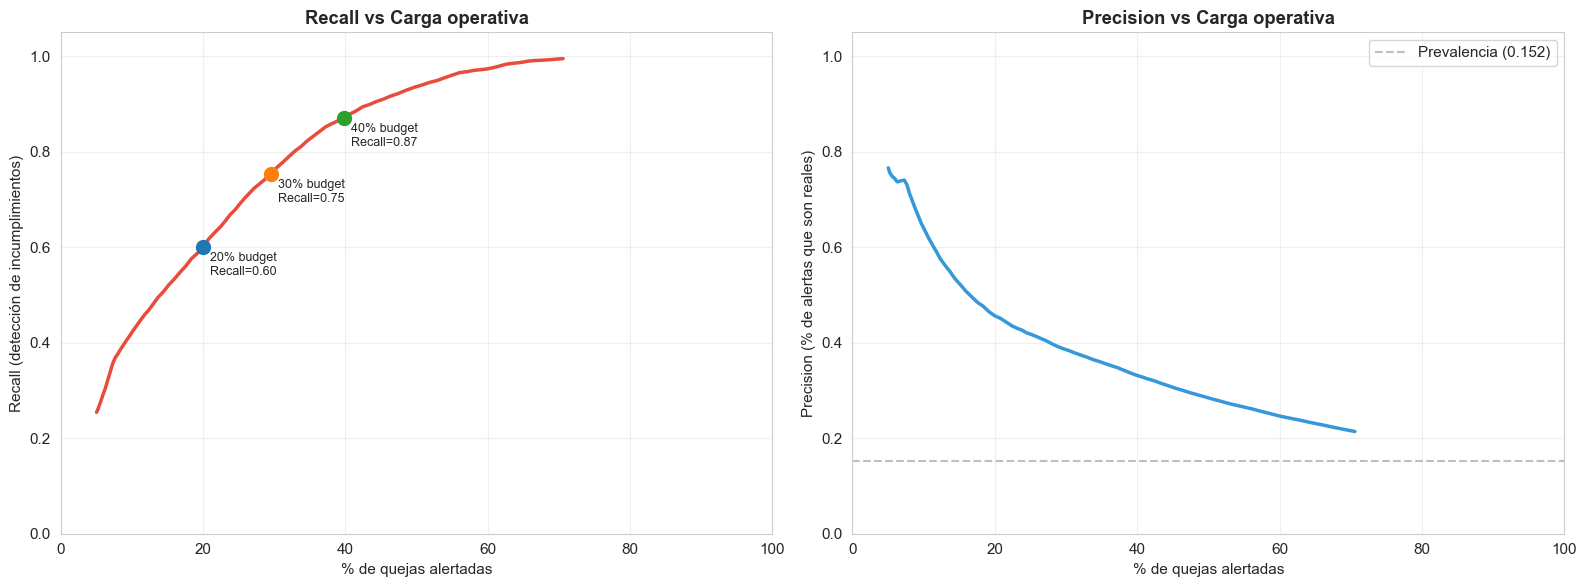


Recomendación: Seleccionar threshold con presupuesto <=30%

   THRESHOLD FINAL: 0.50
   PRESUPUESTO: 30% de quejas alertadas

   Métricas en val:
     - % de alertas reales:  29.5% (cerca del límite del presupuesto)
     - Recall:               0.7537  (75.4% de incumplimientos detectados)
     - Precision:            0.3879  (38.8% de alertas son reales)
     - F1:                   0.5122

   Impacto fiscal:
     - TP (detectados):       2,816
     - FN (perdidos):         920
     - FP (alertas extras):   4,444
     - Pérdida fiscal:        $65,464,218
     - Ahorro vs baseline:    $200,377,433
     - % de exposición fiscal evitada: 75.4%

JUSTIFICACIÓN PARA LA CONTRALORÍA:
─────────────────────────────────
   "Asumiendo que las agencias pueden revisar al máximo el 30% de las
    quejas como prioritarias, este modelo detecta el 75% de los
    incumplimientos reales. De cada 100 alertas, 39 son
    incumplimientos verdaderos. Esto evita $200M de exposición
    fiscal en el periodo e

In [26]:
#Threshold con restricción operativa
# Optimizamos el threshold sujeto a un "presupuesto operativo":
# alertar como máximo X% de quejas, maximizando recall dentro de ese límite.
# Este enfoque es defendible ante la Contraloría porque incorpora la
# realidad operativa (no se pueden revisar todas las quejas).

print("=" * 70)
print("OPTIMIZACIÓN DE THRESHOLD CON RESTRICCIÓN OPERATIVA")
print("=" * 70)

# ─────────────────────────────────────────────────────────────
# Preparación: calcular probabilidades y costos
# ─────────────────────────────────────────────────────────────
y_proba_val = MEJOR_MODELO.predict_proba(X_val_v2)[:, 1]
multa_promedio_val = df_val.loc[df_val['target']==1, 'penalty_charged'].mean()
COSTO_FP = 500                     # costo operativo de revisar una queja extra
COSTO_FN = multa_promedio_val      # multa promedio por incumplimiento perdido

print(f"\nMulta promedio por incumplimiento en val: ${multa_promedio_val:,.0f}")
print(f"Supuestos económicos:")
print(f"   Costo Falso Positivo (revisar queja extra):    ${COSTO_FP}")
print(f"   Costo Falso Negativo (perder incumplimiento):  ${COSTO_FN:,.0f}")
print(f"   Razón FN:FP = {COSTO_FN/COSTO_FP:.0f}:1")

# ─────────────────────────────────────────────────────────────
# Barrido de thresholds
# ─────────────────────────────────────────────────────────────
thresholds = np.arange(0.05, 0.95, 0.01)
metricas_por_t = []

for t in thresholds:
    y_pred_t = (y_proba_val >= t).astype(int)
    cm = confusion_matrix(y_val, y_pred_t)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        continue
    if y_pred_t.sum() == 0:
        continue
    metricas_por_t.append({
        'threshold': t,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision':   precision_score(y_val, y_pred_t, zero_division=0),
        'recall':      recall_score(y_val, y_pred_t, zero_division=0),
        'f1':          f1_score(y_val, y_pred_t, zero_division=0),
        'accuracy':    accuracy_score(y_val, y_pred_t),
        'costo_fn':    fn * COSTO_FN,
        'costo_fp':    fp * COSTO_FP,
        'costo_total': fn * COSTO_FN + fp * COSTO_FP,
    })

df_t = pd.DataFrame(metricas_por_t)
df_t['pct_alertas'] = (df_t['tp'] + df_t['fp']) / len(y_val) * 100

# ─────────────────────────────────────────────────────────────
# Explorar varios presupuestos operativos
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 90)
print("RECALL Y MÉTRICAS POR PRESUPUESTO OPERATIVO")
print("=" * 90)
print(f"\n  {'Presupuesto':>12} | {'Threshold':>10} | {'% alertas real':>14} | "
      f"{'Recall':>8} | {'Precision':>10} | {'F1':>6} | {'Pérdida':>13} | {'FP':>6}")
print("  " + "-" * 110)

presupuestos = [10, 15, 20, 25, 30, 40, 50]
opciones_threshold = {}

for pct_max in presupuestos:
    df_filt = df_t[df_t['pct_alertas'] <= pct_max].copy()
    if len(df_filt) == 0:
        continue
    idx = df_filt['recall'].idxmax()
    row = df_filt.loc[idx]
    opciones_threshold[pct_max] = {
        'threshold':   row['threshold'],
        'recall':      row['recall'],
        'precision':   row['precision'],
        'f1':          row['f1'],
        'tp':          int(row['tp']),
        'fp':          int(row['fp']),
        'fn':          int(row['fn']),
        'pct_alertas': row['pct_alertas'],
        'perdida':     row['costo_fn'],
    }
    print(f"  ≤{pct_max:>3}%        | {row['threshold']:>10.2f} | "
          f"{row['pct_alertas']:>13.1f}% | {row['recall']:>7.4f} | "
          f"{row['precision']:>9.4f} | {row['f1']:>6.4f} | "
          f"${row['costo_fn']:>11,.0f} | {int(row['fp']):>6,}")

# ─────────────────────────────────────────────────────────────
# Visualización
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(df_t['pct_alertas'], df_t['recall'], color='#e74c3c', linewidth=2.5)
axes[0].set_xlabel('% de quejas alertadas')
axes[0].set_ylabel('Recall (detección de incumplimientos)')
axes[0].set_title('Recall vs Carga operativa', fontweight='bold')
axes[0].grid(alpha=0.3)
for pct in [20, 30, 40]:
    if pct in opciones_threshold:
        op = opciones_threshold[pct]
        axes[0].scatter([op['pct_alertas']], [op['recall']], s=100, zorder=5)
        axes[0].annotate(f"{pct}% budget\nRecall={op['recall']:.2f}",
                          (op['pct_alertas'], op['recall']),
                          xytext=(5, -20), textcoords='offset points', fontsize=9)
axes[0].set_xlim(0, 100); axes[0].set_ylim(0, 1.05)

axes[1].plot(df_t['pct_alertas'], df_t['precision'], color='#3498db', linewidth=2.5)
axes[1].set_xlabel('% de quejas alertadas')
axes[1].set_ylabel('Precision (% de alertas que son reales)')
axes[1].set_title('Precision vs Carga operativa', fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].axhline(y=prevalencia_val, color='gray', linestyle='--', alpha=0.5,
                 label=f'Prevalencia ({prevalencia_val:.3f})')
axes[1].legend()
axes[1].set_xlim(0, 100); axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# Recomendación: presupuesto ≤30%
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 90)
print("Recomendación: Seleccionar threshold con presupuesto <=30%")
print("=" * 90)

PRESUPUESTO_RECOMENDADO = 30
if PRESUPUESTO_RECOMENDADO in opciones_threshold:
    op = opciones_threshold[PRESUPUESTO_RECOMENDADO]
    MEJOR_THRESHOLD = op['threshold']
    multa_total_val = df_val.loc[df_val['target']==1, 'penalty_charged'].sum()
    ahorro = multa_total_val - op['perdida']

    print(f"""
   THRESHOLD FINAL: {MEJOR_THRESHOLD:.2f}
   PRESUPUESTO: {PRESUPUESTO_RECOMENDADO}% de quejas alertadas

   Métricas en val:
     - % de alertas reales:  {op['pct_alertas']:.1f}% (cerca del límite del presupuesto)
     - Recall:               {op['recall']:.4f}  ({op['recall']*100:.1f}% de incumplimientos detectados)
     - Precision:            {op['precision']:.4f}  ({op['precision']*100:.1f}% de alertas son reales)
     - F1:                   {op['f1']:.4f}

   Impacto fiscal:
     - TP (detectados):       {op['tp']:,}
     - FN (perdidos):         {op['fn']:,}
     - FP (alertas extras):   {op['fp']:,}
     - Pérdida fiscal:        ${op['perdida']:,.0f}
     - Ahorro vs baseline:    ${ahorro:,.0f}
     - % de exposición fiscal evitada: {100*ahorro/multa_total_val:.1f}%

JUSTIFICACIÓN PARA LA CONTRALORÍA:
─────────────────────────────────
   "Asumiendo que las agencias pueden revisar al máximo el 30% de las
    quejas como prioritarias, este modelo detecta el {op['recall']*100:.0f}% de los
    incumplimientos reales. De cada 100 alertas, {op['precision']*100:.0f} son
    incumplimientos verdaderos. Esto evita ${ahorro/1e6:.0f}M de exposición
    fiscal en el periodo evaluado."
""")


PERMUTATION IMPORTANCE EN VAL

Modelo: RF + class_weight (modelo final)
Calculando importancia con 5 permutaciones por feature...
(Esto puede tardar 3-5 minutos)

⏱️  Tiempo: 1.1 min

TOP 20 FEATURES POR PERMUTATION IMPORTANCE

(Importance = caída en PR-AUC al barajar la feature)

                feature  importance_mean  importance_std
      Complaint Type_te         0.106161        0.002404
        presion_sla_p75         0.085095        0.003441
      Location Type_idx         0.056822        0.001600
               sla_days         0.050472        0.001402
std_dias_complaint_type         0.033573        0.001335
               latitude         0.033002        0.001416
        Incident Zip_te         0.028605        0.001744
             Agency_idx         0.028261        0.002221
              longitude         0.023417        0.000783
       avg_dias_borough         0.022101        0.000580
     penalty_amount_usd         0.020887        0.002436
            Borough_idx         0.

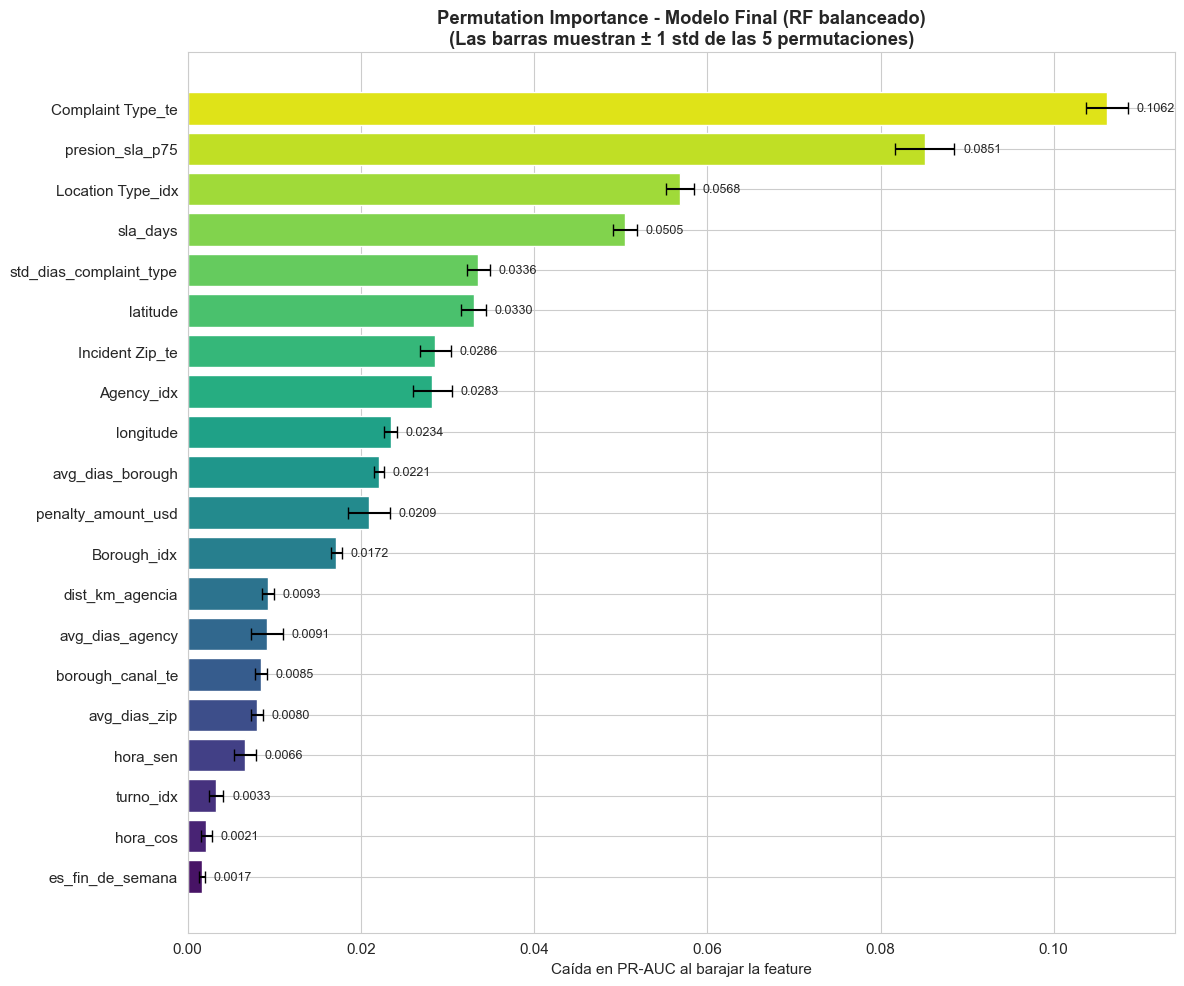


Comparativa: Permutation Importance vs Gini Importance

🔄 Features con mayor CAMBIO de ranking (top 10):

                feature  rank_gini  rank_perm  cambio_rank  gini_importance  importance_mean
p75_dias_complaint_type          6         28          -22         0.048270        -0.003968
      saturacion_diaria          5         26          -21         0.054749        -0.001418
      Location Type_idx         20          3           17         0.013444         0.056822
         saturacion_zip         10         27          -17         0.031092        -0.001540
       avg_dias_borough         22         10           12         0.012108         0.022101
       densidad_zip_30d         13         24          -11         0.023633        -0.000168
            Borough_idx         21         12            9         0.012386         0.017171
              turno_idx         26         18            8         0.004594         0.003312
       es_fin_de_semana         27         20           

In [27]:
#Permutation Importance

from sklearn.inspection import permutation_importance

print("=" * 70)
print("PERMUTATION IMPORTANCE EN VAL")
print("=" * 70)
print(f"\nModelo: RF + class_weight (modelo final)")
print(f"Calculando importancia con 5 permutaciones por feature...")
print(f"(Esto puede tardar 3-5 minutos)\n")

t0 = time.time()
perm_imp = permutation_importance(
    MODELO_FINAL,
    X_val_v2, y_val,
    scoring='average_precision',  # PR-AUC, nuestra métrica principal
    n_repeats=5,
    random_state=SEED,
    n_jobs=-1,
)
print(f"⏱️  Tiempo: {(time.time()-t0)/60:.1f} min")

# Construir DataFrame con resultados
df_perm = pd.DataFrame({
    'feature': FEATURES_V2,
    'importance_mean': perm_imp.importances_mean,
    'importance_std':  perm_imp.importances_std,
}).sort_values('importance_mean', ascending=False)

# Mostrar top 20
print("\n" + "=" * 70)
print("TOP 20 FEATURES POR PERMUTATION IMPORTANCE")
print("=" * 70)
print(f"\n(Importance = caída en PR-AUC al barajar la feature)\n")
print(df_perm.head(20).to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(12, 10))
top20 = df_perm.head(20).iloc[::-1]
colors = sns.color_palette("viridis", len(top20))
ax.barh(top20['feature'], top20['importance_mean'],
        xerr=top20['importance_std'], color=colors, capsize=4)
ax.set_xlabel('Caída en PR-AUC al barajar la feature')
ax.set_title('Permutation Importance - Modelo Final (RF balanceado)\n'
             '(Las barras muestran ± 1 std de las 5 permutaciones)',
             fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)
for i, (mean, std) in enumerate(zip(top20['importance_mean'], top20['importance_std'])):
    ax.text(mean + std + 0.001, i, f'{mean:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Comparativa con Gini importance del mismo modelo
print("\n" + "=" * 70)
print("Comparativa: Permutation Importance vs Gini Importance")
print("=" * 70)

df_gini = pd.DataFrame({
    'feature': FEATURES_V2,
    'gini_importance': MODELO_FINAL.feature_importances_,
}).sort_values('gini_importance', ascending=False)

# Combinar
df_compare = df_perm.merge(df_gini, on='feature')
df_compare['rank_perm'] = df_compare['importance_mean'].rank(ascending=False).astype(int)
df_compare['rank_gini'] = df_compare['gini_importance'].rank(ascending=False).astype(int)
df_compare['cambio_rank'] = df_compare['rank_gini'] - df_compare['rank_perm']

# Features con mayor cambio (positivo = más importante en perm, negativo = menos)
print("\n🔄 Features con mayor CAMBIO de ranking (top 10):\n")
top_cambios = df_compare.sort_values('cambio_rank', key=abs, ascending=False).head(10)
print(top_cambios[['feature', 'rank_gini', 'rank_perm', 'cambio_rank',
                    'gini_importance', 'importance_mean']].to_string(index=False))

# Features con importance < 0 (en realidad ayudan al modelo si se barajean = ruido)
features_inutiles = df_perm[df_perm['importance_mean'] <= 0]
if len(features_inutiles) > 0:
    print(f"\n⚠️  Features que NO aportan (importance ≤ 0) — candidatas a eliminar:")
    print(features_inutiles.to_string(index=False))
else:
    print(f"\n✅ TODAS las features aportan algo positivo al modelo.")

print("\n" + "=" * 70)
print("CONCLUSIONES")
print("=" * 70)
print(f"""
TOP 5 FEATURES MÁS PREDICTIVAS (Permutation):
   {df_perm.head(5)[['feature','importance_mean']].to_string(index=False)}
""")

ANÁLISIS SHAP CON SAMPLEO PEQUEÑO

Estrategia:
  - Sampleo de 500 muestras de val (vs 2000 en el P1)
  - Modelo: XGBoost + scale_pos_weight (xgb_v2)
    -> 20x más rápido que RF para SHAP
    -> Métricas similares al modelo final, así que sus insights son válidos


🔄 Sampleando 500 muestras de val...
Creando TreeExplainer sobre XGBoost+spw (más rápido que RF)...
   ⏱️  0.68s

Calculando SHAP values sobre 500 muestras...
 Tiempo: 0.05 min

SHAP values calculados:
   Shape: (500, 28)
   Expected value (base): 0.0853

GRÁFICO 1: IMPORTANCIA GLOBAL DE FEATURES (mean |SHAP|)


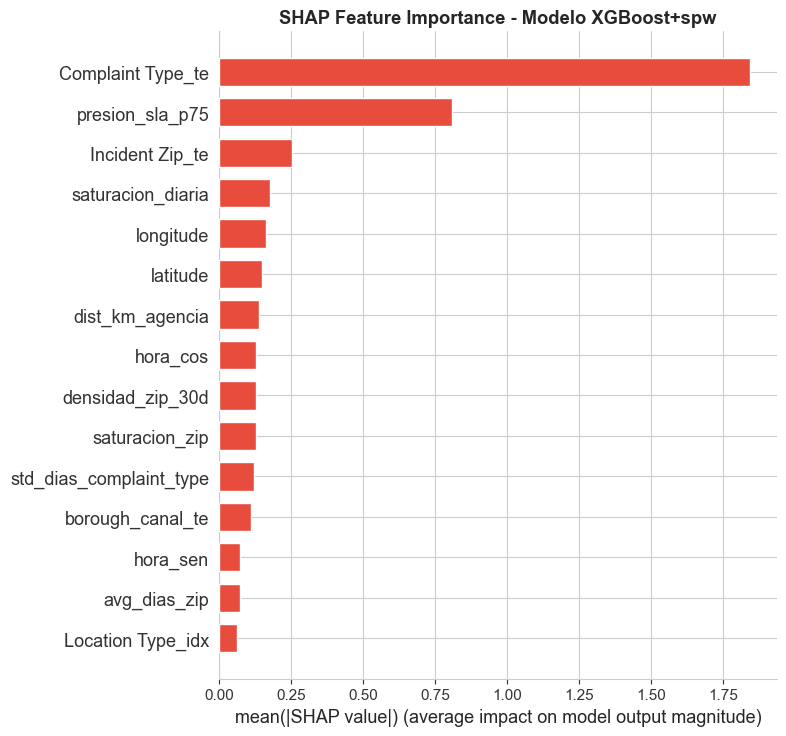


Top 10 features SHAP:
          feature  mean_abs_shap
Complaint Type_te       1.843749
  presion_sla_p75       0.809066
  Incident Zip_te       0.252110
saturacion_diaria       0.175945
        longitude       0.164022
         latitude       0.151270
  dist_km_agencia       0.139588
         hora_cos       0.130264
 densidad_zip_30d       0.129838
   saturacion_zip       0.128523

GRÁFICO 2: BEESWARM PLOT

Cómo leerlo:
  • Cada punto = una queja
  • Eje X = SHAP value (>0 empuja a INCUMPLIR, <0 empuja a CUMPLIR)
  • Color rojo = valor alto de la feature | Color azul = valor bajo



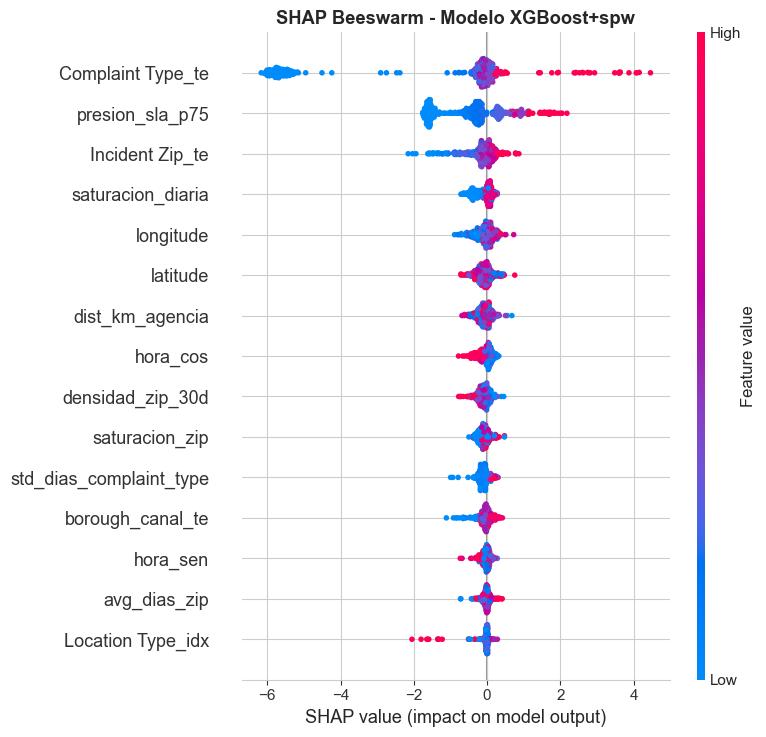


GRÁFICO 3: EXPLICACIÓN LOCAL DE UNA QUEJA

Queja predicha como INCUMPLIMIENTO con alta confianza:
  Probabilidad: 0.9987
  Realidad: INCUMPLIÓ ✓


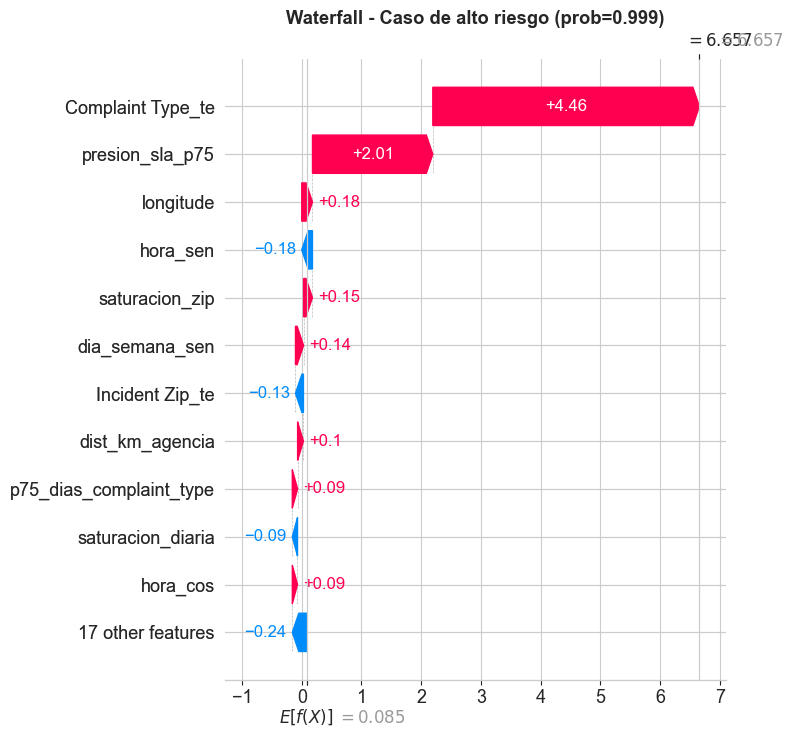


INSIGHTS PARA LA CONTRALORÍA

Las 5 features que MÁS empujan las predicciones (SHAP global):

          feature  mean_abs_shap
Complaint Type_te       1.843749
  presion_sla_p75       0.809066
  Incident Zip_te       0.252110
saturacion_diaria       0.175945
        longitude       0.164022



In [28]:
#Análisis SHAP (sampleo pequeño)

print("=" * 70)
print("ANÁLISIS SHAP CON SAMPLEO PEQUEÑO")
print("=" * 70)

print("""
Estrategia:
  - Sampleo de 500 muestras de val (vs 2000 en el P1)
  - Modelo: XGBoost + scale_pos_weight (xgb_v2)
    -> 20x más rápido que RF para SHAP
    -> Métricas similares al modelo final, así que sus insights son válidos
""")

# Sampleo pequeño
N_SAMPLES_SHAP = 500
print(f"\n🔄 Sampleando {N_SAMPLES_SHAP} muestras de val...")
np.random.seed(SEED)
idx_sample = np.random.choice(len(X_val_v2), size=N_SAMPLES_SHAP, replace=False)
X_shap = X_val_v2.iloc[idx_sample].copy().reset_index(drop=True)
y_shap = y_val.iloc[idx_sample].reset_index(drop=True)

# Usar xgb_v2 (XGBoost + scale_pos_weight) por velocidad
print("Creando TreeExplainer sobre XGBoost+spw (más rápido que RF)...")
t0 = time.time()
explainer = shap.TreeExplainer(xgb_v2)
print(f"   ⏱️  {time.time()-t0:.2f}s")

# Calcular SHAP values
print(f"\nCalculando SHAP values sobre {N_SAMPLES_SHAP} muestras...")
t0 = time.time()
shap_values = explainer.shap_values(X_shap)
print(f" Tiempo: {(time.time()-t0)/60:.2f} min")

# Para XGBoost binary, shap_values es directamente un array 2D (no necesita indexar clase)
expected_value = explainer.expected_value
if hasattr(expected_value, '__len__') and len(expected_value) > 1:
    expected_value = expected_value[1]
    shap_values = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

print(f"\nSHAP values calculados:")
print(f"   Shape: {shap_values.shape}")
print(f"   Expected value (base): {float(expected_value):.4f}")

# --- Gráfico 1: Importancia global (bar plot) ---
print("\n" + "=" * 70)
print("GRÁFICO 1: IMPORTANCIA GLOBAL DE FEATURES (mean |SHAP|)")
print("=" * 70)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False,
                  max_display=15, color='#e74c3c')
plt.title('SHAP Feature Importance - Modelo XGBoost+spw',
          fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla numérica
mean_abs_shap = np.abs(shap_values).mean(axis=0)
df_importance = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print("\nTop 10 features SHAP:")
print(df_importance.head(10).to_string(index=False))

# --- Gráfico 2: Beeswarm ---
print("\n" + "=" * 70)
print("GRÁFICO 2: BEESWARM PLOT")
print("=" * 70)
print("""
Cómo leerlo:
  • Cada punto = una queja
  • Eje X = SHAP value (>0 empuja a INCUMPLIR, <0 empuja a CUMPLIR)
  • Color rojo = valor alto de la feature | Color azul = valor bajo
""")

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, show=False, max_display=15)
plt.title('SHAP Beeswarm - Modelo XGBoost+spw', fontweight='bold')
plt.tight_layout()
plt.show()

# --- Gráfico 3: Caso local (queja específica con alto riesgo) ---
print("\n" + "=" * 70)
print("GRÁFICO 3: EXPLICACIÓN LOCAL DE UNA QUEJA")
print("=" * 70)

# Obtener probabilidades para la muestra
y_proba_shap = xgb_v2.predict_proba(X_shap)[:, 1]

# Caso con mayor probabilidad de incumplir
idx_top = np.argmax(y_proba_shap)
print(f"\nQueja predicha como INCUMPLIMIENTO con alta confianza:")
print(f"  Probabilidad: {y_proba_shap[idx_top]:.4f}")
print(f"  Realidad: {'INCUMPLIÓ ✓' if y_shap.iloc[idx_top]==1 else 'CUMPLIÓ ✗'}")

# Waterfall plot
plt.figure(figsize=(12, 8))
shap.plots._waterfall.waterfall_legacy(
    float(expected_value),
    shap_values[idx_top],
    feature_names=X_shap.columns.tolist(),
    max_display=12,
    show=False,
)
plt.title(f'Waterfall - Caso de alto riesgo (prob={y_proba_shap[idx_top]:.3f})',
          fontweight='bold')
plt.tight_layout()
plt.show()

# --- Conclusión ---
print("\n" + "=" * 90)
print("INSIGHTS PARA LA CONTRALORÍA")
print("=" * 90)
top5 = df_importance.head(5)
print(f"""
Las 5 features que MÁS empujan las predicciones (SHAP global):

{top5.to_string(index=False)}
""")

EVALUACIÓN FINAL EN TEST SET

Modelo final:    RF + class_weight (sin calibrar, sin tuning)
Threshold:       0.50
Test size:       20,875 quejas (nunca vistas, las más recientes)
Período test:    el 15% más reciente del dataset

COMPARACIÓN VAL vs TEST

            Validación    Test  Diferencia
PR-AUC         0.5849  0.4824     -0.1024
ROC-AUC        0.8677  0.8050     -0.0627
F1             0.5122  0.4470     -0.0652
Recall         0.7537  0.6932     -0.0606
Precision      0.3879  0.3298     -0.0581
Accuracy       0.7819  0.7263     -0.0556

Diagnóstico de generalización:
   ATENCIÓN: max diferencia = 0.1024 (>0.10). Modelo no generaliza bien.


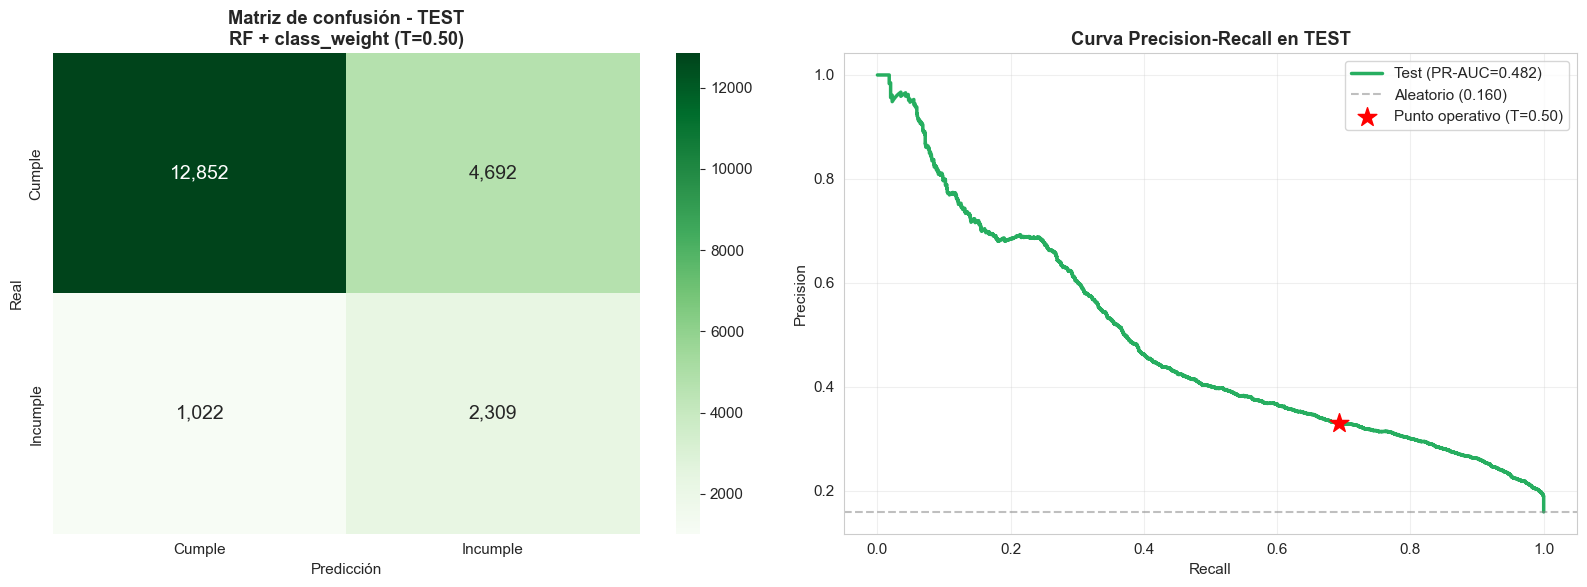


IMPACTO FISCAL FINAL EN TEST

  Matriz de confusión:
    Verdaderos Positivos (detectados):       2,309
    Verdaderos Negativos (correctos):        12,852
    Falsos Positivos (alertas innecesarias): 4,692
    Falsos Negativos (perdidos):             1,022

  Exposición fiscal en test:
    Pérdida MÁXIMA (sin modelo):       $224,835,207
    Pérdida CON el modelo:             $68,982,762
      AHORRO:                          $155,852,445
      % de exposición evitada:        69.3%

  Interpretación de negocio:
    De cada 100 incumplimientos reales, el modelo detecta 69.
    De cada 100 alertas, 33 son incumplimientos reales.

Resultados guardados en variable: RESULTADOS_FINALES


In [29]:
# Evaluación final en TEST

print("=" * 70)
print("EVALUACIÓN FINAL EN TEST SET")
print("=" * 70)
print(f"""
Modelo final:    RF + class_weight (sin calibrar, sin tuning)
Threshold:       {MEJOR_THRESHOLD:.2f}
Test size:       {len(X_test_v2):,} quejas (nunca vistas, las más recientes)
Período test:    el 15% más reciente del dataset
""")

# Predicciones en test
y_proba_test = MODELO_FINAL.predict_proba(X_test_v2)[:, 1]
y_pred_test = (y_proba_test >= MEJOR_THRESHOLD).astype(int)

# Métricas en test
metricas_test = {
    'PR-AUC':    average_precision_score(y_test, y_proba_test),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_test),
    'F1':        f1_score(y_test, y_pred_test),
    'Recall':    recall_score(y_test, y_pred_test),
    'Precision': precision_score(y_test, y_pred_test),
    'Accuracy':  accuracy_score(y_test, y_pred_test),
}

# Métricas equivalentes en val (para comparar)
y_proba_val_final = MODELO_FINAL.predict_proba(X_val_v2)[:, 1]
y_pred_val_final = (y_proba_val_final >= MEJOR_THRESHOLD).astype(int)
metricas_val = {
    'PR-AUC':    average_precision_score(y_val, y_proba_val_final),
    'ROC-AUC':   roc_auc_score(y_val, y_proba_val_final),
    'F1':        f1_score(y_val, y_pred_val_final),
    'Recall':    recall_score(y_val, y_pred_val_final),
    'Precision': precision_score(y_val, y_pred_val_final),
    'Accuracy':  accuracy_score(y_val, y_pred_val_final),
}

# Tabla comparativa
print("=" * 70)
print("COMPARACIÓN VAL vs TEST")
print("=" * 70)
df_vt = pd.DataFrame({'Validación': metricas_val, 'Test': metricas_test})
df_vt['Diferencia'] = df_vt['Test'] - df_vt['Validación']
print("\n", df_vt.round(4).to_string())

# Diagnóstico
max_diff = df_vt['Diferencia'].abs().max()
print(f"\nDiagnóstico de generalización:")
if max_diff < 0.02:
    print(f"   EXCELENTE: max diferencia = {max_diff:.4f} (<0.02). Modelo robusto.")
elif max_diff < 0.05:
    print(f"   BUENA: max diferencia = {max_diff:.4f} (<0.05). Aceptable.")
elif max_diff < 0.10:
    print(f"   MODERADA: max diferencia = {max_diff:.4f} (<0.10). Hay drift residual.")
else:
    print(f"   ATENCIÓN: max diferencia = {max_diff:.4f} (>0.10). Modelo no generaliza bien.")

# --- Matriz de confusión + curva PR en test ---
cm_test = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm_test.ravel()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_test, annot=True, fmt=',d', cmap='Greens',
            xticklabels=['Cumple', 'Incumple'], yticklabels=['Cumple', 'Incumple'],
            annot_kws={'fontsize': 14}, ax=axes[0])
axes[0].set_title(f'Matriz de confusión - TEST\nRF + class_weight (T={MEJOR_THRESHOLD:.2f})',
                  fontweight='bold')
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predicción')

prec_test, rec_test, _ = precision_recall_curve(y_test, y_proba_test)
axes[1].plot(rec_test, prec_test, color='#27ae60', linewidth=2.5,
              label=f'Test (PR-AUC={metricas_test["PR-AUC"]:.3f})')
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.5,
                label=f'Aleatorio ({y_test.mean():.3f})')
axes[1].scatter([metricas_test['Recall']], [metricas_test['Precision']],
                color='red', s=200, zorder=5, marker='*',
                label=f'Punto operativo (T={MEJOR_THRESHOLD:.2f})')
axes[1].set_title('Curva Precision-Recall en TEST', fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Impacto fiscal en TEST ---
multa_promedio_test = df_test.loc[df_test['target']==1, 'penalty_charged'].mean()
multa_total_test = df_test.loc[df_test['target']==1, 'penalty_charged'].sum()
perdida_test = fn * multa_promedio_test
ahorro_test = multa_total_test - perdida_test

print("\n" + "=" * 70)
print("IMPACTO FISCAL FINAL EN TEST")
print("=" * 70)
print(f"""
  Matriz de confusión:
    Verdaderos Positivos (detectados):       {tp:,}
    Verdaderos Negativos (correctos):        {tn:,}
    Falsos Positivos (alertas innecesarias): {fp:,}
    Falsos Negativos (perdidos):             {fn:,}

  Exposición fiscal en test:
    Pérdida MÁXIMA (sin modelo):       ${multa_total_test:,.0f}
    Pérdida CON el modelo:             ${perdida_test:,.0f}
      AHORRO:                          ${ahorro_test:,.0f}
      % de exposición evitada:        {100 * ahorro_test/multa_total_test:.1f}%

  Interpretación de negocio:
    De cada 100 incumplimientos reales, el modelo detecta {100*metricas_test['Recall']:.0f}.
    De cada 100 alertas, {100*metricas_test['Precision']:.0f} son incumplimientos reales.
""")

# Resultados finales para reportar
RESULTADOS_FINALES = {
    'modelo': 'RF + class_weight (sin tuning, sin calibrar)',
    'threshold': MEJOR_THRESHOLD,
    'features_count': len(FEATURES_V2),
    'metricas_test': metricas_test,
    'matriz_confusion_test': cm_test.tolist(),
    'ahorro_fiscal_test': float(ahorro_test),
    'pct_exposicion_evitada_test': float(100 * ahorro_test / multa_total_test),
}
print("Resultados guardados en variable: RESULTADOS_FINALES")

In [30]:
#CELDA 28: Función de inferencia + persistencia

import joblib
from pathlib import Path
import math

# --- Crear carpeta para artefactos del modelo ---
ARTIFACTS_DIR = Path('modelo_ny311_p2_artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

print("=" * 70)
print("GUARDANDO ARTEFACTOS DEL MODELO FINAL (P2)")
print("=" * 70)

# Guardar el modelo
ruta_modelo = ARTIFACTS_DIR / 'modelo_final_rf_p2.joblib'
joblib.dump(MODELO_FINAL, ruta_modelo)
print(f"\nModelo guardado: {ruta_modelo}")
print(f"   Tamaño: {ruta_modelo.stat().st_size / 1024 / 1024:.1f} MB")

# Guardar la metadata operativa (threshold, features, métricas)
metadata_operativa = {
    'modelo_nombre': 'RF + class_weight (sin tuning)',
    'threshold': float(MEJOR_THRESHOLD),
    'features': FEATURES_V2,
    'metricas_test': {k: float(v) for k, v in RESULTADOS_FINALES['metricas_test'].items()},
    'ahorro_fiscal_test': RESULTADOS_FINALES['ahorro_fiscal_test'],
    'pct_exposicion_evitada': RESULTADOS_FINALES['pct_exposicion_evitada_test'],
}

ruta_meta = ARTIFACTS_DIR / 'metadata_operativa.json'
with open(ruta_meta, 'w', encoding='utf-8') as f:
    json.dump(metadata_operativa, f, indent=2, ensure_ascii=False)
print(f"Metadata operativa: {ruta_meta}")

# Los ARTIFACTS de inferencia (los mapeos) ya están en S3 desde Spark
print(f"\nLos artifacts de inferencia (mapeos exactos) están en S3:")
print(f"   s3://{BUCKET}/{ARTIFACTS_KEY}")
print(f"   Ya cargados en la variable ARTIFACTS (13 secciones).")

# ============================================================
# FUNCIÓN DE INFERENCIA
# ============================================================

def predecir_incumplimiento(
    agency,
    complaint_type,
    borough,
    incident_zip,
    open_data_channel_type,
    location_type,
    created_datetime,
    latitude,
    longitude,
    modelo=MODELO_FINAL,
    artifacts=ARTIFACTS,
    threshold=MEJOR_THRESHOLD,
    verbose=True,
):
    """
    Predice si una queja 311 va a incumplir su SLA.
    
    Usa los artifacts EXACTOS del job de Spark (no aproximaciones).
    Esto es la mejora clave vs la función del P1.
    """
    
    # Normalizar entradas (igual que el pipeline de Spark)
    agency = str(agency).strip().upper()
    complaint_type = str(complaint_type).strip().upper()
    borough = str(borough).strip().upper()
    open_data_channel_type = str(open_data_channel_type).strip().upper()
    location_type = str(location_type).strip().upper()
    incident_zip_str = str(incident_zip)
    
    # Parsear fecha
    ts = pd.to_datetime(created_datetime) if isinstance(created_datetime, str) else pd.Timestamp(created_datetime)
    hora = ts.hour
    dia_semana_spark = (ts.dayofweek + 1) % 7 + 1  # 1=domingo .. 7=sábado
    mes = ts.month
    
    # --- 1. NEGOCIO: SLA y multa ---
    bm = artifacts['business_mapping']
    if agency in bm:
        sla_days, penalty_amount_usd = bm[agency]
    else:
        sla_days, penalty_amount_usd = 10.0, 15000.0
    
    # --- 2. TEMPORALES (cíclicas) ---
    hora_sen = math.sin(2*math.pi*hora/24)
    hora_cos = math.cos(2*math.pi*hora/24)
    dia_semana_sen = math.sin(2*math.pi*dia_semana_spark/7)
    # dia_semana_cos NO se usa (eliminada en Celda 19.5)
    es_fin_de_semana = 1 if dia_semana_spark in [1, 7] else 0
    trimestre = math.ceil(mes/3)
    
    # Turno
    if 6 <= hora < 12:
        turno = 'manana'
    elif 12 <= hora < 20:
        turno = 'tarde'
    else:
        turno = 'noche'
    
    # --- 3. TARGET ENCODINGS (con fallback) ---
    g = artifacts['global_tasa']
    complaint_type_te = artifacts['te_maps_full']['Complaint Type_te'].get(complaint_type, g)
    incident_zip_te = artifacts['te_maps_full']['Incident Zip_te'].get(incident_zip_str, g)
    borough_canal_key = f"{borough}_{open_data_channel_type}"
    borough_canal_te = artifacts['te_maps_full']['borough_canal_te'].get(borough_canal_key, g)
    
    # --- 4. ESTADÍSTICAS HISTÓRICAS ---
    stats = artifacts['stats']
    p75_dias_complaint_type = stats['p75_dias_complaint_type'].get(complaint_type, artifacts['global_p75'])
    std_dias_complaint_type = stats['std_dias_complaint_type'].get(complaint_type, artifacts['global_std'])
    avg_dias_agency = stats['avg_dias_agency'].get(agency, artifacts['global_avg'])
    avg_dias_borough = stats['avg_dias_borough'].get(borough, artifacts['global_avg'])
    avg_dias_zip = stats['avg_dias_zip'].get(incident_zip_str, artifacts['global_avg'])
    
    # --- 5. GEOESPACIALES (aproximadas con histórico del ZIP) ---
    densidad_zip_30d = artifacts['densidad_zip'].get(incident_zip_str, artifacts['global_densidad'])
    dist_km_key = f"{agency}_{borough}"
    dist_km_agencia = artifacts['dist_km_agencia'].get(dist_km_key, 5.0)
    quejas_por_dia = artifacts['mediana_quejas_por_dia']
    
    # --- 6. FEATURES DE PRESIÓN / SATURACIÓN (NUEVAS del P2) ---
    presion_sla_p75 = p75_dias_complaint_type / (sla_days + 0.01)
    saturacion_zip = densidad_zip_30d / (sla_days + 0.01)
    saturacion_diaria = quejas_por_dia / (sla_days + 0.01)
    
    # --- 7. ÍNDICES CATEGÓRICOS (mapeos EXACTOS del StringIndexer) ---
    im = artifacts['idx_mappings']
    agency_idx = im['Agency_idx'].get(agency, len(im['Agency_idx']))
    borough_idx = im['Borough_idx'].get(borough, len(im['Borough_idx']))
    canal_idx = im['Open Data Channel Type_idx'].get(open_data_channel_type, len(im['Open Data Channel Type_idx']))
    location_idx = im['Location Type_idx'].get(location_type, len(im['Location Type_idx']))
    turno_idx = im['turno_idx'].get(turno, len(im['turno_idx']))
    
    # --- 8. CONSTRUIR VECTOR DE FEATURES ---
    feature_values = {
        'latitude': latitude, 'longitude': longitude,
        'sla_days': sla_days, 'penalty_amount_usd': penalty_amount_usd,
        'hora_sen': hora_sen, 'hora_cos': hora_cos,
        'dia_semana_sen': dia_semana_sen,
        'es_fin_de_semana': es_fin_de_semana, 'trimestre': trimestre,
        'quejas_por_dia': quejas_por_dia,
        'std_dias_complaint_type': std_dias_complaint_type,
        'p75_dias_complaint_type': p75_dias_complaint_type,
        'avg_dias_agency': avg_dias_agency,
        'avg_dias_borough': avg_dias_borough,
        'avg_dias_zip': avg_dias_zip,
        'presion_sla_p75': presion_sla_p75,
        'saturacion_zip': saturacion_zip,
        'saturacion_diaria': saturacion_diaria,
        'dist_km_agencia': dist_km_agencia,
        'densidad_zip_30d': densidad_zip_30d,
        'Agency_idx': agency_idx,
        'Borough_idx': borough_idx,
        'Open Data Channel Type_idx': canal_idx,
        'Location Type_idx': location_idx,
        'turno_idx': turno_idx,
        'Complaint Type_te': complaint_type_te,
        'Incident Zip_te': incident_zip_te,
        'borough_canal_te': borough_canal_te,
    }
    
    # Ordenar según FEATURES_V2
    X_nuevo = pd.DataFrame([[feature_values.get(f, 0) for f in FEATURES_V2]],
                            columns=FEATURES_V2)
    
    # --- 9. PREDICCIÓN ---
    prob_incumplir = float(modelo.predict_proba(X_nuevo)[:, 1][0])
    # Cap probabilidades extremas (limitación documentada del RF sin calibrar)
    prob_capped = max(0.05, min(0.95, prob_incumplir))
    
    prediccion = int(prob_incumplir >= threshold)
    riesgo_fiscal_esperado = prob_capped * penalty_amount_usd
    
    # Nivel de prioridad
    if prob_incumplir >= 0.75:
        prioridad = "CRÍTICA"
    elif prob_incumplir >= threshold:
        prioridad = "ALTA"
    elif prob_incumplir >= 0.30:
        prioridad = "MEDIA"
    else:
        prioridad = "BAJA"
    
    resultado = {
        'prediccion': prediccion,
        'prediccion_texto': 'INCUMPLIRÁ EL SLA' if prediccion == 1 else 'CUMPLIRÁ EL SLA',
        'probabilidad_incumplir': round(prob_incumplir, 4),
        'probabilidad_capped': round(prob_capped, 4),
        'threshold_usado': threshold,
        'prioridad': prioridad,
        'sla_oficial_dias': sla_days,
        'multa_potencial_usd': penalty_amount_usd,
        'riesgo_fiscal_esperado_usd': round(riesgo_fiscal_esperado, 2),
    }
    
    if verbose:
        print("=" * 60)
        print("PREDICCIÓN DE INCUMPLIMIENTO DE SLA")
        print("=" * 60)
        print(f"""
  Queja:
    Agencia:     {agency}
    Tipo:        {complaint_type}
    Borough:     {borough}
    ZIP:         {incident_zip}
    Canal:       {open_data_channel_type}
    Fecha/hora:  {ts} (turno: {turno})
  
  Resultado:
    {'Alerta' if prediccion==1 else 'Listo'} {resultado['prediccion_texto']}
    Probabilidad: {prob_incumplir*100:.1f}%
    Threshold:    {threshold*100:.0f}%
    Prioridad:    {prioridad}
  
  Contexto de negocio:
    SLA oficial:           {sla_days} días
    Multa potencial:       ${penalty_amount_usd:,.0f}
    Riesgo fiscal esperado: ${riesgo_fiscal_esperado:,.0f}
""")
    
    return resultado


# ============================================================
# PRUEBAS DE LA FUNCIÓN
# ============================================================

print("\n" + "=" * 70)
print("PRUEBAS DE LA FUNCIÓN DE INFERENCIA")
print("=" * 70)

print("\nPRUEBA 1: DHS + Homeless en Manhattan (combo más riesgosa)\n")
r1 = predecir_incumplimiento(
    agency='DHS', complaint_type='HOMELESS PERSON ASSISTANCE',
    borough='MANHATTAN', incident_zip=10001,
    open_data_channel_type='PHONE', location_type='STREET/SIDEWALK',
    created_datetime='2024-12-15 23:30:00',
    latitude=40.7506, longitude=-73.9971,
)

print("\nPRUEBA 2: NYPD + Ruido en Queens (caso típico)\n")
r2 = predecir_incumplimiento(
    agency='NYPD', complaint_type='NOISE - RESIDENTIAL',
    borough='QUEENS', incident_zip=11375,
    open_data_channel_type='MOBILE', location_type='RESIDENTIAL BUILDING',
    created_datetime='2024-10-08 14:00:00',
    latitude=40.7210, longitude=-73.8458,
)

print("\nPRUEBA 3: HPD + Calefacción en Bronx\n")
r3 = predecir_incumplimiento(
    agency='HPD', complaint_type='HEAT/HOT WATER',
    borough='BRONX', incident_zip=10462,
    open_data_channel_type='ONLINE', location_type='RESIDENTIAL BUILDING',
    created_datetime='2024-11-20 08:15:00',
    latitude=40.8470, longitude=-73.8629,
)

# Resumen
print("\n" + "=" * 70)
print("RESUMEN DE LAS 3 PRUEBAS")
print("=" * 70)
df_pruebas = pd.DataFrame([
    {'Caso': 'DHS/Homeless/Manhattan', **r1},
    {'Caso': 'NYPD/Noise/Queens',      **r2},
    {'Caso': 'HPD/Heat/Bronx',         **r3},
])[['Caso', 'prediccion_texto', 'probabilidad_incumplir', 'prioridad',
    'multa_potencial_usd', 'riesgo_fiscal_esperado_usd']]
print("\n", df_pruebas.to_string(index=False))

print(f"""
============================================================================
PROYECTO #2 COMPLETADO

Modelo final: RF + class_weight (sin tuning, sin calibrar)
Threshold:    {MEJOR_THRESHOLD:.2f}
Features:     {len(FEATURES_V2)}

Métricas en test:
  PR-AUC:    {RESULTADOS_FINALES['metricas_test']['PR-AUC']:.4f}
  ROC-AUC:   {RESULTADOS_FINALES['metricas_test']['ROC-AUC']:.4f}
  F1:        {RESULTADOS_FINALES['metricas_test']['F1']:.4f}
  Recall:    {RESULTADOS_FINALES['metricas_test']['Recall']:.4f}
  Precision: {RESULTADOS_FINALES['metricas_test']['Precision']:.4f}

Ahorro fiscal en test: ${RESULTADOS_FINALES['ahorro_fiscal_test']:,.0f}
% exposición evitada:  {RESULTADOS_FINALES['pct_exposicion_evitada_test']:.1f}%
============================================================================
""")

GUARDANDO ARTEFACTOS DEL MODELO FINAL (P2)

Modelo guardado: modelo_ny311_p2_artifacts\modelo_final_rf_p2.joblib
   Tamaño: 57.6 MB
Metadata operativa: modelo_ny311_p2_artifacts\metadata_operativa.json

Los artifacts de inferencia (mapeos exactos) están en S3:
   s3://proyect-ny311/gold_v2/artifacts/inference_artifacts.json
   Ya cargados en la variable ARTIFACTS (13 secciones).

PRUEBAS DE LA FUNCIÓN DE INFERENCIA

PRUEBA 1: DHS + Homeless en Manhattan (combo más riesgosa)

PREDICCIÓN DE INCUMPLIMIENTO DE SLA

  Queja:
    Agencia:     DHS
    Tipo:        HOMELESS PERSON ASSISTANCE
    Borough:     MANHATTAN
    ZIP:         10001
    Canal:       PHONE
    Fecha/hora:  2024-12-15 23:30:00 (turno: noche)

  Resultado:
    Alerta INCUMPLIRÁ EL SLA
    Probabilidad: 96.8%
    Threshold:    50%
    Prioridad:    CRÍTICA

  Contexto de negocio:
    SLA oficial:           0.04 días
    Multa potencial:       $74,717
    Riesgo fiscal esperado: $70,981


PRUEBA 2: NYPD + Ruido en Queens (c